# Paper Figures — Decoding Subpopulation Analysis

Generates publication-quality figures for the NeurIPS 2026 submission.

**Figure 1** — Population-fraction sweep (Retina + V1), 8 metrics (M1–M4 static, T1–T4 trajectory).  
**Figure 2** — Retina: four encoding-manifold regions × bar chart of 8 metrics.  
**Figure 3** — V1: same as Figure 2.

**Workflow:**
1. Run all cells top-to-bottom once to generate figures with placeholder subpopulations.
2. Update `RETINA_SUBPOPS` / `V1_SUBPOPS` in the config cell with neuron indices copied from the website explorer, then re-run Figures 2–3.

**Runtime:** Figure 1 sweep with trajectory metrics takes ~30 min per dataset on a laptop CPU.  
Set `COMPUTE_TRAJ_IN_SWEEP = False` to skip T1–T4 and run only M1–M4 (fast).  
DSA requires the `DSA` package (`pip install dsa-analysis`); if unavailable it returns NaN.

Paper color pallette:

For encoding manifold related figures:

#00218e (basic text color)
#bb2427
#ed7916 (use this to highlight subpops on encoding manifolds)
#ecc115
#93c04f
#37b2af
#1578d9
#7d3a9f
#888888 (use this for non-selected background neurons in encoding manifolds)

For decoding manifold related figures:

#691318 (basic text color)
#b02628
#f08226 (use this for M5-8)
#efc620
#3bbdb9 (use this for M1-4)
#1679d8
#9d4ea5

## 0 — Setup

In [1]:
import os, sys, warnings, time, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from tueplots import bundles
from sklearn.decomposition import PCA as _PCA

warnings.filterwarnings('ignore')

_here = os.path.abspath(os.getcwd())
sys.path.insert(0, _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.dirname(_here))

from src.subpop_utils import (
    compute_dynamic_metrics, select_top_k_by_metric,
    compute_decoding_manifold, compute_decoding_trajectories,
    knn_decoding_accuracy, procrustes_r2, rdm_correlation, linear_cka,
    time_resolved_rsa, speed_profile_correlation, trajectory_procrustes_r2,
    compute_dsa,
)
from src.metrics import compute_osi_and_pref_stim
from src.cache_utils import load_for_explorer

plt.rcParams.update(bundles.neurips2024())


BASEDIR      = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.dirname(_here)
BASEDIR_FIG  = os.path.join(BASEDIR, 'fig', 'paper')
BASEDIR_DATA = os.path.join(BASEDIR, 'data', 'sampled')
BASEDIR_CACHE = os.path.join(BASEDIR_FIG, 'cache')
os.makedirs(BASEDIR_FIG, exist_ok=True)
os.makedirs(BASEDIR_CACHE, exist_ok=True)

PREFIX_LABELS = {
    'V1':                                   'V1 (Flow stimuli)',
    'VISp_natural_movie_one_scenes_all156': 'V1 (Natural video)',
    'VISp_natural_movie_one_scenes20':      'V1 (Natural video)',
    'allen_VISp':                           'V1 (Gratings)',
}

PREFIX_LABELS_SHORT = {
    'V1':                                   'V1 (FS)',
    'VISp_natural_movie_one_scenes_all156': 'V1 (NV)',
    'VISp_natural_movie_one_scenes20':      'V1 (NV)',
    'allen_VISp':                           'V1 (G)',
}

def _prefix_label(prefix):
    return PREFIX_LABELS.get(prefix, prefix)

def _prefix_label_short(prefix):
    return PREFIX_LABELS_SHORT.get(prefix, prefix)

print(f'Figures -> {BASEDIR_FIG}')


Figures -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper


## 1 — Global Configuration

In [2]:
COMPUTE_TRAJ_IN_SWEEP = True
N_RANDOM_SEEDS = 10

FRACTIONS = np.array([0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40,
                      0.50, 0.60, 0.70, 0.80, 0.90, 1.00])

STRATEGIES = {
    'random':          {'type': 'random'},
    'curvature':       {'type': 'metric', 'metric': 'curvature',       'high': True},
    'curvature [lo]':  {'type': 'metric', 'metric': 'curvature',       'high': False},
    'stability':       {'type': 'metric', 'metric': 'stability',       'high': True},
    'stability [lo]':  {'type': 'metric', 'metric': 'stability',       'high': False},
    'classif.':        {'type': 'metric', 'metric': 'classifiability', 'high': True},
    'classif. [lo]':   {'type': 'metric', 'metric': 'classifiability', 'high': False},
    'osi':             {'type': 'metric', 'metric': 'osi',             'high': True},
    'osi [lo]':        {'type': 'metric', 'metric': 'osi',             'high': False},
    'pc_contrib':      {'type': 'metric', 'metric': 'pc_contrib',      'high': True},
    'pc_contrib [lo]': {'type': 'metric', 'metric': 'pc_contrib',      'high': False},
}

STRAT_COLORS = {
    'random':          '#888888',
    'curvature':       '#ecc115',  'curvature [lo]':  '#f5df7a',
    'stability':       '#93c04f',  'stability [lo]':  '#c4dfa0',
    'classif.':        '#1578d9',  'classif. [lo]':   '#85b8ec',
    'osi':             '#bb2427',  'osi [lo]':        '#dd8a8b',
    'pc_contrib':      '#7d3a9f',  'pc_contrib [lo]': '#bd94ce',
}

# All 8 metrics (kept for full bar charts in Figs 2 & 3)
METRIC_PANELS = [
    ('acc',   'kNN acc.',       'static'),
    ('rdm',   'RSA',            'static'),
    ('cka',   'CKA',            'static'),
    ('r2',    u'Proc. R\u00b2', 'static'),
    ('trsa',  'tRSA',           'traj'),
    ('spc',   'Speed corr.',    'traj'),
    ('tproc', u'Traj. Proc. R\u00b2', 'traj'),
    ('dsa',   'DSA',            'traj'),
]
STATIC_KEYS = [m[0] for m in METRIC_PANELS if m[2] == 'static']
TRAJ_KEYS   = [m[0] for m in METRIC_PANELS if m[2] == 'traj']
ALL_KEYS    = STATIC_KEYS + TRAJ_KEYS

# Figure 1 main sweep: 6 metrics (2x3); kNN and DSA moved to Appendix Fig 5
MAIN_SWEEP_KEYS = ['rdm', 'cka', 'r2', 'trsa', 'spc', 'tproc']
APP_SWEEP_KEYS  = ['acc', 'dsa']

FS_TITLE  = 14
FS_TICK   = 12
FS_LABEL  = 12
FS_HDR    = 12

print('Configuration ready.')

Configuration ready.


## 2 — Shared Helper Functions

In [3]:
from src.tensor_utils import select_sf_stims_for_decoding

def _pad(coords_sub, coords_ref):
    """Zero-pad coords_sub columns to match coords_ref column count."""
    if coords_sub.shape[1] < coords_ref.shape[1]:
        pad = np.zeros((coords_sub.shape[0], coords_ref.shape[1] - coords_sub.shape[1]))
        return np.hstack([coords_sub, pad])
    return coords_sub


def load_dataset_for_sweep(PREFIX, **explorer_kwargs):
    """Load dataset via load_for_explorer (nonoutlier-filtered, same space as website).

    Returns tensor4d (N_nonout, S, D, T) — the format subpop_utils expects.
    For single-direction datasets (natural movie) SF selection and OSI are skipped.
    """
    data = load_for_explorer(PREFIX, **explorer_kwargs)

    # tensor4d_raw is (N_nonout, S, T, D); transpose to (N_nonout, S, D, T)
    tensor4d = data['tensor4d_raw'].transpose(0, 1, 3, 2)

    tensor4d = tensor4d - np.nanmin(tensor4d)

    N, NSTIMS, NDIRS, TRIAL_LEN = tensor4d.shape

    # SF stim selection only makes sense for multi-direction optical-flow data
    if NDIRS > 1:
        _, tensor4d = select_sf_stims_for_decoding(tensor4d)
        N, NSTIMS, NDIRS, TRIAL_LEN = tensor4d.shape

    # Replace any remaining NaNs with 0 for metric computation
    tensor4d = np.where(np.isfinite(tensor4d), tensor4d, 0.0)

    metrics = compute_dynamic_metrics(tensor4d, target_stim_idx=None)

    if NDIRS > 1:
        osi_vals, _ = compute_osi_and_pref_stim(
            tensor4d.reshape(N, NSTIMS, NDIRS * TRIAL_LEN), n_stim=NSTIMS, n_dir=NDIRS)
        metrics['osi'] = osi_vals
    else:
        metrics['osi'] = np.full(N, np.nan)

    print(f'  {PREFIX}: N_nonout={N}  NSTIMS={NSTIMS}  NDIRS={NDIRS}  T={TRIAL_LEN}')
    return tensor4d, metrics, NSTIMS, NDIRS, data


def compute_all_metrics(tensor4d_ref, tensor4d_sub, stim_labels,
                        coords_ref=None, include_traj=True, neuron_idx=None,
                        dsa_ref_z=None):
    """Compute all 8 paper metrics for a subpopulation.

    Parameters
    ----------
    dsa_ref_z : float or None
        Full-population DSA z-score used to normalise T4 to [0, 1].
        Pass None to return the raw z-score instead.
    """
    n_sub  = tensor4d_sub.shape[0]
    n_comp_traj = min(15, n_sub)

    if coords_ref is None:
        coords_ref, _ = compute_decoding_manifold(tensor4d_ref, n_components=15)
    coords_knn, _ = compute_decoding_manifold(tensor4d_sub, n_components=None)
    coords_sub, _ = compute_decoding_manifold(tensor4d_sub, n_components=n_comp_traj)

    _single_sample = len(np.unique(stim_labels)) == len(stim_labels)
    out = dict(
        acc  = np.nan if _single_sample else knn_decoding_accuracy(coords_knn, stim_labels),
        rdm  = rdm_correlation(tensor4d_ref, tensor4d_sub),
        cka  = linear_cka(tensor4d_ref, tensor4d_sub),
        r2   = procrustes_r2(coords_ref, _pad(coords_sub, coords_ref)),
    )

    if include_traj:
        trajs_ref, _ = compute_decoding_trajectories(tensor4d_ref, n_components=15)
        trajs_sub, _ = compute_decoding_trajectories(tensor4d_sub, n_components=n_comp_traj)
        if trajs_sub.shape[2] < trajs_ref.shape[2]:
            pad = np.zeros((*trajs_sub.shape[:2],
                            trajs_ref.shape[2] - trajs_sub.shape[2]))
            trajs_sub = np.concatenate([trajs_sub, pad], axis=2)
        _, trsa  = time_resolved_rsa(tensor4d_ref, tensor4d_sub)
        spc, _   = speed_profile_correlation(trajs_ref, trajs_sub)
        tproc, _ = trajectory_procrustes_r2(trajs_ref, trajs_sub)
        dsa      = compute_dsa(tensor4d_ref, tensor4d_sub,
                               neuron_idx=neuron_idx, ref_z=dsa_ref_z)
        out.update(trsa=trsa, spc=spc, tproc=tproc, dsa=dsa)
    else:
        out.update(trsa=np.nan, spc=np.nan, tproc=np.nan, dsa=np.nan)

    return out


print('Helper functions defined.')


Helper functions defined.


## 3 — Figure 1: Population-Fraction Sweep

In [4]:
def run_sweep_8metrics(tensor4d, metrics, NSTIMS, NDIRS, include_traj=True):
    """Fraction sweep for all 8 paper metrics (M1-M4 static + T1-T4 trajectory)."""
    N = tensor4d.shape[0]
    stim_labels = np.repeat(np.arange(NSTIMS), NDIRS)
    rng = np.random.default_rng(0)

    _single = np.array([1, 2, 3, 5, 8, 13, 20]) / N
    FRACTIONS_SWEEP = np.unique(np.concatenate([_single, FRACTIONS]))

    coords_ref, _ = compute_decoding_manifold(tensor4d, n_components=15)
    coords_ref_knn, _ = compute_decoding_manifold(tensor4d, n_components=None)
    acc_full = min(1.0, max(float(knn_decoding_accuracy(coords_ref_knn, stim_labels)), 1e-8))
    if include_traj:
        trajs_ref, _ = compute_decoding_trajectories(tensor4d, n_components=15)
        # Compute full-population DSA z-score once for normalisation
        print('  Computing full-population DSA reference z-score...')
        dsa_ref_z = compute_dsa(tensor4d, tensor4d)
        print(f'  DSA reference z: {dsa_ref_z:.3f}')
        if dsa_ref_z is None or np.isnan(dsa_ref_z) or dsa_ref_z < 1e-8:
            dsa_ref_z = None  # fall back to raw z-score
    else:
        dsa_ref_z = None

    results = {name: {k: [] for k in ALL_KEYS} for name in STRATEGIES}
    total = len(STRATEGIES) * len(FRACTIONS_SWEEP)
    done  = 0
    t0    = time.time()

    for name, cfg in STRATEGIES.items():
        for f in FRACTIONS_SWEEP:
            k      = max(1, int(round(f * N)))
            n_comp_traj = min(15, k)

            if cfg['type'] == 'random':
                vals = {key: [] for key in ALL_KEYS}
                for seed in range(N_RANDOM_SEEDS):
                    idx   = rng.choice(N, k, replace=False)
                    t_sub = tensor4d[idx]
                    cs_knn,  _ = compute_decoding_manifold(t_sub, n_components=None)
                    cs_proc, _ = compute_decoding_manifold(t_sub, n_components=n_comp_traj)
                    vals['acc'].append(min(1.0, knn_decoding_accuracy(cs_knn, stim_labels) / acc_full))
                    vals['rdm'].append(rdm_correlation(tensor4d, t_sub))
                    vals['cka'].append(linear_cka(tensor4d, t_sub))
                    _cs_pad = np.hstack([cs_proc, np.zeros((cs_proc.shape[0], coords_ref.shape[1]-cs_proc.shape[1]))]) if cs_proc.shape[1] < coords_ref.shape[1] else cs_proc
                    vals['r2'].append(procrustes_r2(coords_ref, _cs_pad))
                    if include_traj:
                        tr_s, _ = compute_decoding_trajectories(t_sub, n_components=n_comp_traj)
                        if tr_s.shape[2] < trajs_ref.shape[2]:
                            pad = np.zeros((*tr_s.shape[:2],
                                           trajs_ref.shape[2] - tr_s.shape[2]))
                            tr_s = np.concatenate([tr_s, pad], axis=2)
                        _, trsa = time_resolved_rsa(tensor4d, t_sub)
                        spc, _  = speed_profile_correlation(trajs_ref, tr_s)
                        tp, _   = trajectory_procrustes_r2(trajs_ref, tr_s)
                        dsa     = compute_dsa(tensor4d, t_sub,
                                              neuron_idx=idx, ref_z=dsa_ref_z)
                        vals['trsa'].append(trsa)
                        vals['spc'].append(spc)
                        vals['tproc'].append(tp)
                        vals['dsa'].append(dsa)
                    else:
                        for tk in TRAJ_KEYS:
                            vals[tk].append(np.nan)
                for key in ALL_KEYS:
                    results[name][key].append((np.nanmean(vals[key]),
                                               np.nanstd(vals[key])))
            else:
                idx = select_top_k_by_metric(metrics, cfg['metric'], k=k, high=cfg['high'])
                if len(idx) < 1:
                    for key in ALL_KEYS:
                        results[name][key].append((np.nan, 0.0))
                    done += 1; continue
                t_sub = tensor4d[idx]
                cs, _ = compute_decoding_manifold(t_sub, n_components=n_comp)
                results[name]['acc'].append((min(1.0, knn_decoding_accuracy(cs, stim_labels) / acc_full), 0.0))
                results[name]['rdm'].append((rdm_correlation(tensor4d, t_sub), 0.0))
                results[name]['cka'].append((linear_cka(tensor4d, t_sub), 0.0))
                _cs_pad2 = np.hstack([cs, np.zeros((cs.shape[0], coords_ref.shape[1]-cs.shape[1]))]) if cs.shape[1] < coords_ref.shape[1] else cs
                results[name]['r2'].append((procrustes_r2(coords_ref, _cs_pad2), 0.0))
                if include_traj:
                    tr_s, _ = compute_decoding_trajectories(t_sub, n_components=n_comp_traj)
                    if tr_s.shape[2] < trajs_ref.shape[2]:
                        pad = np.zeros((*tr_s.shape[:2],
                                       trajs_ref.shape[2] - tr_s.shape[2]))
                        tr_s = np.concatenate([tr_s, pad], axis=2)
                    _, trsa = time_resolved_rsa(tensor4d, t_sub)
                    spc, _  = speed_profile_correlation(trajs_ref, tr_s)
                    tp, _   = trajectory_procrustes_r2(trajs_ref, tr_s)
                    dsa     = compute_dsa(tensor4d, t_sub,
                                          neuron_idx=idx, ref_z=dsa_ref_z)
                    results[name]['trsa'].append((trsa, 0.0))
                    results[name]['spc'].append((spc,  0.0))
                    results[name]['tproc'].append((tp,  0.0))
                    results[name]['dsa'].append((dsa,  0.0))
                else:
                    for tk in TRAJ_KEYS:
                        results[name][tk].append((np.nan, 0.0))

            done += 1
            if done % 20 == 0:
                el  = time.time() - t0
                eta = el / done * (total - done)
                print(f'  {done}/{total}  {el/60:.1f} min  ETA {eta/60:.1f} min')

    return results, FRACTIONS_SWEEP


print('run_sweep_8metrics() defined.')


run_sweep_8metrics() defined.


In [5]:
def make_sweep_figure(results_dict, FRACTIONS_SWEEP, include_traj=True, savepath=None,
                      keys_to_show=None, force_single_row=False, exclude_for_key=None):
    """Sweep figure: min-max shaded band + max envelope + random baseline.

    keys_to_show: list of metric keys to display.  Defaults to MAIN_SWEEP_KEYS
                  (6 metrics, 2x3 layout for Figure 1).  Pass APP_SWEEP_KEYS
                  for the appendix kNN + DSA figure.
    force_single_row: if True, ignore group structure and put all keys in one row.
    exclude_for_key: dict mapping metric key -> list of ds_labels to skip for that key.
    """
    if keys_to_show is None:
        keys_to_show = MAIN_SWEEP_KEYS
    if exclude_for_key is None:
        exclude_for_key = {}

    ds_labels = list(results_dict.keys())
    raw_groups = [('Static', STATIC_KEYS)] + ([('Trajectory', TRAJ_KEYS)] if include_traj else [])
    groups = [(nm, [k for k in ks if k in keys_to_show]) for nm, ks in raw_groups]
    groups = [(nm, ks) for nm, ks in groups if ks]

    if force_single_row:
        all_keys_flat = [k for _, ks in groups for k in ks]
        groups = [('', all_keys_flat)]

    n_cols = max(len(ks) for _, ks in groups)
    n_rows = len(groups)
    figw   = max(2.8 * n_cols + 0.5, 5.0)

    _palette  = ['#b02628', '#1679d8', '#93c04f', '#37b2af']
    DS_COLORS = {lbl: _palette[i] for i, lbl in enumerate(ds_labels)}

    fig = plt.figure(figsize=(figw, 1.7 * n_rows + 1.0))
    fig.subplots_adjust(bottom=0.20, top=0.94, left=0.06, right=0.99,
                        hspace=0.50, wspace=0.35)

    non_random = [s for s in STRATEGIES if s != 'random']

    for gi, (grp_name, keys) in enumerate(groups):
        for ci, key in enumerate(keys):
            panel = next(p for p in METRIC_PANELS if p[0] == key)
            ax = fig.add_subplot(n_rows, n_cols, gi * n_cols + ci + 1)

            excluded = exclude_for_key.get(key, [])
            active_ds = [d for d in ds_labels if d not in excluded]

            for ds_label in active_ds:
                results = results_dict[ds_label]
                color   = DS_COLORS[ds_label]

                rvals = np.array([v[0] for v in results['random'][key]])
                ax.plot(FRACTIONS_SWEEP, rvals, color=color, lw=1.1, ls='--', alpha=0.9)

                all_vals = np.array([[v[0] for v in results[s][key]] for s in non_random])
                band_min = np.nanmin(all_vals, axis=0)
                band_max = np.nanmax(all_vals, axis=0)
                ax.fill_between(FRACTIONS_SWEEP, band_min, band_max,
                                color=color, alpha=0.07)
                ax.plot(FRACTIONS_SWEEP, band_max, color=color, lw=1.7, alpha=1.0)

            ax.set_xlim(1.0, FRACTIONS_SWEEP[0])
            ax.set_xscale('log')
            ax.set_ylim(-0.05, 1.05)
            ax.set_yticks([0, 0.5, 1])
            ax.set_title(panel[1], fontsize=FS_TITLE)
            ax.axvline(0.05, color='#888888', lw=0.7, ls='--', zorder=0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            if ci == 0:
                ax.set_ylabel('Score', fontsize=FS_LABEL)
            if gi == n_rows - 1:
                ax.set_xlabel('Fraction of neurons', fontsize=FS_LABEL)
            else:
                ax.tick_params(labelbottom=False)

    handles = []
    for ds_label in ds_labels:
        c = DS_COLORS[ds_label]
        handles += [
            plt.Line2D([0],[0], color=c, lw=1.7, ls='-',  label=f'{_prefix_label(ds_label)} - best strategy'),
            plt.Line2D([0],[0], color=c, lw=1.1, ls='--', label=f'{_prefix_label(ds_label)} - random'),
            Patch(facecolor=c, alpha=0.30, edgecolor='none', label=f'{_prefix_label(ds_label)} - min-max range'),
        ]
    fig.legend(handles=handles, loc='outside lower center',
               ncol=len(ds_labels), frameon=False,
               fontsize=plt.rcParams['legend.fontsize']+2)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'Saved: {savepath}')
    return fig


print('make_sweep_figure() defined.')


make_sweep_figure() defined.


In [6]:
print('Loading Retina...')
tensor4d_Retina, metrics_Retina, NSTIMS_R, NDIRS_R, data_Retina = load_dataset_for_sweep('Retina')

_cache_retina = os.path.join(BASEDIR_CACHE, 'sweep_Retina.pkl')
if os.path.exists(_cache_retina):
    print('Loading Retina sweep from cache...')
    with open(_cache_retina, 'rb') as _f:
        results_Retina, fracs_Retina = pickle.load(_f)
else:
    print('\nRunning Retina sweep...')
    t0 = time.time()
    results_Retina, fracs_Retina = run_sweep_8metrics(
        tensor4d_Retina, metrics_Retina, NSTIMS_R, NDIRS_R,
        include_traj=COMPUTE_TRAJ_IN_SWEEP)
    print(f'Done in {(time.time()-t0)/60:.1f} min.')
    with open(_cache_retina, 'wb') as _f:
        pickle.dump((results_Retina, fracs_Retina), _f)
    print(f'Cached -> {_cache_retina}')


Loading Retina...
../data/decompositions/Retina-relNorm_sig3_n1146-deepnet-shift*_F*.mat
F15: (5)
../data/decompositions/Retina-relNorm_sig3_n1146-deepnet-shift*_F*.mat
F15: (5)
  Retina: N_nonout=1139  NSTIMS=6  NDIRS=8  T=135
Loading Retina sweep from cache...
  Retina: N_nonout=1139  NSTIMS=6  NDIRS=8  T=135
Loading Retina sweep from cache...


In [7]:
print('Loading V1...')
tensor4d_V1, metrics_V1, NSTIMS_V, NDIRS_V, data_V1 = load_dataset_for_sweep('V1')

_cache_v1 = os.path.join(BASEDIR_CACHE, 'sweep_V1.pkl')
if os.path.exists(_cache_v1):
    print('Loading V1 sweep from cache...')
    with open(_cache_v1, 'rb') as _f:
        results_V1, fracs_V1 = pickle.load(_f)
else:
    print('\nRunning V1 sweep...')
    t0 = time.time()
    results_V1, fracs_V1 = run_sweep_8metrics(
        tensor4d_V1, metrics_V1, NSTIMS_V, NDIRS_V,
        include_traj=COMPUTE_TRAJ_IN_SWEEP)
    print(f'Done in {(time.time()-t0)/60:.1f} min.')
    with open(_cache_v1, 'wb') as _f:
        pickle.dump((results_V1, fracs_V1), _f)
    print(f'Cached -> {_cache_v1}')


Loading V1...
../data/decompositions/V1-relNorm_sig3_n637-deepnet-shift*_F*.mat
F17: (30)
  V1: N_nonout=630  NSTIMS=6  NDIRS=8  T=135
Loading V1 sweep from cache...
  V1: N_nonout=630  NSTIMS=6  NDIRS=8  T=135
Loading V1 sweep from cache...


In [8]:
print('Loading VISp natural movie...')
tensor4d_VISp, metrics_VISp, NSTIMS_VP, NDIRS_VP, data_VISp = \
    load_dataset_for_sweep('VISp_natural_movie_one_scenes_all156')

print('Loading allen VISp (SF stimuli)...')
tensor4d_aVISp, metrics_aVISp, NSTIMS_aVP, NDIRS_aVP, data_aVISp = \
    load_dataset_for_sweep('allen_VISp')


Loading VISp natural movie...
../data/decompositions/VISp_natural_movie_one_scenes_all156-relNorm_sig3_n2015-deepnet-shift*_F*.mat
F34: (30)
../data/decompositions/VISp_natural_movie_one_scenes_all156-relNorm_sig3_n2015-deepnet-shift*_F*.mat
F34: (30)
Shared neurons: 1261 of 2015 nat-movie, 1261 of 1261 manifold
VISp ext. manifold: 1261/1261 neurons matched
  VISp_natural_movie_one_scenes_all156: N_nonout=2008  NSTIMS=14  NDIRS=1  T=156
Loading allen VISp (SF stimuli)...
Shared neurons: 1261 of 2015 nat-movie, 1261 of 1261 manifold
VISp ext. manifold: 1261/1261 neurons matched
  VISp_natural_movie_one_scenes_all156: N_nonout=2008  NSTIMS=14  NDIRS=1  T=156
Loading allen VISp (SF stimuli)...
../data/decompositions/allen_VISp-relNorm_sig3_n1962-deepnet-shift*_F*.mat
F12: (5)
../data/decompositions/allen_VISp-relNorm_sig3_n1962-deepnet-shift*_F*.mat
F12: (5)
  allen_VISp: N_nonout=1955  NSTIMS=5  NDIRS=8  T=40
  allen_VISp: N_nonout=1955  NSTIMS=5  NDIRS=8  T=40


In [9]:
_cache_avisp = os.path.join(BASEDIR_CACHE, 'sweep_allen_VISp.pkl')
if os.path.exists(_cache_avisp):
    print('Loading allen VISp sweep from cache...')
    with open(_cache_avisp, 'rb') as _f:
        results_aVISp, fracs_aVISp = pickle.load(_f)
else:
    print('\nRunning allen VISp sweep...')
    t0 = time.time()
    results_aVISp, fracs_aVISp = run_sweep_8metrics(
        tensor4d_aVISp, metrics_aVISp, NSTIMS_aVP, NDIRS_aVP,
        include_traj=COMPUTE_TRAJ_IN_SWEEP)
    print(f'Done in {(time.time()-t0)/60:.1f} min.')
    with open(_cache_avisp, 'wb') as _f:
        pickle.dump((results_aVISp, fracs_aVISp), _f)
    print(f'Cached -> {_cache_avisp}')


Loading allen VISp sweep from cache...


In [10]:
_cache_visp = os.path.join(BASEDIR_CACHE, 'sweep_VISp_nat.pkl')
if os.path.exists(_cache_visp):
    print('Loading VISp nat sweep from cache...')
    with open(_cache_visp, 'rb') as _f:
        results_VISp, fracs_VISp = pickle.load(_f)
else:
    print('\nRunning VISp nat sweep...')
    t0 = time.time()
    results_VISp, fracs_VISp = run_sweep_8metrics(
        tensor4d_VISp, metrics_VISp, NSTIMS_VP, NDIRS_VP,
        include_traj=COMPUTE_TRAJ_IN_SWEEP)
    print(f'Done in {(time.time()-t0)/60:.1f} min.')
    with open(_cache_visp, 'wb') as _f:
        pickle.dump((results_VISp, fracs_VISp), _f)
    print(f'Cached -> {_cache_visp}')


Loading VISp nat sweep from cache...


Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig1_fraction_sweep.pdf


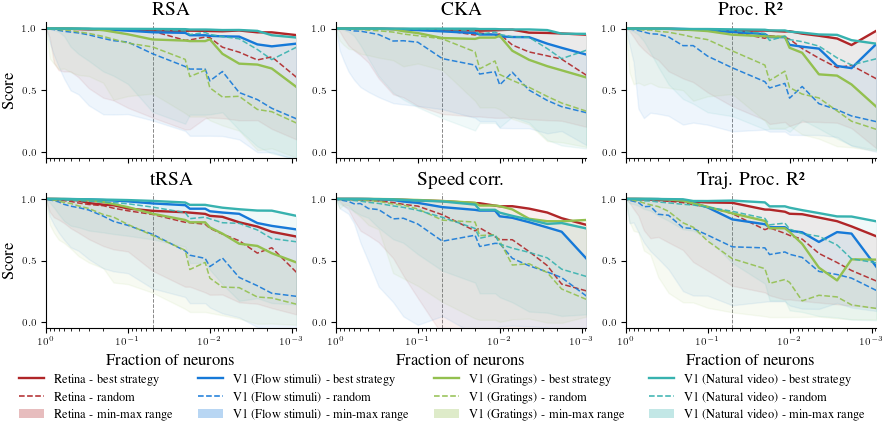

In [11]:
fig1 = make_sweep_figure(
    {
        'Retina':                                results_Retina,
        'V1':                                    results_V1,
        'allen_VISp':                            results_aVISp,
        'VISp_natural_movie_one_scenes_all156':  results_VISp,
    },
    fracs_Retina,
    include_traj=COMPUTE_TRAJ_IN_SWEEP,
    savepath=os.path.join(BASEDIR_FIG, 'fig1_fraction_sweep.pdf'),
)
plt.show()


In [12]:
# ── GW helper functions (shared between Figures 2 and 3) ─────────────────────
from src.metrics import compute_gromov_hausdorff_approx
from scipy.stats import ttest_rel as _ttr_gw

def _gw_dist(emb_full, idx_sub, n_comp=3, max_pts=1200, seed=0):
    """sqrt(GW cost) between full-pop and subpop MDS embeddings."""
    X_f = emb_full[:, :n_comp].astype(float)
    X_s = emb_full[idx_sub, :n_comp].astype(float)
    if len(X_f) > max_pts:
        rng = np.random.default_rng(seed)
        X_f = X_f[rng.choice(len(X_f), max_pts, replace=False)]
    return float(np.sqrt(compute_gromov_hausdorff_approx(X_f, X_s)))

def _gw_max_dist(emb_full, n_comp=3, max_pts=1200, seed=0):
    """GW distance between full pop and collapsed (all pts at centroid)."""
    X_f = emb_full[:, :n_comp].astype(float)
    if len(X_f) > max_pts:
        rng = np.random.default_rng(seed)
        X_f = X_f[rng.choice(len(X_f), max_pts, replace=False)]
    centroid = X_f.mean(0)
    X_c = np.tile(centroid, (len(X_f), 1)).astype(float)
    X_c += np.random.RandomState(42).normal(scale=1e-8, size=X_c.shape)
    return float(np.sqrt(compute_gromov_hausdorff_approx(X_f, X_c)))

def _gw_sim(emb_full, idx_sub, gw_max_val, **kw):
    gw = _gw_dist(emb_full, idx_sub, **kw)
    return float(np.clip(1.0 - gw / gw_max_val, 0.0, 1.0))

def _sig_str_gw(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _draw_bracket_gw(ax, x1, x2, y, h, text, fontsize=7):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.8, color='#444444')
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha='center', va='bottom',
            fontsize=fontsize, color='#444444')

# Datasets used for GW in Figs 2 & 3
_FIG23_DS = [
    ('Retina',     metrics_Retina, data_Retina['embedding_'],  tensor4d_Retina.shape[0]),
    ('V1',         metrics_V1,     data_V1['embedding_'],      tensor4d_V1.shape[0]),
    ('allen_VISp', metrics_aVISp,  data_aVISp['embedding_'],   tensor4d_aVISp.shape[0]),
    ('VISp_NM',    metrics_VISp,   data_VISp['embedding_'],    tensor4d_VISp.shape[0]),
]
_FIG4_DS = [
    ('Retina',     data_Retina['embedding_']),
    ('V1',         data_V1['embedding_']),
    ('allen_VISp', data_aVISp['embedding_']),
    ('VISp_NM',    data_VISp['embedding_']),
]

# Per-dataset GW_max (full vs collapsed) — used to normalize GW similarity to [0,1]
print('Computing GW_max for each dataset...')
_gw_max_vals = {}
for _pfx, _met, _emb, _N in _FIG23_DS:
    _gw_max_vals[_pfx] = _gw_max_dist(_emb)
    print(f'  {_pfx:12s}  GW_max={_gw_max_vals[_pfx]:.4f}')
print('GW helpers ready.')

Computing GW_max for each dataset...
  Retina        GW_max=0.2002
  V1            GW_max=0.3145
  Retina        GW_max=0.2002
  V1            GW_max=0.3145
  allen_VISp    GW_max=0.1982
  allen_VISp    GW_max=0.1982
  VISp_NM       GW_max=0.2951
GW helpers ready.
  VISp_NM       GW_max=0.2951
GW helpers ready.


## Figure 2 — Encoding Manifold Regions (5%)

**Left panels**: 2-D encoding manifold (DC0 x DC1), colored by subpopulation membership.
**Bottom panel**: 8-metric bar chart (subpop vs full population) + narrow GW hi/lo panel.
High/low rows = top/bottom 5% of neurons by PC contribution.

In [13]:
def select_subpop_by_metric(metrics, metric_name, frac, high, N):
    """Select top/bottom `frac` fraction of neurons by a named metric."""
    k = max(1, int(round(frac * N)))
    return select_top_k_by_metric(metrics, metric_name, k=k, high=high)


# ── Palette colors ────────────────────────────────────────────────────────
C_FULL        = '#888888'
C_FULL_ALPHA  = 0.55
C_SUBPOP      = '#ed7916'
C_BAR_STATIC  = '#1679d8'
C_BAR_TRAJ    = '#b02628'
C_DIAMOND     = '#000000'
C_TEXT        = '#000000'
C_DIVIDER     = '#888888'
C_FPS_SEED    = '#bb2427'
C_FPS_NN      = '#ed7916'

LEGEND_HANDLES = [
    Patch(facecolor=C_BAR_STATIC, edgecolor='none', label='subpopulation (static)'),
    Patch(facecolor=C_BAR_TRAJ,   edgecolor='none', label='subpopulation (trajectory)'),
    plt.Line2D([0],[0], marker='D', color=C_DIAMOND, linestyle='none',
               markersize=4, label='full population'),
]


def plot_metric_bars(ax, subpop_scores, full_scores, title=''):
    keys   = ALL_KEYS
    labels = [p[1] for p in METRIC_PANELS]
    colors = [C_BAR_STATIC if p[2]=='static' else C_BAR_TRAJ for p in METRIC_PANELS]
    x      = np.arange(len(keys))
    sub_v  = [subpop_scores.get(k, np.nan) for k in keys]
    full_v = [full_scores.get(k, np.nan)   for k in keys]

    bar_vals = [v if not np.isnan(v) else 0.0 for v in sub_v]
    bars = ax.bar(x, bar_vals, width=0.6, color=colors, edgecolor='none', zorder=2)

    for xi, sv, fv, bar in zip(x, sub_v, full_v, bars):
        if np.isnan(sv):
            bar.set_visible(False)
            ax.text(xi, 0.5, 'N/A', ha='center', va='center',
                    fontsize=FS_TICK, color=C_DIVIDER, style='italic')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{sv:.2f}', ha='center', va='bottom',
                    fontsize=FS_TICK, color=C_TEXT)
        if not np.isnan(fv):
            ax.plot(xi, fv, marker='D', color=C_DIAMOND,
                    markersize=4, zorder=3, clip_on=False)

    ns = len(STATIC_KEYS)
    ax.axvline(ns - 0.5, color=C_DIVIDER, lw=0.8, ls='--', zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=FS_TICK)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.set_ylim(0, 1.22)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_ylabel('Score', fontsize=FS_LABEL)
    if title:
        ax.set_title(title, fontsize=FS_TITLE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_3d_manifold(ax3d, embedding, mask_sel, mask_seed=None, mask_nn=None):
    """3-D scatter of encoding manifold with highlighted subpopulation."""
    emb = embedding[:, :3]
    ax3d.scatter(*emb[~mask_sel].T, c=C_FULL, s=2, alpha=0.35, depthshade=False,
                 linewidths=0, rasterized=True)
    if mask_nn is not None and mask_nn.any():
        ax3d.scatter(*emb[mask_nn].T, c=C_FPS_NN, s=10, alpha=0.85, depthshade=False,
                     linewidths=0, rasterized=True, zorder=3)
    if mask_seed is not None and mask_seed.any():
        ax3d.scatter(*emb[mask_seed].T, c=C_FPS_SEED, s=20, alpha=1.0, depthshade=False,
                     linewidths=0, rasterized=True, zorder=4)
    if mask_seed is None and mask_nn is None:
        ax3d.scatter(*emb[mask_sel].T, c=C_SUBPOP, s=10, alpha=0.9, depthshade=False,
                     linewidths=0, rasterized=True, zorder=3)

    # zoom=1.04 fills more of the axes box, minimising internal 3D margins
    try:
        ax3d.set_box_aspect([1, 1, 1], zoom=1.04)
    except TypeError:
        ax3d.set_box_aspect([1, 1, 1])
        try:
            ax3d.dist = 5
        except Exception:
            pass

    ax3d.view_init(elev=25, azim=45)
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    for pane in (ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor('none')
    ax3d.grid(False)
    ax3d.set_xlabel('DC 1', fontsize=7, labelpad=-18)
    ax3d.set_ylabel('DC 2', fontsize=7, labelpad=-18)
    ax3d.set_zlabel('DC 3', fontsize=7, labelpad=-18)


def _add_column_border(fig, axes_list, color, title_top, lw=1.5):
    """Draw one colored rectangle spanning all axes in a column, including title text."""
    from matplotlib.patches import Rectangle as _Rect
    positions = [ax.get_position() for ax in axes_list]
    x0 = min(p.x0 for p in positions)
    x1 = max(p.x1 for p in positions) - 0.005
    y0 = min(p.y0 for p in positions)
    y1 = title_top
    rect = _Rect((x0, y0), x1 - x0, y1 - y0,
                 fill=False, edgecolor=color, linewidth=lw,
                 transform=fig.transFigure, clip_on=False, zorder=10)
    fig.add_artist(rect)


# Metric display config for line plot
_METRIC_SHORT = ['kNN', 'RSA', 'CKA', 'Proc.R²', 'tRSA', 'Speed', 'tProc.', 'DSA']
_METRIC_KEYS  = ['acc', 'rdm', 'cka', 'r2', 'trsa', 'spc', 'tproc', 'dsa']
_N_STATIC     = 4


# ── TEST: bar-plot variant of the metric panel ────────────────────────────
# Drop-in replacement for plot_metric_lines; does not touch existing code.

def plot_metric_bars_grouped(ax, all_scores, labels, colors, linestyles,
                             style_labels=('solid', 'dashed'), all_errors=None,
                             yticks=None):
    """Grouped bar chart: each metric is one group, bars are subpopulations."""
    n_subs   = len(all_scores)
    n_mets   = len(_METRIC_KEYS)
    bar_w    = 0.8 / n_subs
    x        = np.arange(n_mets)

    for si, (scores, lbl, c, ls) in enumerate(zip(all_scores, labels, colors, linestyles)):
        vals    = [scores.get(k, np.nan) for k in _METRIC_KEYS]
        offsets = (si - (n_subs - 1) / 2) * bar_w
        hatch   = None if ls == '-' else '//'
        if all_errors:
            _e = [all_errors[si].get(k, 0) for k in _METRIC_KEYS]
            # asymmetric: cap upper whisker at 1.0
            errs = [_e, [min(e, max(1.0 - v, 0)) for e, v in zip(_e, vals)]]
        else:
            errs = None
        ax.bar(x + offsets, vals, width=bar_w, color=c, alpha=0.85,
               edgecolor='white', linewidth=0.4, hatch=hatch, zorder=2,
               yerr=errs, error_kw=dict(ecolor='#333333', lw=0.8, capsize=2, zorder=3))

    ax.axvline(_N_STATIC - 0.5, color=C_DIVIDER, lw=0.8, ls='--', zorder=1)
    ax.axhline(1.0, color='#aaaaaa', lw=0.7, ls='-', zorder=0)
    ax.set_xlim(-0.5, n_mets - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(_METRIC_SHORT, fontsize=FS_TICK)
    ax.set_ylim(0, 1.18)
    _yticks = yticks if yticks is not None else [0, 0.5, 1.0]
    ax.set_yticks(_yticks)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.set_ylabel('Score', fontsize=FS_LABEL)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    handles = []
    for si, (lbl, c, ls) in enumerate(zip(labels, colors, linestyles)):
        hatch = None if ls == '-' else '//'
        handles.append(Patch(facecolor=c, alpha=0.85, hatch=hatch,
                             edgecolor='white', label=lbl))
    ax.legend(handles=handles, ncol=4,
              bbox_to_anchor=(1.0, 1.14), loc='upper right',
              fontsize=FS_TICK - 1, frameon=False)


print('Figure helpers defined (bar, 3D manifold, metric lines).')


Figure helpers defined (bar, 3D manifold, metric lines).


In [14]:
def make_combined_figure(datasets, gw_hl_data=None, savepath=None):
    """4-column 3D encoding manifold grid + full-width metric bar chart.

    gw_hl_data: optional dict with 'hi_vals', 'lo_vals', 'p_val' to add a
                narrow GW hi/lo comparison panel to the right of the bar chart.
    """
    assert len(datasets) == 4
    assert all(len(d['rows']) == 2 for d in datasets)

    DS_COLORS = ['#b02628', '#1679d8', '#93c04f', '#37b2af']
    ROW_LS    = ['-', '--']
    N_COLS    = 4

    fig = plt.figure(figsize=(11.0, 8.5))

    gs = gridspec.GridSpec(2, N_COLS,
                           hspace=-0.08, wspace=0.0,
                           left=0.01, right=0.99,
                           top=0.93, bottom=0.23)

    TITLE_Y    = gs.top - 0.05
    BORDER_TOP = gs.top - 0.02

    _row_h      = (gs.top - gs.bottom) / 2
    _row1_top   = gs.top - _row_h
    ROW_LABEL_Y = [TITLE_Y, _row1_top + (TITLE_Y - gs.top)]
    _col_w      = (gs.right - gs.left) / N_COLS

    if gw_hl_data is not None:
        ax_metrics = fig.add_axes([0.06, 0.03, 0.74, 0.20])
        ax_gw_hl   = fig.add_axes([0.86, 0.03, 0.12, 0.20])
    else:
        ax_metrics = fig.add_axes([0.06, 0.03, 0.92, 0.20])
        ax_gw_hl   = None

    all_scores_lines = []
    line_labels      = []
    line_colors      = []
    line_styles      = []
    col_axes         = {ci: [] for ci in range(N_COLS)}

    for ci, ds in enumerate(datasets):
        PREFIX      = ds['prefix']
        tensor4d    = ds['tensor4d']
        stim_labels = ds['stim_labels']
        metrics_ds  = ds['metrics']
        embedding   = ds['explorer_data']['embedding_']
        color       = DS_COLORS[ci]

        N = tensor4d.shape[0]
        assert N == embedding.shape[0]

        coords_ref_knn, _ = compute_decoding_manifold(tensor4d, n_components=None)
        coords_ref,     _ = compute_decoding_manifold(tensor4d, n_components=15)
        acc_full          = min(1, max(knn_decoding_accuracy(coords_ref_knn, stim_labels), 1e-8))

        print(f'  Computing DSA ref z for {PREFIX}...')
        dsa_ref_z = compute_dsa(tensor4d, tensor4d)
        print(f'  DSA ref z: {dsa_ref_z}')
        if dsa_ref_z is None or np.isnan(dsa_ref_z) or dsa_ref_z < 1e-8:
            dsa_ref_z = None

        col_x_center = gs.left + (ci + 0.5) * _col_w
        col_x_left   = gs.left + ci * _col_w + 0.005
        for ri, (row_lbl, frac, high) in enumerate(ds['rows']):
            idx = select_subpop_by_metric(metrics_ds, 'pc_contrib', frac, high, N)
            direction = 'hi' if high else 'lo'
            print(f'  {PREFIX} {row_lbl}: pc_contrib {direction} {frac*100:.0f}% -> n={len(idx)}')

            mask_sel = np.zeros(N, dtype=bool)
            mask_sel[idx] = True

            ax3d = fig.add_subplot(gs[ri, ci], projection='3d')
            plot_3d_manifold(ax3d, embedding, mask_sel)
            col_axes[ci].append(ax3d)

            fig.text(col_x_left, ROW_LABEL_Y[ri], row_lbl,
                     ha='left', va='bottom', fontsize=FS_TITLE, fontweight='bold',
                     transform=fig.transFigure)

            _hi_lo = 'High' if high else 'Low'
            _row_title_fig2 = f'{_prefix_label_short(PREFIX)}: {_hi_lo} PC contrib.'
            fig.text(col_x_center, ROW_LABEL_Y[ri], _row_title_fig2,
                     ha='center', va='bottom', fontsize=FS_TITLE - 2, fontweight='bold',
                     transform=fig.transFigure)

            t_sub  = tensor4d[idx]
            scores = compute_all_metrics(
                tensor4d, t_sub, stim_labels,
                coords_ref=coords_ref, include_traj=True, neuron_idx=idx,
                dsa_ref_z=dsa_ref_z)

            if not np.isnan(scores.get('acc', np.nan)):
                scores['acc'] = min(1, scores['acc'] / acc_full)

            all_scores_lines.append(scores)
            line_labels.append(f'{row_lbl}')
            line_colors.append(color)
            line_styles.append(ROW_LS[ri])

    _border_offset = BORDER_TOP - TITLE_Y
    for ci, color in enumerate(DS_COLORS):
        for ri, ax in enumerate(col_axes[ci]):
            _add_column_border(fig, [ax], color, title_top=ROW_LABEL_Y[ri] + _border_offset)

    plot_metric_bars_grouped(ax_metrics, all_scores_lines, line_labels, line_colors, line_styles,
                          style_labels=('high pc_contrib', 'low pc_contrib'), yticks=[0, 0.8])

    # Optional GW hi/lo comparison panel
    if ax_gw_hl is not None and gw_hl_data is not None:
        _hi = np.array(gw_hl_data['hi_vals'])
        _lo = np.array(gw_hl_data['lo_vals'])
        _p  = gw_hl_data['p_val']
        _means = [_hi.mean(), _lo.mean()]
        _sems  = [_hi.std() / np.sqrt(len(_hi)), _lo.std() / np.sqrt(len(_lo))]
        ax_gw_hl.bar([0, 1], _means, width=0.55, color=['#555555', '#aaaaaa'],
                     alpha=0.85, zorder=2)
        ax_gw_hl.errorbar([0, 1], _means, yerr=_sems,
                          fmt='none', ecolor='#222222', elinewidth=1.2, capsize=4, zorder=3)
        _top = max(_means) + max(_sems)
        _h   = _top * 0.06
        _draw_bracket_gw(ax_gw_hl, 0, 1, _top * 1.08, _h, _sig_str_gw(_p), fontsize=FS_TICK)
        ax_gw_hl.set_xticks([0, 1])
        ax_gw_hl.set_xticklabels(['high', 'low'], fontsize=FS_TICK - 1)
        ax_gw_hl.set_ylabel('GW sim.', fontsize=FS_LABEL - 1)
        ax_gw_hl.set_ylim(bottom=0, top=_top * 1.08 + _h * 3.5)
        ax_gw_hl.tick_params(axis='y', labelsize=FS_TICK - 1)
        ax_gw_hl.spines['top'].set_visible(False)
        ax_gw_hl.spines['right'].set_visible(False)

    # Panel labels I (metric bars) and J (GW panel)
    _bbox_m = ax_metrics.get_position()
    fig.text(_bbox_m.x0 - 0.03, _bbox_m.y1 - 0.015, 'I',
             ha='left', va='bottom', fontsize=FS_TITLE, fontweight='bold',
             transform=fig.transFigure)
    if ax_gw_hl is not None:
        _bbox_g = ax_gw_hl.get_position()
        fig.text(_bbox_g.x0 - 0.05, _bbox_g.y1 - 0.015, 'J',
                 ha='left', va='bottom', fontsize=FS_TITLE, fontweight='bold',
                 transform=fig.transFigure)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'Saved: {savepath}')
    return fig


print('make_combined_figure() defined.')

make_combined_figure() defined.


## Figure 2 — Execution

GW hi/lo pooled 1%+5%+10%: hi=0.660, lo=0.559, p=0.0210 (n=12 pairs)

=== Generating Figure 2 (5%) ===
  Computing DSA ref z for Retina...
  DSA ref z: 18.455603964421258
  Retina A: pc_contrib hi 5% -> n=57
  DSA ref z: 18.455603964421258
  Retina A: pc_contrib hi 5% -> n=57
  Retina B: pc_contrib lo 5% -> n=57
  Retina B: pc_contrib lo 5% -> n=57
  Computing DSA ref z for V1...
  Computing DSA ref z for V1...
  DSA ref z: 44.026677955317815
  V1 C: pc_contrib hi 5% -> n=32
  DSA ref z: 44.026677955317815
  V1 C: pc_contrib hi 5% -> n=32
  V1 D: pc_contrib lo 5% -> n=32
  V1 D: pc_contrib lo 5% -> n=32
  Computing DSA ref z for allen_VISp...
  Computing DSA ref z for allen_VISp...
  DSA ref z: 6.263503065690791
  allen_VISp E: pc_contrib hi 5% -> n=98
  DSA ref z: 6.263503065690791
  allen_VISp E: pc_contrib hi 5% -> n=98
  allen_VISp F: pc_contrib lo 5% -> n=98
  allen_VISp F: pc_contrib lo 5% -> n=98
  Computing DSA ref z for VISp_natural_movie_one_scenes_all156...
  Computing DSA r

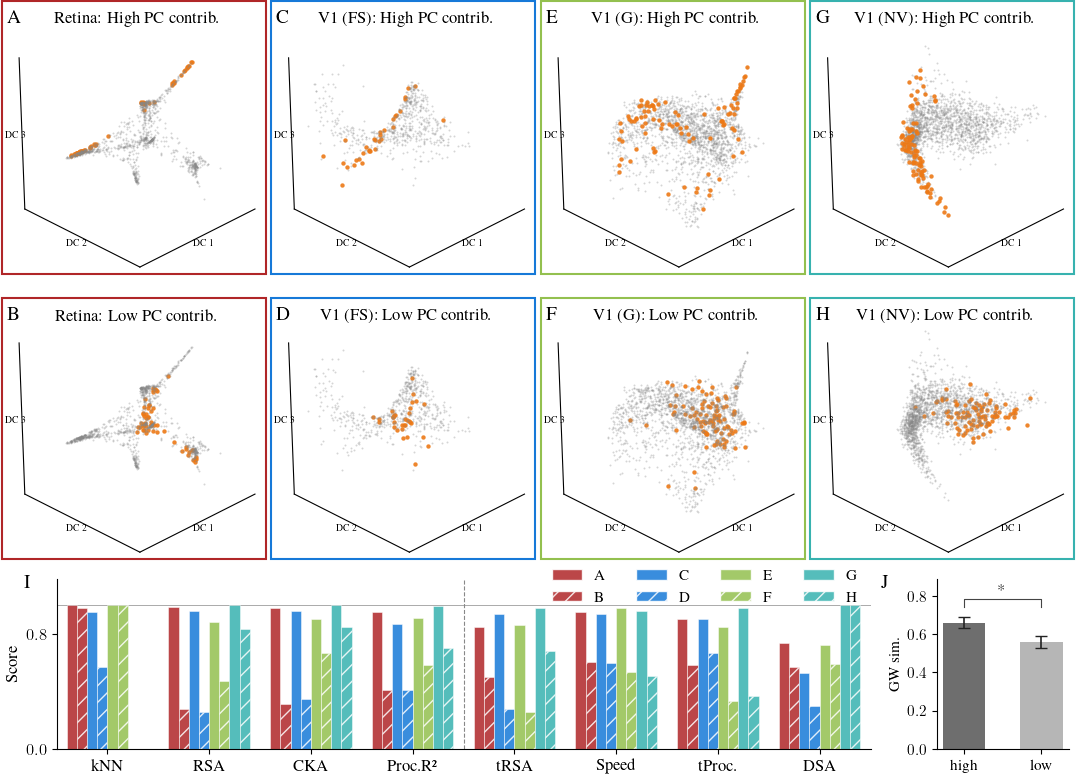

In [15]:
# ── Dataset config builder (reused for Figure 2 and Appendix Figs 6-7) ──────
def _make_datasets_fig(frac):
    lbl = ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H')
    return [
        dict(prefix='Retina', tensor4d=tensor4d_Retina,
             stim_labels=np.repeat(np.arange(NSTIMS_R), NDIRS_R),
             metrics=metrics_Retina, explorer_data=data_Retina,
             rows=[(lbl[0], frac, True), (lbl[1], frac, False)]),
        dict(prefix='V1', tensor4d=tensor4d_V1,
             stim_labels=np.repeat(np.arange(NSTIMS_V), NDIRS_V),
             metrics=metrics_V1, explorer_data=data_V1,
             rows=[(lbl[2], frac, True), (lbl[3], frac, False)]),
        dict(prefix='allen_VISp', tensor4d=tensor4d_aVISp,
             stim_labels=np.repeat(np.arange(NSTIMS_aVP), NDIRS_aVP),
             metrics=metrics_aVISp, explorer_data=data_aVISp,
             rows=[(lbl[4], frac, True), (lbl[5], frac, False)]),
        dict(prefix='VISp_natural_movie_one_scenes_all156',
             tensor4d=tensor4d_VISp,
             stim_labels=np.repeat(np.arange(NSTIMS_VP), NDIRS_VP),
             metrics=metrics_VISp, explorer_data=data_VISp,
             rows=[(lbl[6], frac, True), (lbl[7], frac, False)]),
    ]

# ── GW hi/lo pooled across 1%, 5%, 10% (n=12 pairs: 4 datasets x 3 fracs) ───
from scipy.stats import wilcoxon as _wc_stat
_GW_FRACS = [0.01, 0.05, 0.10]
_all_hi_pooled, _all_lo_pooled = [], []
for _frac in _GW_FRACS:
    for _pfx, _met, _emb, _N in _FIG23_DS:
        _all_hi_pooled.append(_gw_sim(_emb, select_subpop_by_metric(_met, 'pc_contrib', _frac, True,  _N), _gw_max_vals[_pfx]))
        _all_lo_pooled.append(_gw_sim(_emb, select_subpop_by_metric(_met, 'pc_contrib', _frac, False, _N), _gw_max_vals[_pfx]))
_, _p_hl_pooled = _wc_stat(_all_hi_pooled, _all_lo_pooled)
print(f'GW hi/lo pooled 1%+5%+10%: hi={np.mean(_all_hi_pooled):.3f}, lo={np.mean(_all_lo_pooled):.3f}, '
      f'p={_p_hl_pooled:.4f} (n={len(_all_hi_pooled)} pairs)')

# ── Figure 2: 5% regions + integrated GW panel (pooled across fractions) ─────
print('\n=== Generating Figure 2 (5%) ===')
fig2 = make_combined_figure(
    datasets=_make_datasets_fig(0.05),
    gw_hl_data={'hi_vals': _all_hi_pooled, 'lo_vals': _all_lo_pooled, 'p_val': _p_hl_pooled},
    savepath=os.path.join(BASEDIR_FIG, 'fig2_regions_05pct.pdf'),
)
plt.show()


## Figure 3 — FPS Subpopulation Sampling

Farthest-point sampling (smooth vs clustered) across 4 datasets.
Right panel: GW similarity per dataset, smooth vs clustered, with per-seed error bars and significance brackets.

In [16]:
from scipy.spatial.distance import cdist as _cdist

FPS_SMOOTH    = dict(n_seeds=50, m_neighbors=1)
FPS_CLUSTERED = dict(n_seeds=10, m_neighbors=9)
FPS_SEEDS     = [42, 43, 44, 45, 46]


def fps_select(embedding, n_seeds, m_neighbors, rng_seed=42):
    """Farthest-point sampling + nearest-neighbor expansion.

    Returns (all_idx, seed_idx).
    """
    emb3 = embedding[:, :3]
    N    = len(emb3)
    pw   = _cdist(emb3, emb3)

    rng   = np.random.default_rng(rng_seed)
    fps   = [int(rng.integers(N))]
    min_d = pw[fps[0]].copy()
    for _ in range(1, n_seeds):
        nxt = int(np.argmax(min_d))
        fps.append(nxt)
        min_d = np.minimum(min_d, pw[nxt])
    seed_idx = np.array(fps)

    selected       = set(seed_idx.tolist())
    dists_to_seeds = _cdist(emb3, emb3[seed_idx])
    for si in range(n_seeds):
        count = 0
        for j in np.argsort(dists_to_seeds[:, si]):
            if int(j) in selected:
                continue
            selected.add(int(j))
            count += 1
            if count >= m_neighbors:
                break

    return np.array(sorted(selected)), seed_idx


def make_fps_figure(datasets, gw_fps_data=None, savepath=None):
    """Figure 3: FPS sampling - 4-column 3D manifold grid + metric bar chart.

    gw_fps_data: optional dict mapping (prefix, mode) -> list of GW sims (per seed).
                 When provided, a GW comparison panel is appended to the right.
    """
    assert len(datasets) == 8

    DS_COLORS = {'Retina': '#b02628', 'V1': '#1679d8', 'allen_VISp': '#93c04f'}
    def _ds_color(prefix):
        for k, c in DS_COLORS.items():
            if prefix.startswith(k):
                return c
        return '#37b2af'

    MODE_LS = {'smooth': '-', 'clustered': '--'}
    N_COLS  = 4

    fig = plt.figure(figsize=(11.0, 8.5))

    gs = gridspec.GridSpec(2, N_COLS,
                           hspace=-0.08, wspace=0.0,
                           left=0.01, right=0.99,
                           top=0.93, bottom=0.23)

    TITLE_Y    = gs.top - 0.05
    BORDER_TOP = gs.top - 0.02

    _row_h      = (gs.top - gs.bottom) / 2
    _row1_top   = gs.top - _row_h
    ROW_LABEL_Y = [TITLE_Y, _row1_top + (TITLE_Y - gs.top)]
    _col_w      = (gs.right - gs.left) / N_COLS

    if gw_fps_data is not None:
        ax_metrics = fig.add_axes([0.06, 0.03, 0.64, 0.20])
        ax_gw_fps  = fig.add_axes([0.76, 0.03, 0.22, 0.20])
    else:
        ax_metrics = fig.add_axes([0.06, 0.03, 0.92, 0.20])
        ax_gw_fps  = None

    all_scores_lines = []
    all_errors_lines = []
    line_labels      = []
    line_colors      = []
    line_styles      = []

    _prefix_cache    = {}
    col_axes         = {ci: [] for ci in range(N_COLS)}
    col_colors       = {}

    for di, ds in enumerate(datasets):
        ci      = di // 2
        ri      = di % 2
        PREFIX  = ds['prefix']
        tensor4d    = ds['tensor4d']
        stim_labels = ds['stim_labels']
        embedding   = ds['explorer_data']['embedding_']
        fp          = ds['fps_params']
        row_lbl     = ds['row_label']
        mode_lbl    = ds.get('mode_label', '')
        color       = _ds_color(PREFIX)
        col_colors[ci] = color

        N = tensor4d.shape[0]
        assert N == embedding.shape[0]

        if PREFIX not in _prefix_cache:
            coords_ref_knn = compute_decoding_manifold(tensor4d, n_components=None)[0]
            coords_ref     = compute_decoding_manifold(tensor4d, n_components=15)[0]
            acc_full       = min(1, max(knn_decoding_accuracy(coords_ref_knn, stim_labels), 1e-8))
            print(f'  Computing DSA ref z for {PREFIX}...')
            dsa_z     = compute_dsa(tensor4d, tensor4d)
            dsa_ref_z = dsa_z if (dsa_z and not np.isnan(dsa_z) and dsa_z > 1e-8) else None
            print(f'  DSA ref z: {dsa_z}')
            _prefix_cache[PREFIX] = dict(coords_ref=coords_ref,
                                         acc_full=acc_full,
                                         dsa_ref_z=dsa_ref_z)

        coords_ref = _prefix_cache[PREFIX]['coords_ref']
        acc_full   = _prefix_cache[PREFIX]['acc_full']
        dsa_ref_z  = _prefix_cache[PREFIX]['dsa_ref_z']

        col_x_center = gs.left + (ci + 0.5) * _col_w
        col_x_left   = gs.left + ci * _col_w + 0.005

        _mode_title = 'Continuous sample' if mode_lbl == 'smooth' else 'Clustered sample'
        _row_title_fig3 = f'{_prefix_label_short(PREFIX)}: {_mode_title}'
        fig.text(col_x_center, ROW_LABEL_Y[ri], _row_title_fig3,
                 ha='center', va='bottom', fontsize=FS_TITLE - 2, fontweight='bold',
                 transform=fig.transFigure)

        idx, seed_idx = fps_select(embedding, fp['n_seeds'], fp['m_neighbors'])
        print(f'  {PREFIX} {mode_lbl}: {fp["n_seeds"]} seeds x {fp["m_neighbors"]} NN '
              f'-> {len(idx)} neurons ({100*len(idx)/N:.1f}%)')

        mask_sel  = np.zeros(N, dtype=bool); mask_sel[idx]       = True
        mask_seed = np.zeros(N, dtype=bool); mask_seed[seed_idx] = True
        mask_nn   = mask_sel & ~mask_seed

        ax3d = fig.add_subplot(gs[ri, ci], projection='3d')
        plot_3d_manifold(ax3d, embedding, mask_sel, mask_seed=mask_seed, mask_nn=mask_nn)
        col_axes[ci].append(ax3d)

        fig.text(col_x_left, ROW_LABEL_Y[ri], row_lbl,
                 ha='left', va='bottom', fontsize=FS_TITLE, fontweight='bold',
                 transform=fig.transFigure)

        t_sub  = tensor4d[idx]
        scores = compute_all_metrics(
            tensor4d, t_sub, stim_labels,
            coords_ref=coords_ref, include_traj=True,
            dsa_ref_z=dsa_ref_z)
        if not np.isnan(scores.get('acc', np.nan)):
            scores['acc'] = min(1.0, scores['acc'] / acc_full)

        _seed_scores = [scores]
        for _s in FPS_SEEDS[1:]:
            _idx_s, _ = fps_select(embedding, fp['n_seeds'], fp['m_neighbors'], rng_seed=_s)
            _t = tensor4d[_idx_s]
            _sc = compute_all_metrics(tensor4d, _t, stim_labels,
                                      coords_ref=coords_ref, include_traj=True,
                                      dsa_ref_z=dsa_ref_z)
            if not np.isnan(_sc.get('acc', np.nan)):
                _sc['acc'] = min(1.0, _sc['acc'] / acc_full)
            _seed_scores.append(_sc)
        errors = {k: float(np.nanstd([s.get(k, np.nan) for s in _seed_scores]))
                  for k in _METRIC_KEYS}

        all_scores_lines.append(scores)
        all_errors_lines.append(errors)
        line_labels.append(f'{row_lbl}')
        line_colors.append(color)
        line_styles.append(MODE_LS.get(mode_lbl, '-'))

    _border_offset = BORDER_TOP - TITLE_Y
    for ci in range(N_COLS):
        for ri, ax in enumerate(col_axes[ci]):
            _add_column_border(fig, [ax], col_colors[ci], title_top=ROW_LABEL_Y[ri] + _border_offset)

    plot_metric_bars_grouped(ax_metrics, all_scores_lines, line_labels, line_colors, line_styles,
                          style_labels=('smooth FPS', 'clustered FPS'),
                          all_errors=all_errors_lines, yticks=[0, 1.0])

    # Optional GW per-dataset panel
    if ax_gw_fps is not None and gw_fps_data is not None:
        from scipy.stats import ttest_rel as _ttr
        _n_ds = len(_FIG4_DS)
        _x4   = np.arange(_n_ds)
        _bw   = 0.35
        for _mode, _hatch, _off in [('cont.', '', -_bw/2), ('clust.', '//', _bw/2)]:
            _means = [np.mean(gw_fps_data[(_pfx, _mode)]) for _pfx, _ in _FIG4_DS]
            _sems  = [np.std(gw_fps_data[(_pfx, _mode)]) / np.sqrt(len(FPS_SEEDS))
                      for _pfx, _ in _FIG4_DS]
            _cols  = [_ds_color(_pfx) for _pfx, _ in _FIG4_DS]
            ax_gw_fps.bar(_x4 + _off, _means, width=_bw, color=_cols,
                          hatch=_hatch, edgecolor='white', linewidth=0.4,
                          alpha=0.85, label=_mode, zorder=2)
            ax_gw_fps.errorbar(_x4 + _off, _means, yerr=_sems,
                               fmt='none', ecolor='#333333', elinewidth=1.0, capsize=3, zorder=3)

        _y4_tops = []
        for _i, (_pfx, _) in enumerate(_FIG4_DS):
            _sm = gw_fps_data[(_pfx, 'cont.')]
            _cl = gw_fps_data[(_pfx, 'clust.')]
            _, _p4i = _ttr(_sm, _cl)
            _mn_sm = np.mean(_sm); _se_sm = np.std(_sm) / np.sqrt(len(FPS_SEEDS))
            _mn_cl = np.mean(_cl); _se_cl = np.std(_cl) / np.sqrt(len(FPS_SEEDS))
            _top_i = max(_mn_sm + _se_sm, _mn_cl + _se_cl)
            _y4_tops.append(_top_i)
            _h4i = _top_i * 0.05
            _draw_bracket_gw(ax_gw_fps, _x4[_i] - _bw/2, _x4[_i] + _bw/2,
                             _top_i * 1.08, _h4i, _sig_str_gw(_p4i), fontsize=FS_TICK - 2)

        ax_gw_fps.set_ylim(bottom=0,
                           top=max(_y4_tops) * 1.08 + max(_y4_tops) * 0.05 * 4.5)
        ax_gw_fps.set_xticks(_x4)
        ax_gw_fps.set_xticklabels([_p for _p, _ in _FIG4_DS],
                                  fontsize=FS_TICK - 2, rotation=20, ha='right')
        ax_gw_fps.set_ylabel('GW sim.', fontsize=FS_LABEL - 1)
        ax_gw_fps.tick_params(axis='y', labelsize=FS_TICK - 1)
        ax_gw_fps.spines['top'].set_visible(False)
        ax_gw_fps.spines['right'].set_visible(False)
        ax_gw_fps.legend(fontsize=FS_TICK - 4, frameon=False, loc='upper right')

    # Panel labels I (metric bars) and J (GW panel)
    _bbox_m3 = ax_metrics.get_position()
    fig.text(_bbox_m3.x0 - 0.03, _bbox_m3.y1 - 0.015, 'I',
             ha='left', va='bottom', fontsize=FS_TITLE, fontweight='bold',
             transform=fig.transFigure)
    if ax_gw_fps is not None:
        _bbox_g3 = ax_gw_fps.get_position()
        fig.text(_bbox_g3.x0 - 0.05, _bbox_g3.y1 - 0.015, 'J',
                 ha='left', va='bottom', fontsize=FS_TITLE, fontweight='bold',
                 transform=fig.transFigure)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'Saved: {savepath}')
    return fig


print('FPS figure helpers defined.')

FPS figure helpers defined.


  Computing DSA ref z for Retina...
  DSA ref z: 18.455603964421258
  Retina smooth: 50 seeds x 1 NN -> 100 neurons (8.8%)
  Retina clustered: 10 seeds x 9 NN -> 100 neurons (8.8%)
  Computing DSA ref z for V1...
  DSA ref z: 44.026677955317815
  V1 smooth: 50 seeds x 1 NN -> 100 neurons (15.9%)
  V1 clustered: 10 seeds x 9 NN -> 100 neurons (15.9%)
  Computing DSA ref z for allen_VISp...
  DSA ref z: 6.263503065690791
  allen_VISp smooth: 50 seeds x 1 NN -> 100 neurons (5.1%)
  allen_VISp clustered: 10 seeds x 9 NN -> 100 neurons (5.1%)
  Computing DSA ref z for VISp_natural_movie_one_scenes_all156...
  DSA ref z: 10.74072336277295
  VISp_natural_movie_one_scenes_all156 smooth: 50 seeds x 1 NN -> 100 neurons (5.0%)
  VISp_natural_movie_one_scenes_all156 clustered: 10 seeds x 9 NN -> 100 neurons (5.0%)
Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig3_fps_subpops.pdf


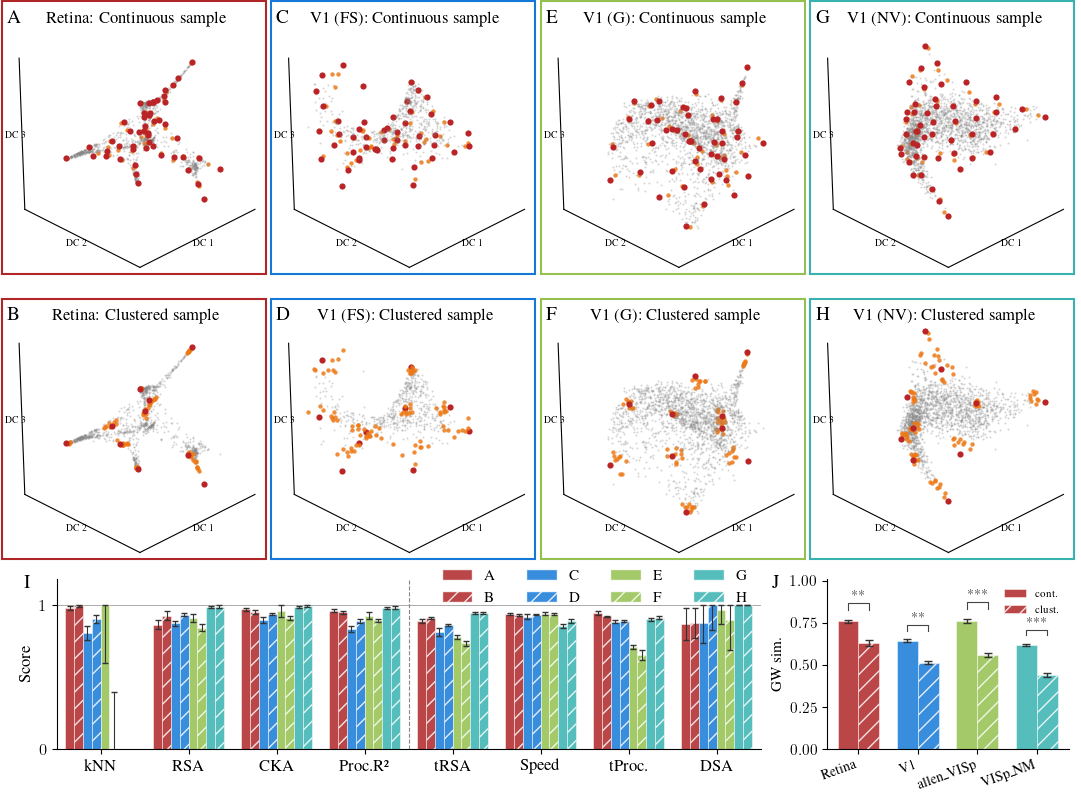

In [17]:
fps_datasets = [
    dict(prefix='Retina', tensor4d=tensor4d_Retina,
         stim_labels=np.repeat(np.arange(NSTIMS_R), NDIRS_R),
         explorer_data=data_Retina,
         fps_params=FPS_SMOOTH,    row_label='A', mode_label='smooth'),
    dict(prefix='Retina', tensor4d=tensor4d_Retina,
         stim_labels=np.repeat(np.arange(NSTIMS_R), NDIRS_R),
         explorer_data=data_Retina,
         fps_params=FPS_CLUSTERED, row_label='B', mode_label='clustered'),
    dict(prefix='V1', tensor4d=tensor4d_V1,
         stim_labels=np.repeat(np.arange(NSTIMS_V), NDIRS_V),
         explorer_data=data_V1,
         fps_params=FPS_SMOOTH,    row_label='C', mode_label='smooth'),
    dict(prefix='V1', tensor4d=tensor4d_V1,
         stim_labels=np.repeat(np.arange(NSTIMS_V), NDIRS_V),
         explorer_data=data_V1,
         fps_params=FPS_CLUSTERED, row_label='D', mode_label='clustered'),
    dict(prefix='allen_VISp', tensor4d=tensor4d_aVISp,
         stim_labels=np.repeat(np.arange(NSTIMS_aVP), NDIRS_aVP),
         explorer_data=data_aVISp,
         fps_params=FPS_SMOOTH,    row_label='E', mode_label='smooth'),
    dict(prefix='allen_VISp', tensor4d=tensor4d_aVISp,
         stim_labels=np.repeat(np.arange(NSTIMS_aVP), NDIRS_aVP),
         explorer_data=data_aVISp,
         fps_params=FPS_CLUSTERED, row_label='F', mode_label='clustered'),
    dict(prefix='VISp_natural_movie_one_scenes_all156',
         tensor4d=tensor4d_VISp,
         stim_labels=np.repeat(np.arange(NSTIMS_VP), NDIRS_VP),
         explorer_data=data_VISp,
         fps_params=FPS_SMOOTH,    row_label='G', mode_label='smooth'),
    dict(prefix='VISp_natural_movie_one_scenes_all156',
         tensor4d=tensor4d_VISp,
         stim_labels=np.repeat(np.arange(NSTIMS_VP), NDIRS_VP),
         explorer_data=data_VISp,
         fps_params=FPS_CLUSTERED, row_label='H', mode_label='clustered'),
]


# ── GW per-dataset for FPS modes (smooth vs clustered) ───────────────────────
_gw_fps_data = {}
for _pfx, _emb in _FIG4_DS:
    _mx = _gw_max_vals[_pfx]
    for _mode, _fp in [('cont.', FPS_SMOOTH), ('clust.', FPS_CLUSTERED)]:
        _gw_fps_data[(_pfx, _mode)] = [
            _gw_sim(_emb, fps_select(_emb, _fp['n_seeds'], _fp['m_neighbors'], rng_seed=_s)[0], _mx)
            for _s in FPS_SEEDS
        ]

fig3 = make_fps_figure(
    fps_datasets,
    gw_fps_data=_gw_fps_data,
    savepath=os.path.join(BASEDIR_FIG, 'fig3_fps_subpops.pdf'),
)
plt.show()


## 7 — Figure 4: MNIST Concept Figure (Encoding vs Decoding)

**Prerequisites:** Run notebook 21 end-to-end first to generate `data/mnist_manifold/fig_data_baseline_vs_lam10.pkl`.

In [18]:
import pickle as _p6
import json as _j6
import numpy as np
from scipy.spatial.distance import cdist as _cdist6
from scipy import stats as _stats6
from matplotlib.patches import FancyArrowPatch
import os, matplotlib as _mpl6

with open(os.path.join(BASEDIR, 'data', 'mnist_manifold', 'fig_data_baseline_vs_lam10.pkl'), 'rb') as _f:
    _d6 = _p6.load(_f)
with open(os.path.join(BASEDIR, 'data', 'mnist_manifold', 'ood_robustness_results.json')) as _f:
    _ood6 = _j6.load(_f)

_mds6  = _d6['mds_emb'];  _dec6  = _d6['dec_coords']
_pref6 = _d6['pref_class']; _keep6 = _d6['ian_nonoutliers']
_stim6 = _d6['stim_lbl'];  _tv6   = _d6['tuning']
_accs6 = _d6['accs'];      _knn6  = _d6['knn_scores']
_DC6   = _d6['DIGIT_COLORS']

_CONDS6  = ['baseline', 'cluster_pref_stim_lam10']
_CTITLE6 = ['Continuous', 'Clustered']
_CCOL6   = ['#00218e', '#691318']
_CBORD6  = ['#3a6bbf', '#a03030']
_ICOL6   = ['#e6194b', '#f58231', '#ffe119', '#3cb44b',
            '#4363d8', '#911eb4', '#42d4f4', '#f032e6',
            '#bfef45', '#fabed4']
_N_INSET6    = 10
_BAR_N_COLS  = 1
_BAR_W_AX    = 0.17
_BAR_H_AX    = 0.085
_BAR_X_AX    = 1.04
_BAR_GAP     = 0.012
_BAR_COL_GAP = 0.025

def _fps6(pts, n):
    D = _cdist6(pts, pts)
    sel = [int(np.argmax(pts[:, 0]))]
    md  = D[sel[0]].copy()
    for _ in range(n - 1):
        nxt = int(np.argmax(md)); sel.append(nxt); md = np.minimum(md, D[nxt])
    return np.array(sel)

_fps_idx6 = {c: _fps6(_mds6[c][:, :2], _N_INSET6) for c in _CONDS6}

_PARTS_DIR = os.path.join(BASEDIR_FIG, 'fig6_parts')
os.makedirs(_PARTS_DIR, exist_ok=True)
print('Fig6 setup done.')

Fig6 setup done.


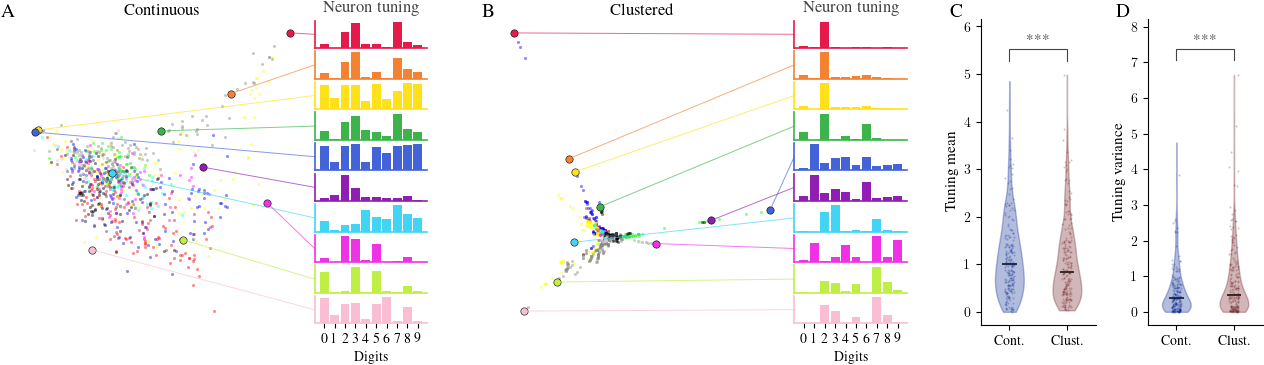

Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig6_parts/enc_violin_combined.pdf


In [29]:
# ── Combined 3-panel figure: [enc_cont | enc_clust | violin] ─────────────────
# Each manifold panel: 2-D scatter with inset bar plots stacked on the right
# (matching original style). 8 FPS neurons sorted top-to-bottom by y-position.
# Leader lines (ConnectionPatch) link each scatter dot to its inset bar axes.
# Violin panel: bracket + stars significance (matching GW figure style).

from matplotlib.patches import ConnectionPatch
from matplotlib import gridspec as _gs6

_N_INSET_C  = 10      # neurons per manifold panel
_BAR_W_C    = 0.4   # inset width  (axes fraction)
_BAR_H_C    = 0.09   # inset height (axes fraction)
_BAR_X_C    = 1.04   # inset left edge (axes fraction, to the right of scatter)
_BAR_GAP_C  = 0.010  # gap between insets
_FIG_W_C, _FIG_H_C = 12.8, 3.6

# recompute FPS with N=8
_fps_idx6_c = {c: _fps6(_mds6[c][:, :2], _N_INSET_C) for c in _CONDS6}

# -- significance helpers (matching GW cell style) ----------------------------
def _sig_str_c(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _draw_bracket_c(ax, x1, x2, y, h, text, fontsize=7):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.8, color='#444444')
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha='center', va='bottom',
            fontsize=fontsize, color='#444444')

fig_c = plt.figure(figsize=(_FIG_W_C, _FIG_H_C))
outer_c = _gs6.GridSpec(
    1, 3, figure=fig_c,
    width_ratios=[3.0, 3.0, 3.0],
    left=0.02, right=0.99, top=0.91, bottom=0.06,
    wspace=0.7,   # extra space between panels to accommodate right-side insets
)

# ── Panels 0 & 1: encoding manifolds with right-side inset bar plots ──────────
for _ci, _cond in enumerate(_CONDS6):
    _ax_sc = fig_c.add_subplot(outer_c[_ci])

    _em_c = _mds6[_cond][:, :2]
    _pc_c = _pref6[_cond][_keep6[_cond]]

    # Background scatter colored by preferred digit
    for _d in range(10):
        _m_c = (_pc_c == _d)
        _ax_sc.scatter(_em_c[_m_c, 0], _em_c[_m_c, 1],
                       color=_DC6[_d], s=5, alpha=0.45, lw=0, rasterized=True)

    # FPS neurons sorted top-to-bottom by y-position (highest y first)
    _fps_c = _fps_idx6_c[_cond]
    _fps_c = _fps_c[np.argsort(_em_c[_fps_c, 1])[::-1]]

    # Cherry-picked overrides: replace specific ranks with hand-chosen neurons
    _FPS_OVERRIDES_C = {
        'baseline':                  {9: 553},   # near green instead of distant light-pink
        'cluster_pref_stim_lam10':   {5: 519},   # between red & green instead of purple
    }
    for _rank_o, _new_ni in _FPS_OVERRIDES_C.get(_cond, {}).items():
        _fps_c[_rank_o] = _new_ni
    _fps_c = _fps_c[np.argsort(_em_c[_fps_c, 1])[::-1]]  # re-sort after overrides

    # Compute vertical layout for the inset stack
    _total_bar_h_c = _N_INSET_C * _BAR_H_C + (_N_INSET_C - 1) * _BAR_GAP_C
    _y0_c = (1.0 - _total_bar_h_c) / 2

    for _rank, _ni in enumerate(_fps_c):
        _ic = _ICOL6[_rank % len(_ICOL6)]
        _iy = _y0_c + (_N_INSET_C - 1 - _rank) * (_BAR_H_C + _BAR_GAP_C)

        _ax_sc.scatter(_em_c[_ni, 0], _em_c[_ni, 1],
                       color=_ic, s=28, edgecolors='k', linewidths=0.4, zorder=8)

        _ax_b = _ax_sc.inset_axes(
            [_BAR_X_C, _iy, _BAR_W_C, _BAR_H_C],
            transform=_ax_sc.transAxes,
        )
        _ax_b.bar(np.arange(10), _tv6[_cond][_ni],
                  color=_ic, width=0.85, edgecolor='none')
        _ax_b.set_yticks([])
        # Only the bottom-most inset (rank == N-1, lowest _iy) gets digit labels
        if _rank == _N_INSET_C - 1:
            _ax_b.set_xticks(np.arange(10))
            _ax_b.set_xticklabels([str(_d) for _d in range(10)],
                                   fontsize=10)
            # X label to Digits
            _ax_b.set_xlabel('Digits', fontsize=10)
        else:
            _ax_b.set_xticks([])
        for _sk in ('top', 'right'):
            _ax_b.spines[_sk].set_visible(False)
        for _sk in ('left', 'bottom'):
            _ax_b.spines[_sk].set_color(_ic)
            _ax_b.spines[_sk].set_linewidth(1.2)
        _ax_b.patch.set_visible(False)

        # Leader line: scatter dot -> left-centre of inset axes
        _con = ConnectionPatch(
            xyA=(_em_c[_ni, 0], _em_c[_ni, 1]),
            xyB=(0.0, 0.5),
            coordsA='data', coordsB='axes fraction',
            axesA=_ax_sc, axesB=_ax_b,
            color=_ic, lw=0.7, alpha=0.65, zorder=5,
        )
        fig_c.add_artist(_con)

    _ax_sc.text(_BAR_X_C + _BAR_W_C / 2, _y0_c + _total_bar_h_c + 0.015,
                'Neuron tuning',
                transform=_ax_sc.transAxes, fontsize=FS_TICK,
                ha='center', va='bottom', color='#444444')

    _ax_sc.set_xticks([]); _ax_sc.set_yticks([])
    _ax_sc.margins(0.05)
    for _sp in _ax_sc.spines.values(): _sp.set_visible(False)
    _ax_sc.set_title(_CTITLE6[_ci], fontsize=FS_LABEL, pad=3)
    _ax_sc.text(-0.02, 1.05, ['A', 'B'][_ci], transform=_ax_sc.transAxes,
                fontsize=FS_LABEL + 2, fontweight='bold', va='top', ha='right')

# ── Panel 2: violin (mean & variance) ────────────────────────────────────────
_viol_inner_c = _gs6.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=outer_c[2], wspace=0.45,
)
_vars6_c  = [_tv6[c].var(axis=1)  for c in _CONDS6]
_means6_c = [_tv6[c].mean(axis=1) for c in _CONDS6]
_rng6_c = np.random.default_rng(0)

for _axi_c, (_data6_c, _ylabel_c) in enumerate(
        zip([_means6_c, _vars6_c], ['Tuning mean', 'Tuning variance'])):
    _ax_v = fig_c.add_subplot(_viol_inner_c[_axi_c])
    _vp6_c = _ax_v.violinplot(_data6_c, positions=[0, 1],
                               showmedians=True, showextrema=False)
    for _body_c, _col_c in zip(_vp6_c['bodies'], _CCOL6):
        _body_c.set_facecolor(_col_c); _body_c.set_alpha(0.30)
        _body_c.set_edgecolor(_col_c)
    _vp6_c['cmedians'].set_color('#222222'); _vp6_c['cmedians'].set_linewidth(1.3)
    for _xi_c, (_v_c, _col_c) in enumerate(zip(_data6_c, _CCOL6)):
        _sub_c = _rng6_c.choice(len(_v_c), 200, replace=False)
        _ax_v.scatter(
            _xi_c + _rng6_c.uniform(-0.08, 0.08, 200), _v_c[_sub_c],
            color=_col_c, s=2, alpha=0.28, lw=0, zorder=3,
        )
    # Bracket + stars significance
    _, _pval_c = _stats6.mannwhitneyu(_data6_c[0], _data6_c[1], alternative='two-sided')
    _ym_c = max(_v_c.max() for _v_c in _data6_c)
    _draw_bracket_c(_ax_v, 0, 1, _ym_c * 1.06, _ym_c * 0.05,
                    _sig_str_c(_pval_c), fontsize=FS_TICK - 1)
    _ax_v.set_ylim(top=_ym_c * 1.06 + _ym_c * 0.05 * 3.5)
    _ax_v.set_xticks([0, 1])
    _ax_v.set_xticklabels(['Cont.', 'Clust.'], fontsize=FS_TICK - 2)
    _ax_v.set_ylabel(_ylabel_c, fontsize=FS_LABEL - 1)
    _ax_v.set_xlim(-0.5, 1.5)
    _ax_v.tick_params(axis='y', labelsize=FS_TICK - 2)
    _ax_v.spines['top'].set_visible(False); _ax_v.spines['right'].set_visible(False)
    _ax_v.text(-0.15, 1.05, ['C', 'D'][_axi_c], transform=_ax_v.transAxes,
               fontsize=FS_LABEL + 2, fontweight='bold', va='top', ha='right')

_out_c = os.path.join(_PARTS_DIR, 'enc_violin_combined.pdf')
fig_c.savefig(_out_c, dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()
print(f'Saved: {_out_c}')


## Table 1 — MNIST Toy Model: Numerical Results & p-values

Loads 10 baseline and 10 clustered (lambda=10) checkpoints.
Computes all metrics from scratch (no pickle). Gaussian blur robustness included.
Also ports the 6-panel graph connectivity analysis from Notebook 23.

In [21]:
# ── Imports for model loading (from notebook 21 pattern) ─────────────────────
import sys, os, torch
import torch.nn.functional as F_torch
from torchvision.transforms import functional as TF
import torchvision.transforms as T_tv
from scipy.stats import wilcoxon as _wc_t1, ttest_rel as _ttr_t1

_nb21_here = os.path.join(BASEDIR, 'notebooks')
if _nb21_here not in sys.path:
    sys.path.insert(0, _nb21_here)

# Import utilities from src (already available), plus mnist-specific ones
from src.mnist_utils import (
    load_mnist_data, train_or_load_cnn, test_accuracy,
    compute_tuning_vecs, build_tensor4d, encoding_pca,
)

# Parameters matching notebook 21 OOD section
_T1_MAX_EPOCHS = 5
_T1_LR         = 1e-3
_T1_BATCH_SIZE = 256
_T1_CKPT_DIR   = os.path.join(BASEDIR, 'data', 'mnist_manifold')
_T1_DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

_T1_LAMBDAS = [0.0, 10]
_T1_SEEDS   = list(range(20))
_T1_LAM_STYLE = {
    0.0:  {'color': '#00218e', 'label': 'Baseline'},
    10:   {'color': '#691318', 'label': 'Clustered (lam=10)'},
}

# Load data loaders
_t1_train_loader, _t1_test_loader = load_mnist_data(batch_size=_T1_BATCH_SIZE)

# Load 10 checkpoints per condition
print('Loading model checkpoints...')
_T1_MODELS = {}
for _lam in _T1_LAMBDAS:
    _cond = 'baseline' if _lam == 0.0 else 'cluster_pref_stim'
    for _seed in _T1_SEEDS:
        _m, _ = train_or_load_cnn(
            _cond, seed=_seed,
            train_loader=_t1_train_loader, ckpt_dir=_T1_CKPT_DIR,
            n_epochs=_T1_MAX_EPOCHS, lr=_T1_LR, device=_T1_DEVICE,
            lam=_lam, val_loader=None,
        )
        _T1_MODELS[(_lam, _seed)] = _m
print(f'Loaded {len(_T1_MODELS)} models ({len(_T1_SEEDS)} seeds x {len(_T1_LAMBDAS)} conditions).')


Loading model checkpoints...
  Loaded from cache: cnn_baseline_lam0.0_e5_s0.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s1.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s2.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s3.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s4.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s5.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s6.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s7.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s8.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s9.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s10.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s11.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s12.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s13.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s14.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s15.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s16.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s17.pt
  Loaded from cache: cnn_baseline_lam0.0_e5_s18.pt
  Loaded fro

Loading Table 1 results from cache...
Cache missing gw_ian — will recompute GW IAN for all seeds.
Computing per-seed metrics starting from seed index 0...
  seed 0: computing IAN/MDS for baseline and clustered...


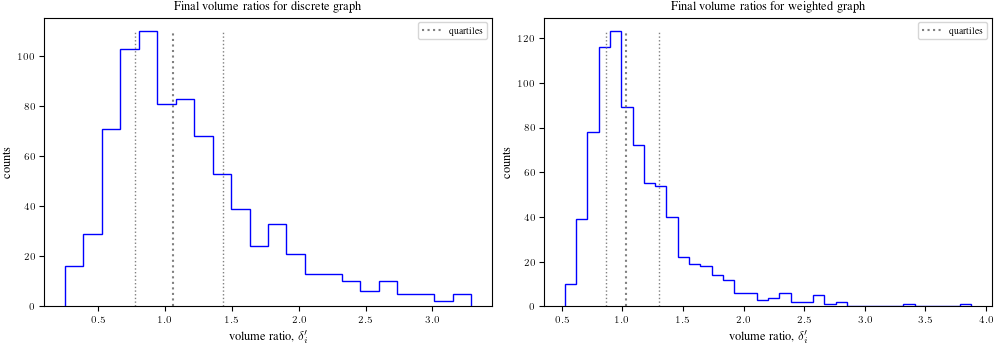

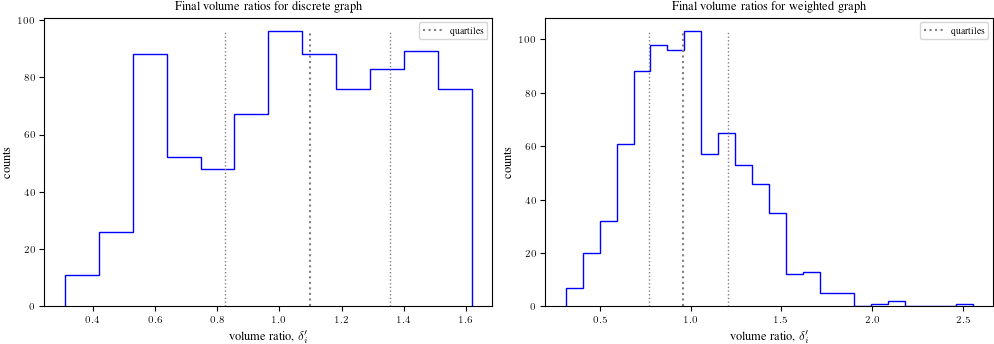

  seed 0: GW IAN sim=0.6208  (gw=0.0522, gw_max=0.1376)
  seed 0 done — cache updated.
  seed 1: computing IAN/MDS for baseline and clustered...


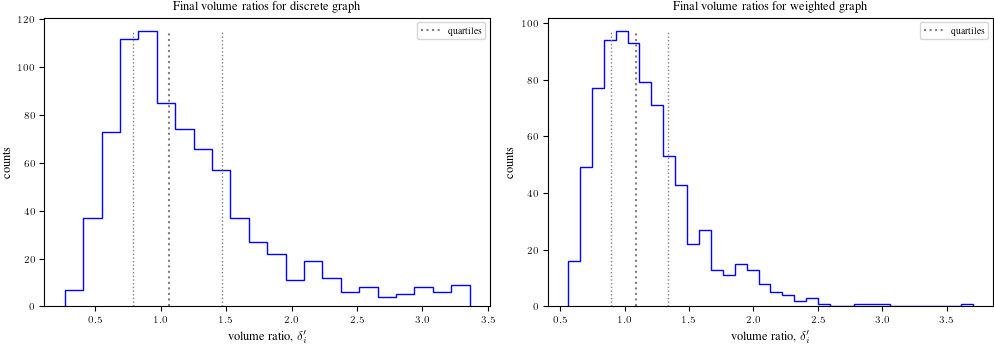

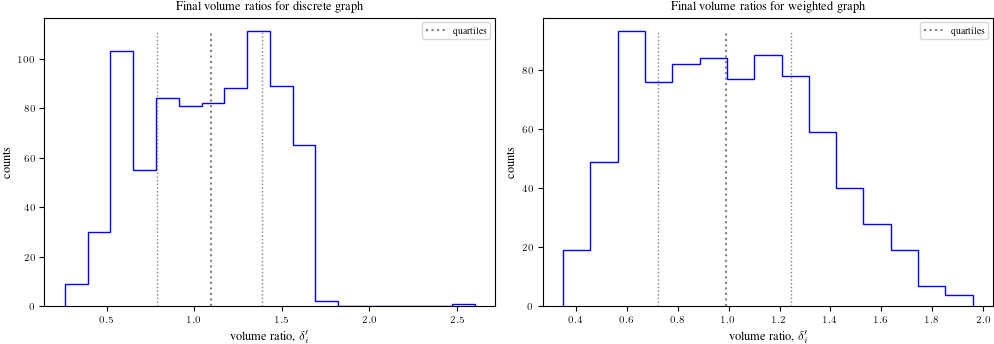

  seed 1: GW IAN sim=0.3959  (gw=0.0808, gw_max=0.1338)
  seed 1 done — cache updated.
  seed 2: computing IAN/MDS for baseline and clustered...


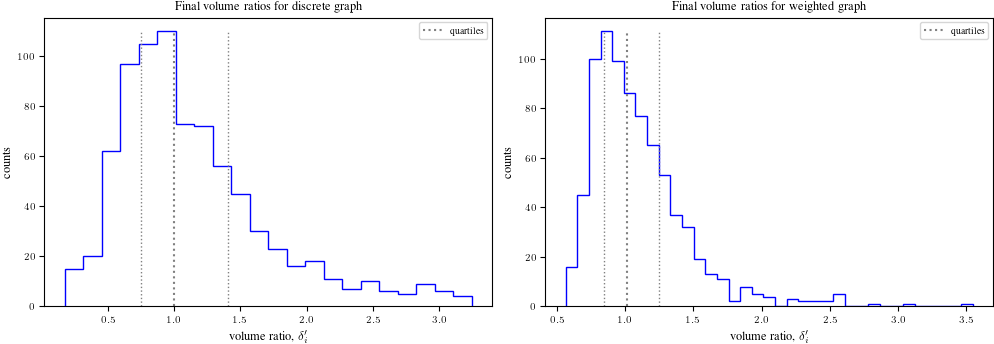

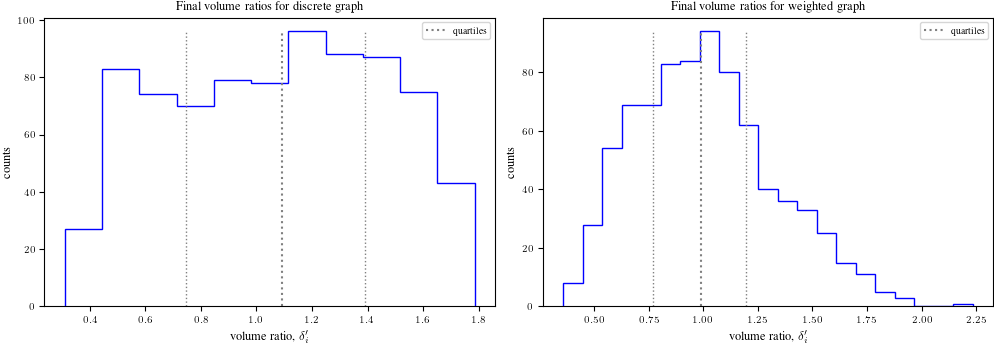

  seed 2: GW IAN sim=0.5439  (gw=0.0641, gw_max=0.1405)
  seed 2 done — cache updated.
  seed 3: computing IAN/MDS for baseline and clustered...


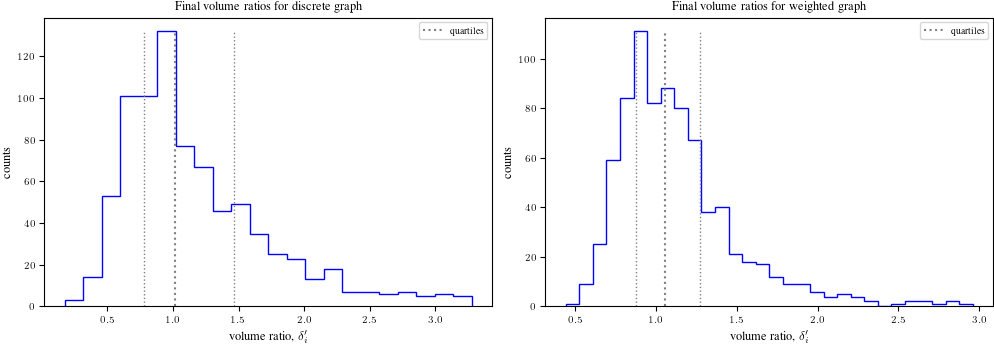

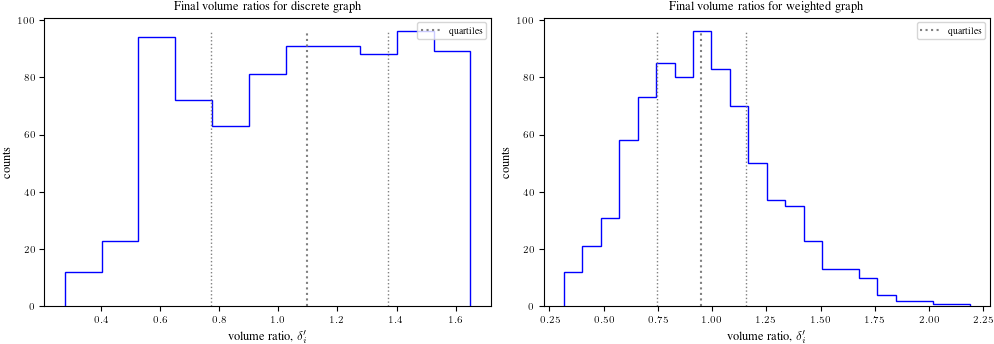

  seed 3: GW IAN sim=0.3944  (gw=0.0768, gw_max=0.1268)
  seed 3 done — cache updated.
  seed 4: computing IAN/MDS for baseline and clustered...


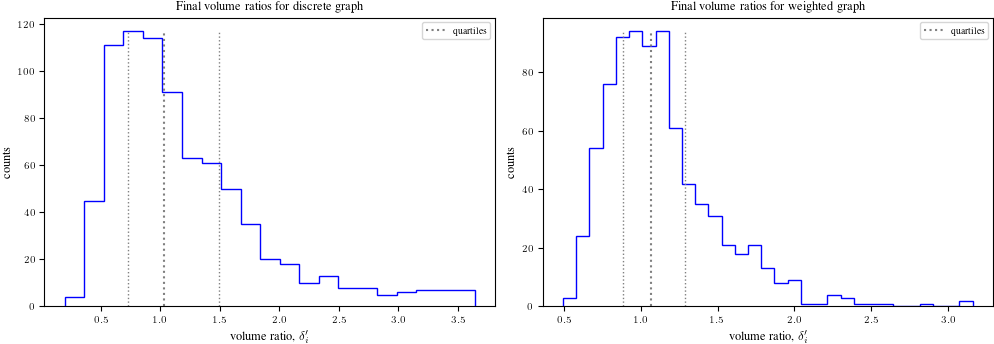

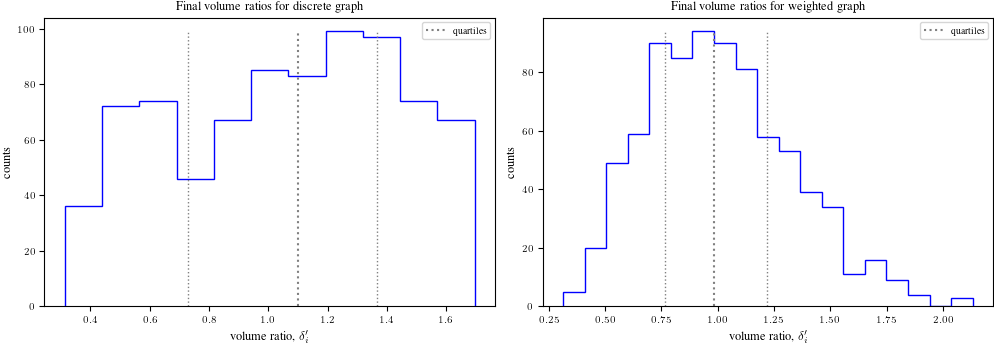

  seed 4: GW IAN sim=0.5377  (gw=0.0608, gw_max=0.1316)
  seed 4 done — cache updated.
  seed 5: computing IAN/MDS for baseline and clustered...


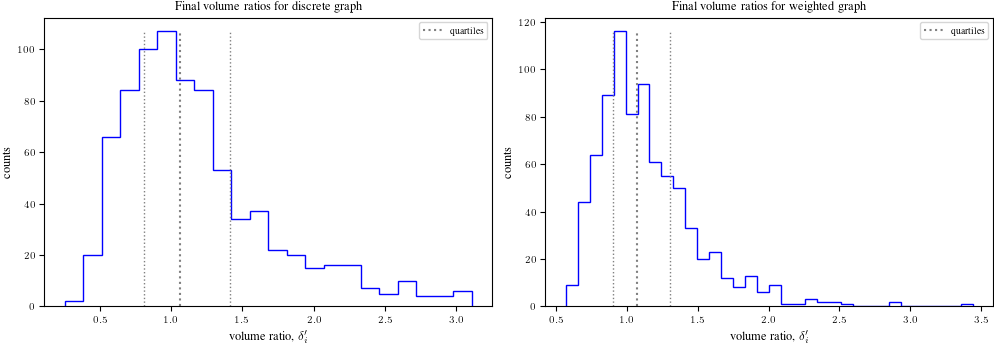

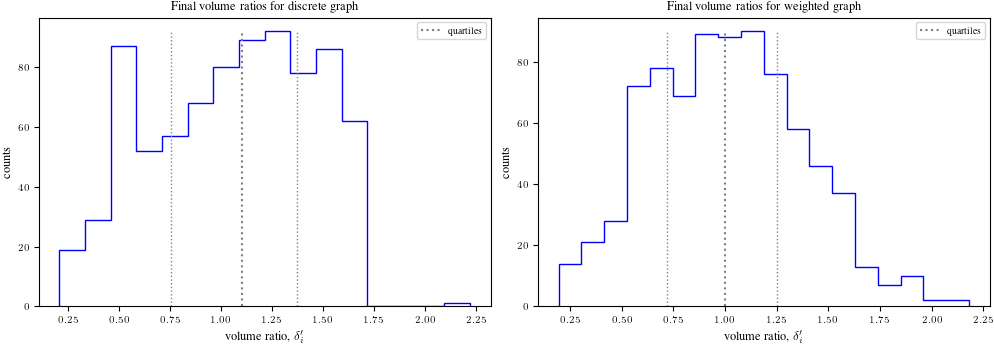

  seed 5: GW IAN sim=0.3404  (gw=0.0884, gw_max=0.1340)
  seed 5 done — cache updated.
  seed 6: computing IAN/MDS for baseline and clustered...


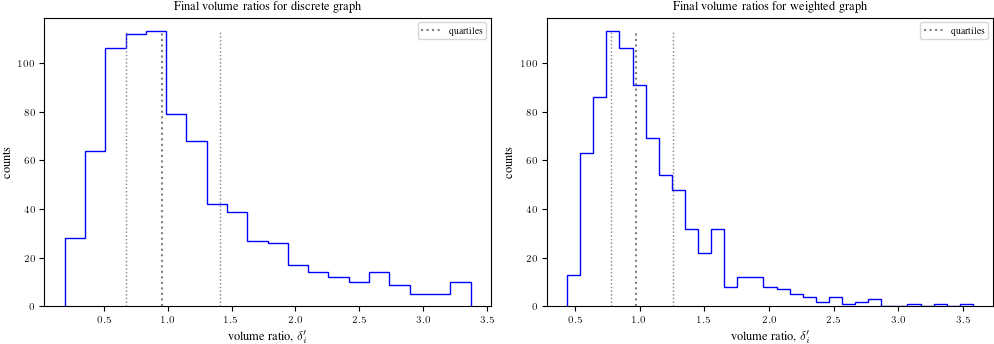

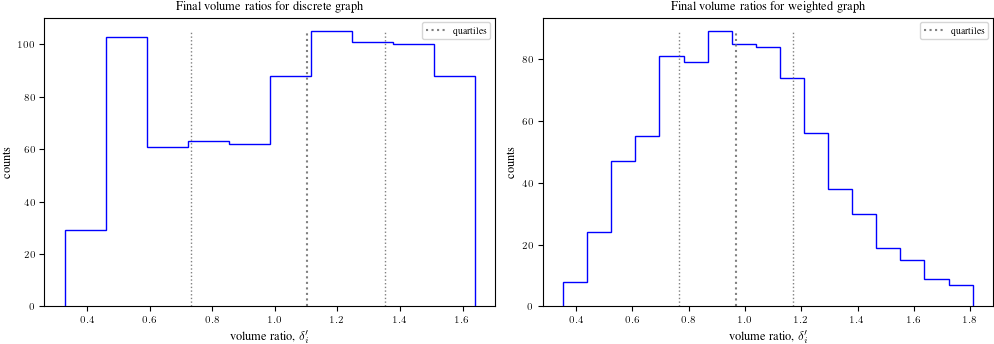

  seed 6: GW IAN sim=0.4190  (gw=0.0847, gw_max=0.1459)
  seed 6 done — cache updated.
  seed 7: computing IAN/MDS for baseline and clustered...


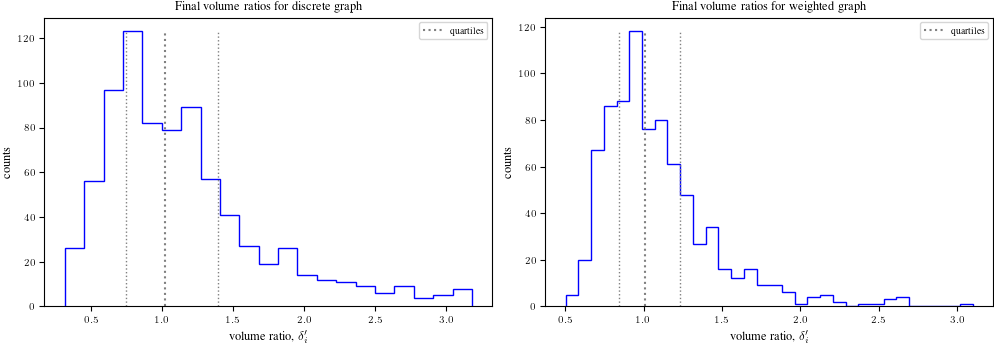

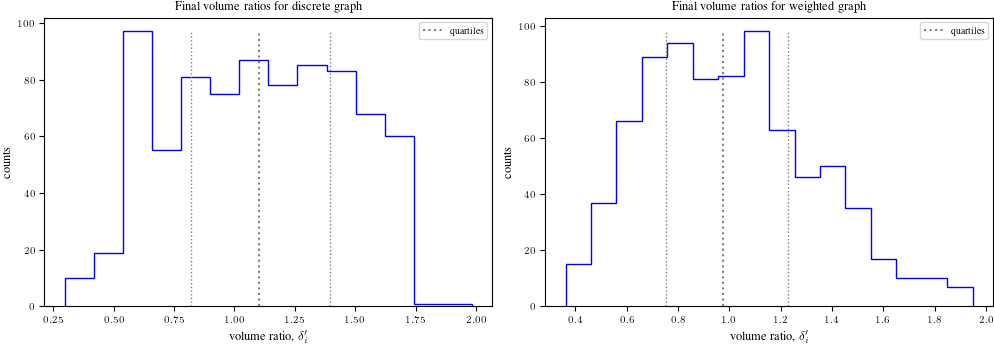

  seed 7: GW IAN sim=0.5325  (gw=0.0613, gw_max=0.1312)
  seed 7 done — cache updated.
  seed 8: computing IAN/MDS for baseline and clustered...


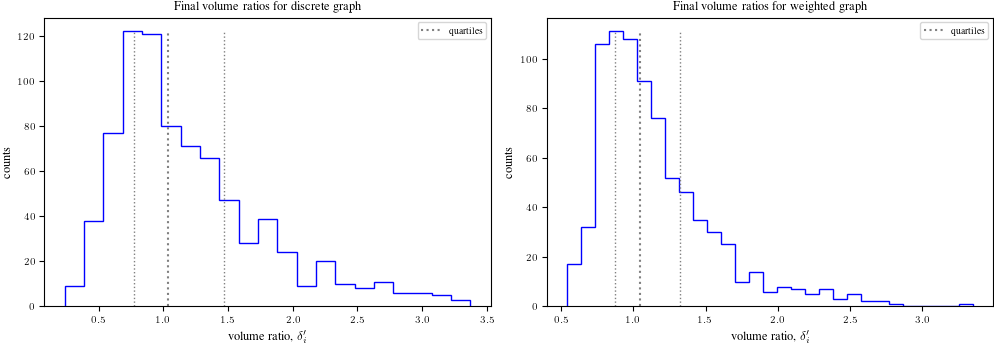

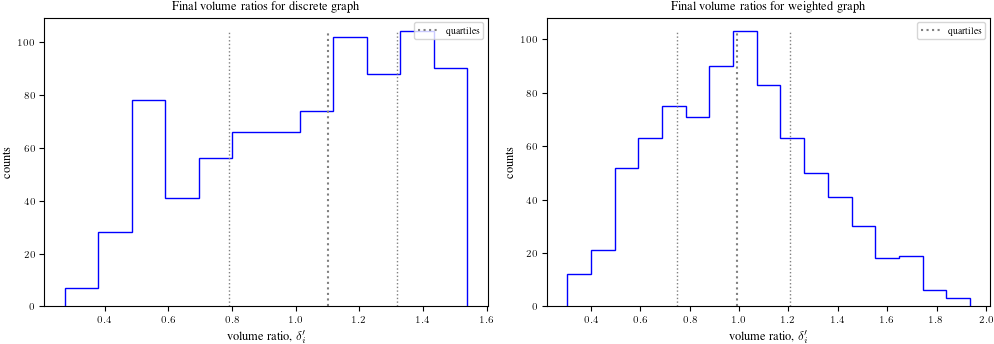

  seed 8: GW IAN sim=0.6729  (gw=0.0444, gw_max=0.1359)
  seed 8 done — cache updated.
  seed 9: computing IAN/MDS for baseline and clustered...


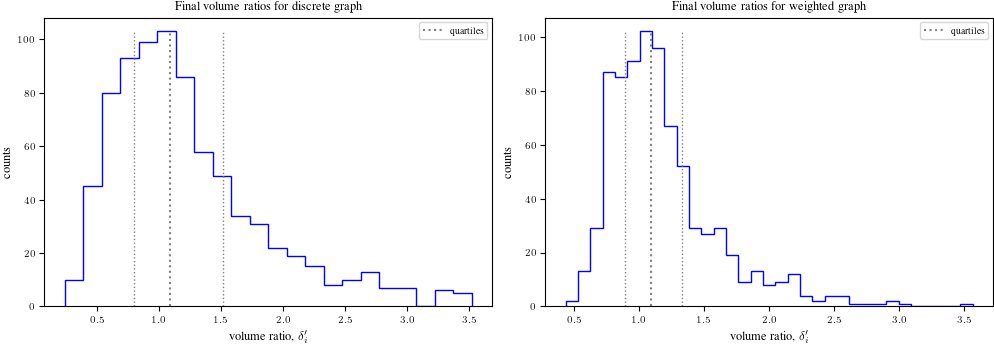

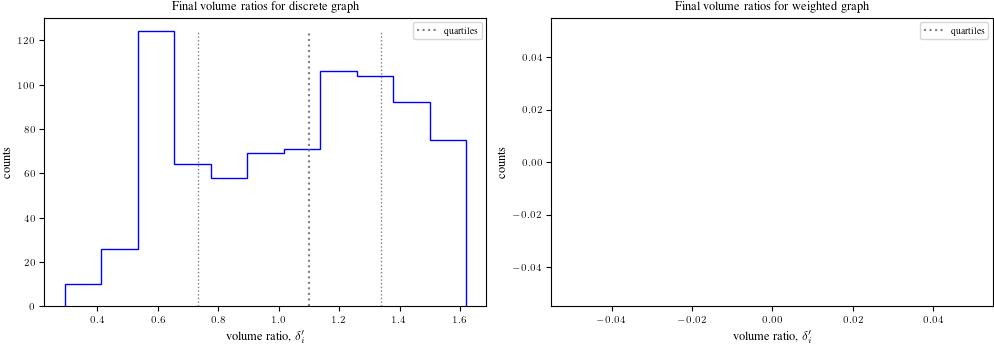

  seed 9: GW IAN sim=0.3669  (gw=0.0877, gw_max=0.1385)
  seed 9 done — cache updated.
  seed 10: computing IAN/MDS for baseline and clustered...


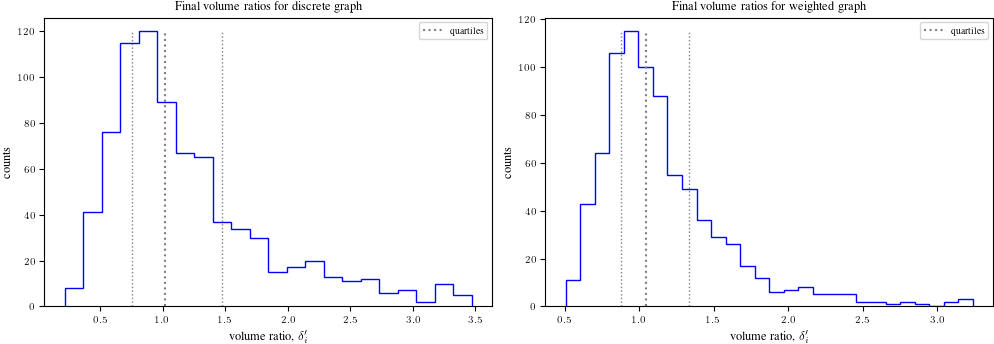

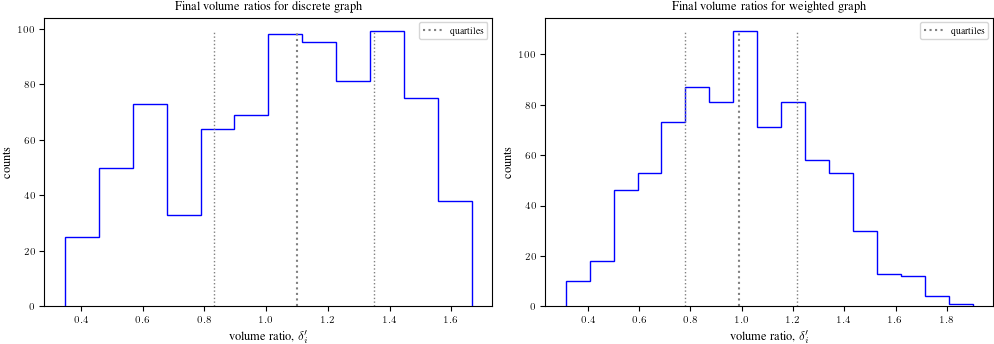

  seed 10: GW IAN sim=0.5146  (gw=0.0640, gw_max=0.1318)
  seed 10 done — cache updated.
  seed 11: computing IAN/MDS for baseline and clustered...


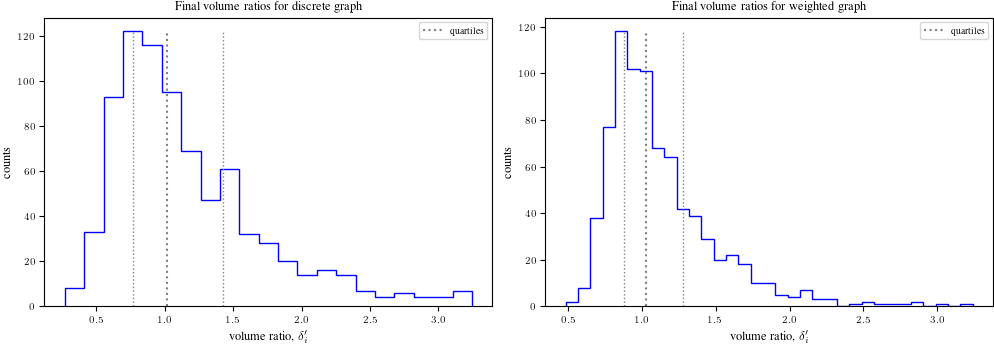

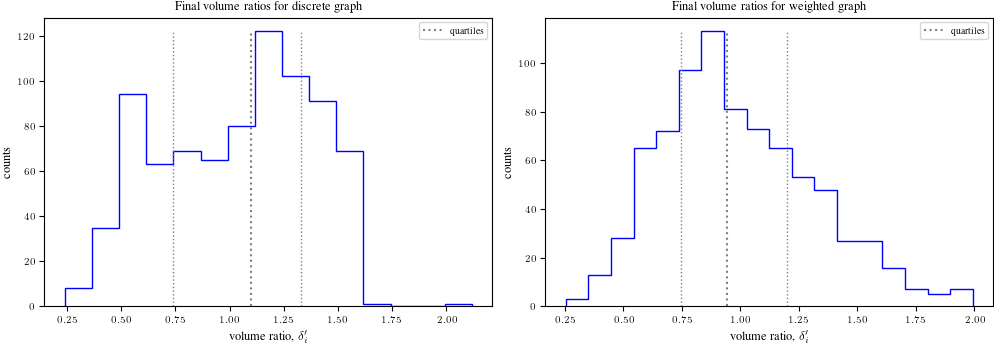

  seed 11: GW IAN sim=0.3613  (gw=0.0879, gw_max=0.1376)
  seed 11 done — cache updated.
  seed 12: computing IAN/MDS for baseline and clustered...


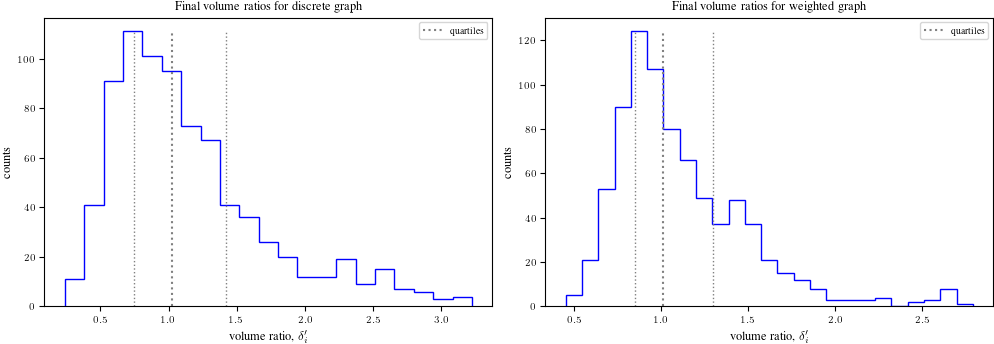

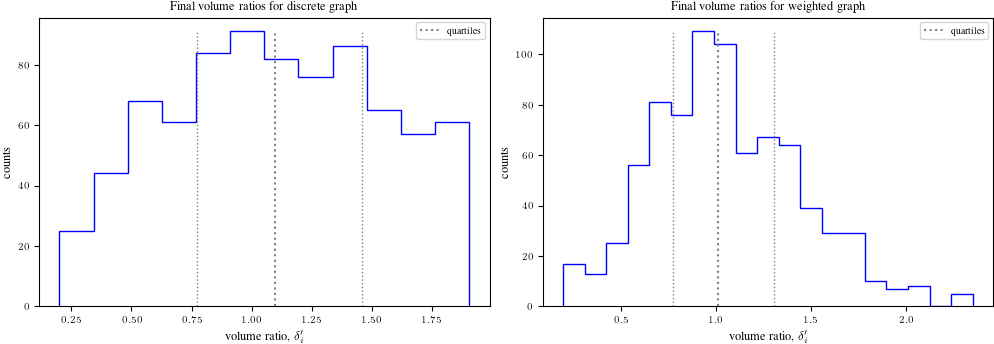

  seed 12: GW IAN sim=0.6142  (gw=0.0509, gw_max=0.1319)
  seed 12 done — cache updated.
  seed 13: computing IAN/MDS for baseline and clustered...


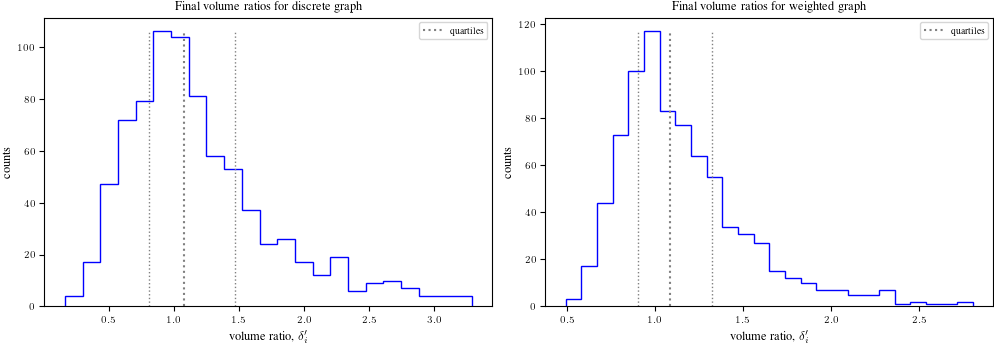

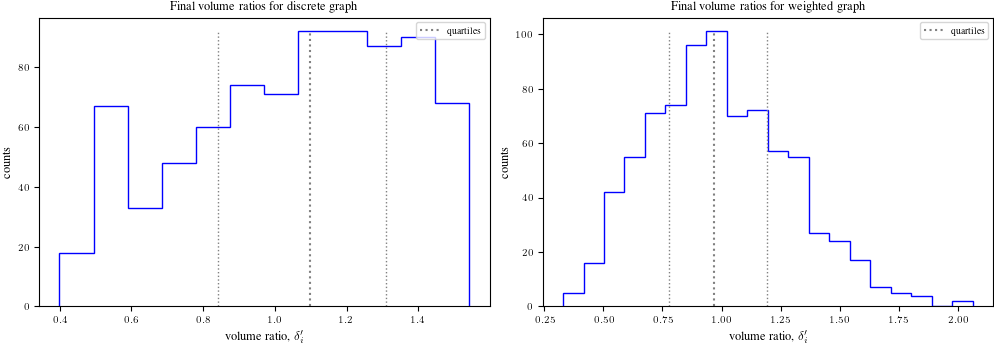

  seed 13: GW IAN sim=0.6235  (gw=0.0505, gw_max=0.1341)
  seed 13 done — cache updated.
  seed 14: computing IAN/MDS for baseline and clustered...


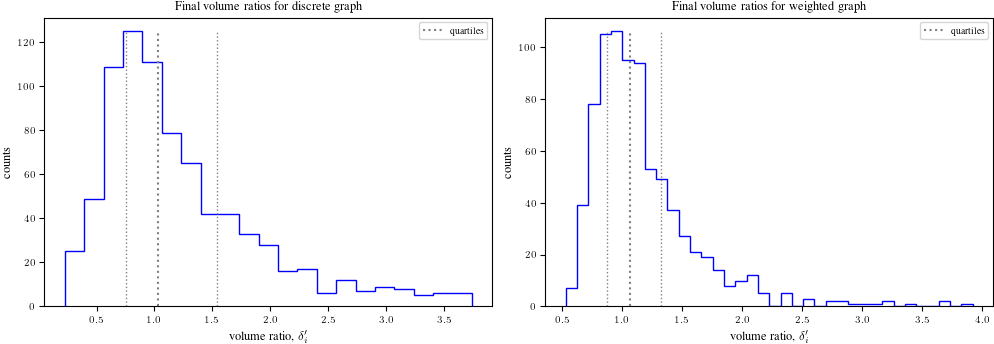

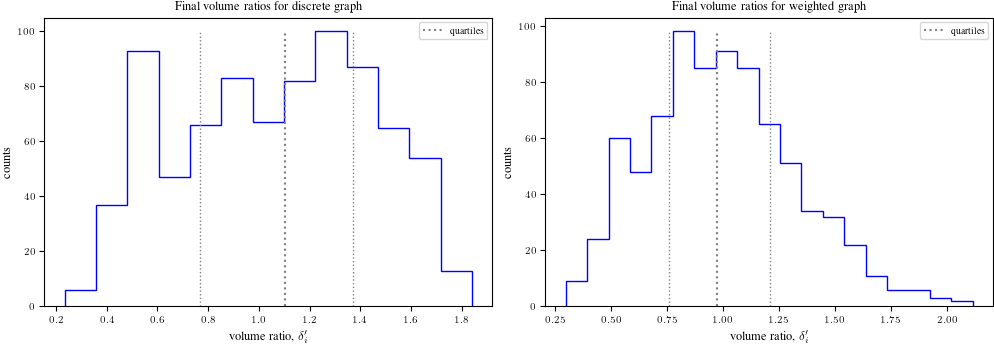

  seed 14: GW IAN sim=0.5984  (gw=0.0593, gw_max=0.1476)
  seed 14 done — cache updated.
  seed 15: computing IAN/MDS for baseline and clustered...


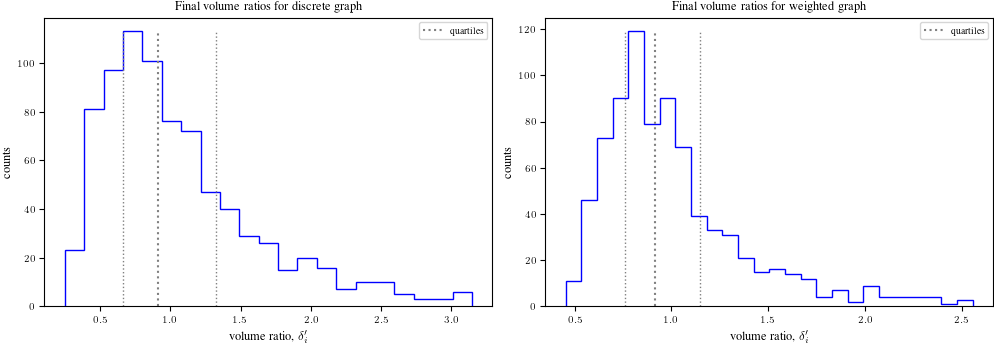

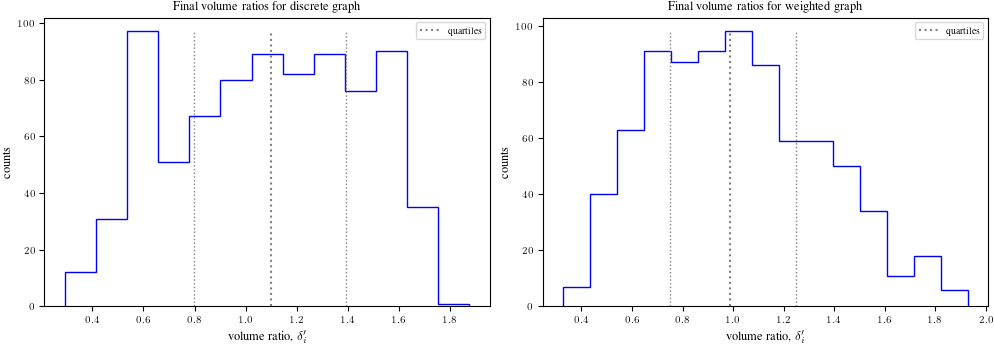

  seed 15: GW IAN sim=0.5307  (gw=0.0549, gw_max=0.1171)
  seed 15 done — cache updated.
  seed 16: computing IAN/MDS for baseline and clustered...


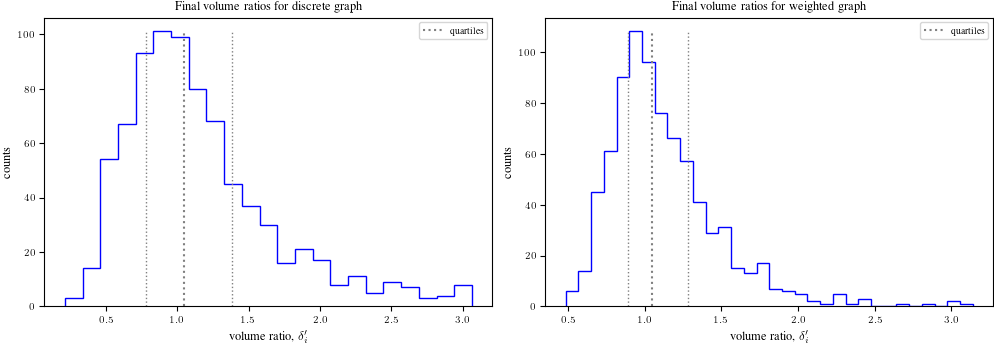

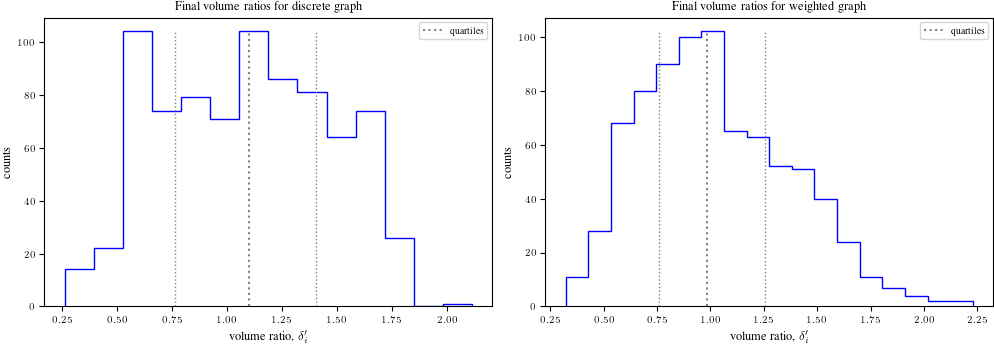

  seed 16: GW IAN sim=0.5750  (gw=0.0563, gw_max=0.1326)
  seed 16 done — cache updated.
  seed 17: computing IAN/MDS for baseline and clustered...


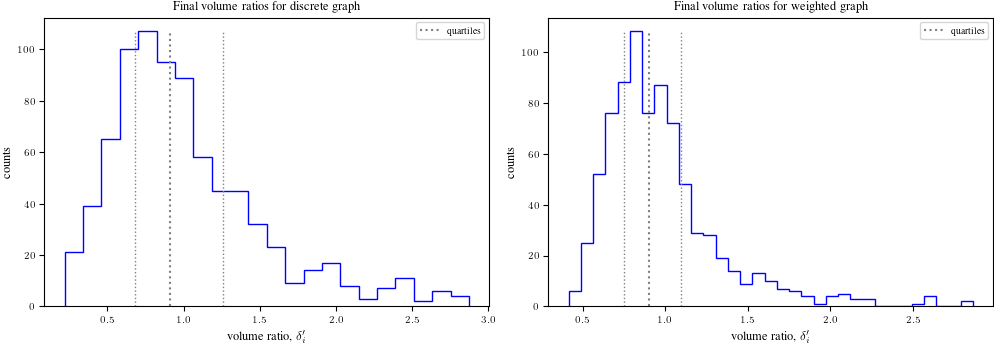

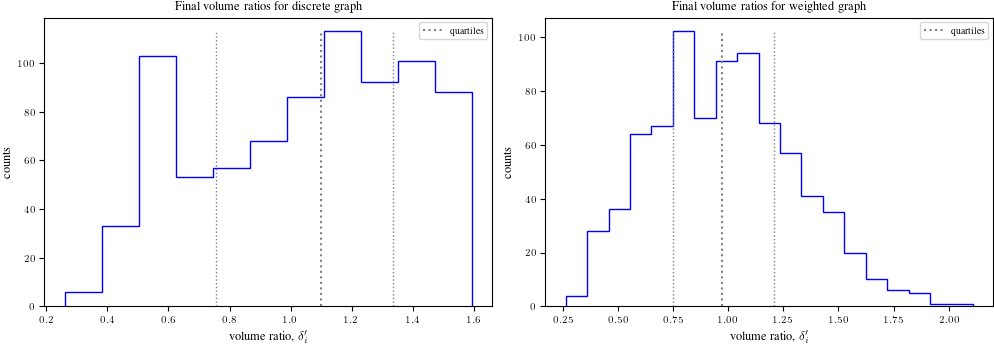

  seed 17: GW IAN sim=0.4587  (gw=0.0683, gw_max=0.1262)
  seed 17 done — cache updated.
  seed 18: computing IAN/MDS for baseline and clustered...


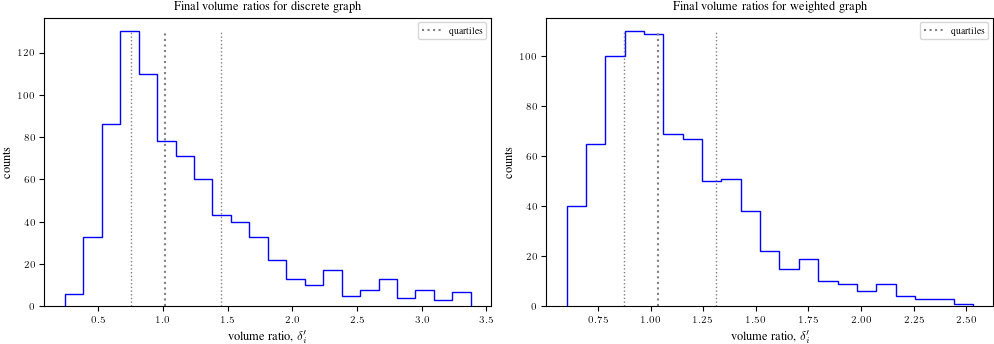

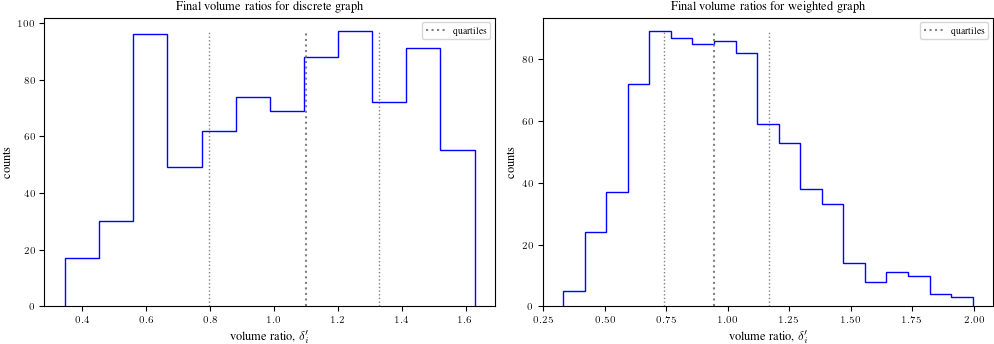

  seed 18: GW IAN sim=0.4452  (gw=0.0723, gw_max=0.1303)
  seed 18 done — cache updated.
  seed 19: computing IAN/MDS for baseline and clustered...


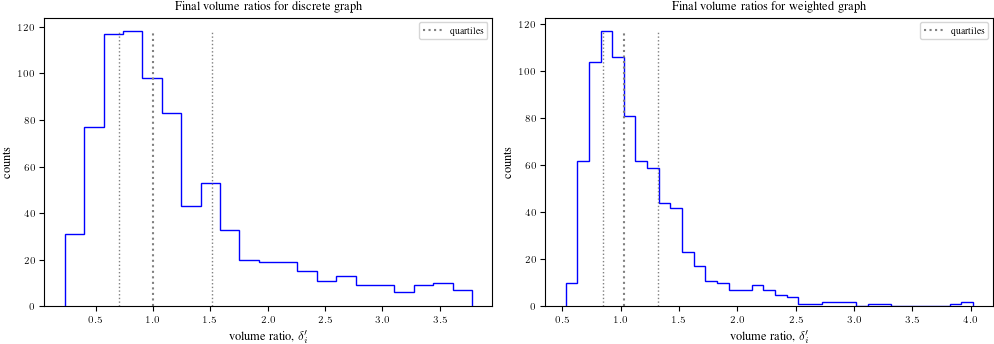

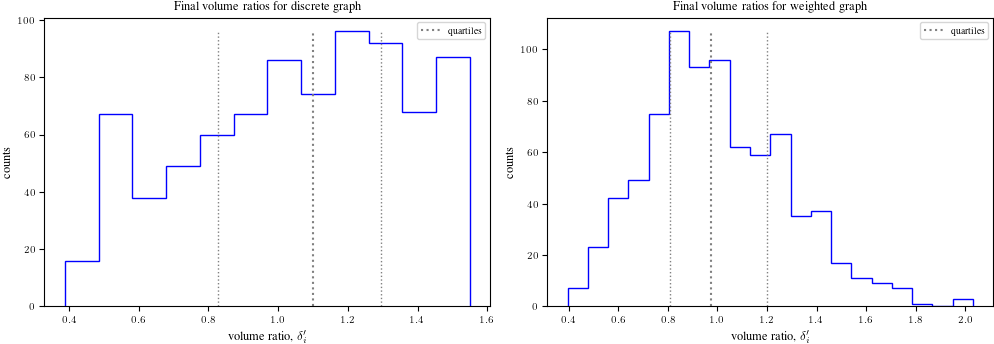

  seed 19: GW IAN sim=0.4857  (gw=0.0772, gw_max=0.1500)
  seed 19 done — cache updated.
All seeds done.

Table 1 results summary:
  seeds: 20  |  GW IAN values: 20
  GW IAN: mean=0.5016  SEM=0.0218
Computing within-baseline alignment (190 seed pairs)...
  building baseline seed 0...


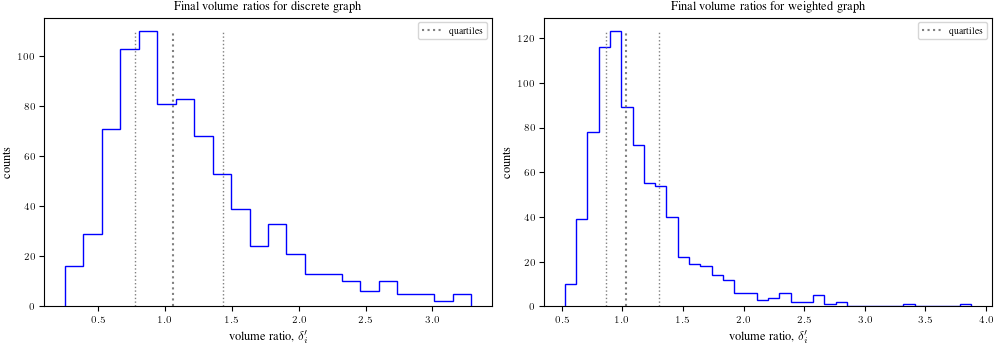

  building baseline seed 1...


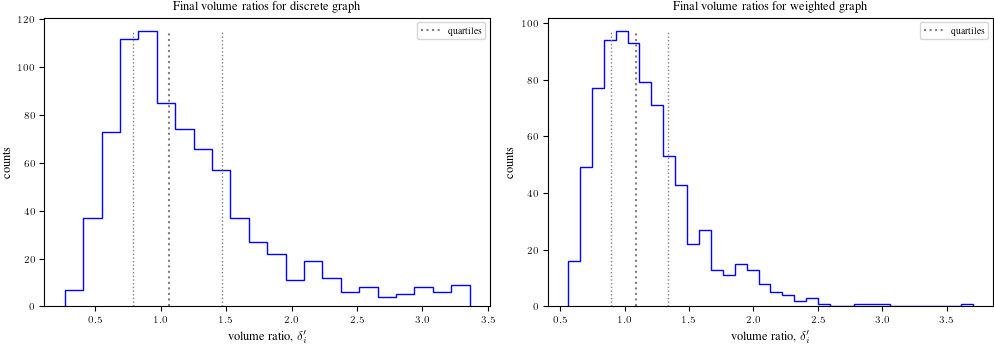

  building baseline seed 2...


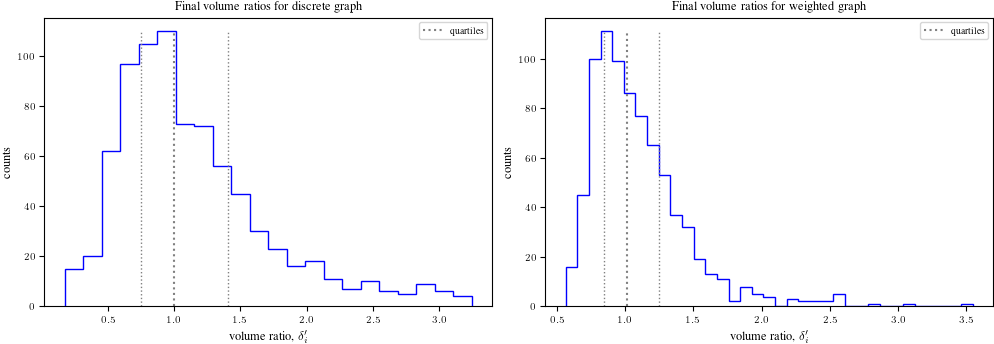

  building baseline seed 3...


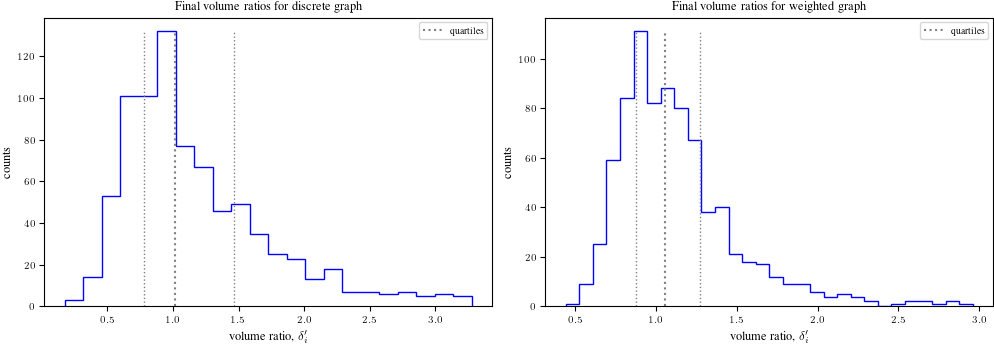

  building baseline seed 4...


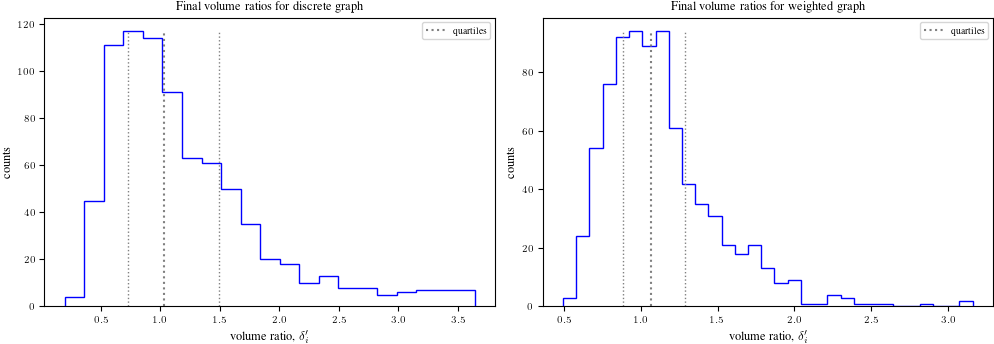

  building baseline seed 5...


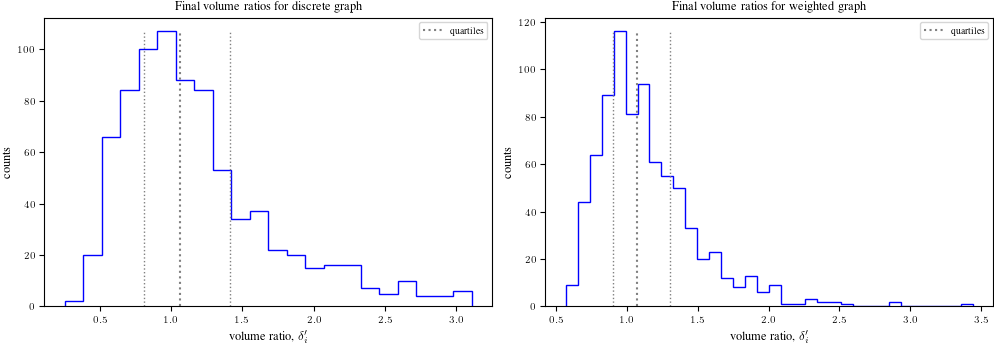

  building baseline seed 6...


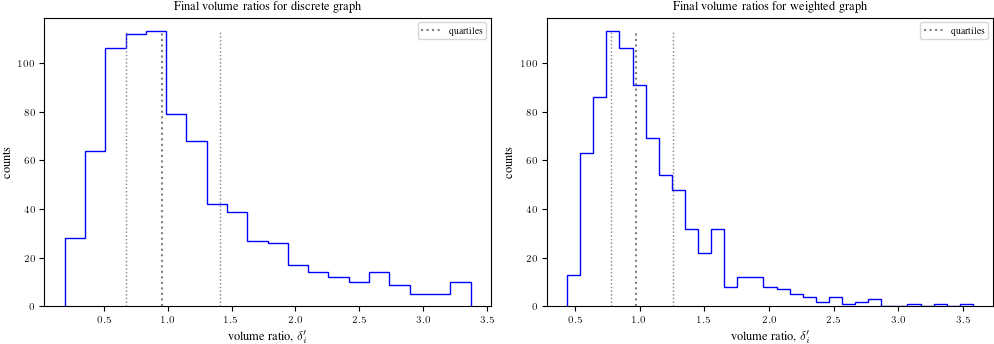

  building baseline seed 7...


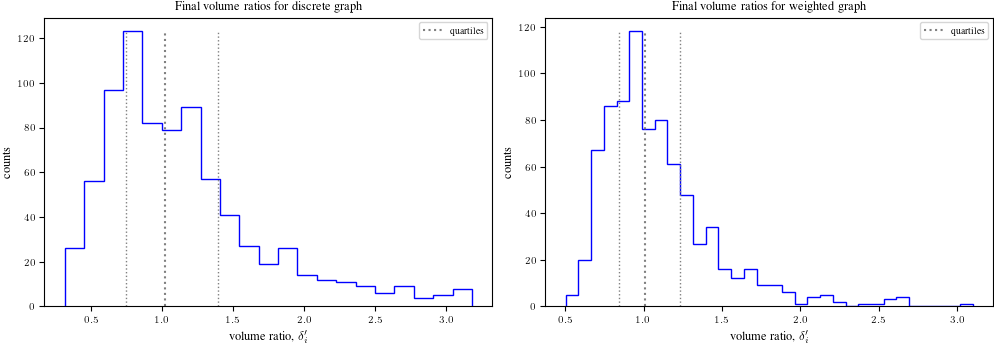

  building baseline seed 8...


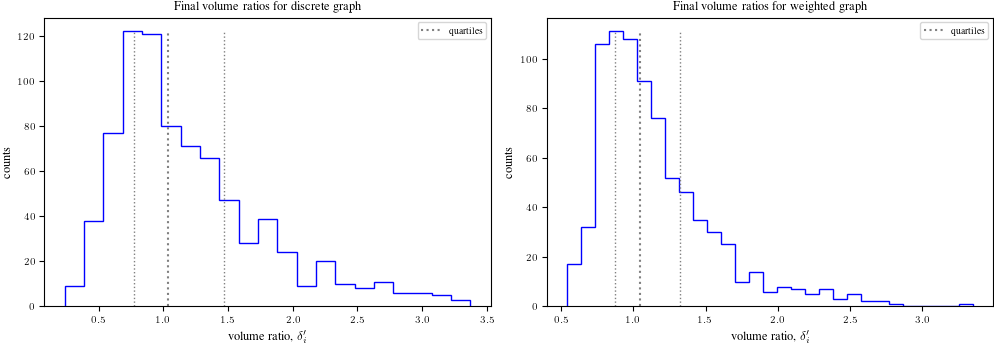

  building baseline seed 9...


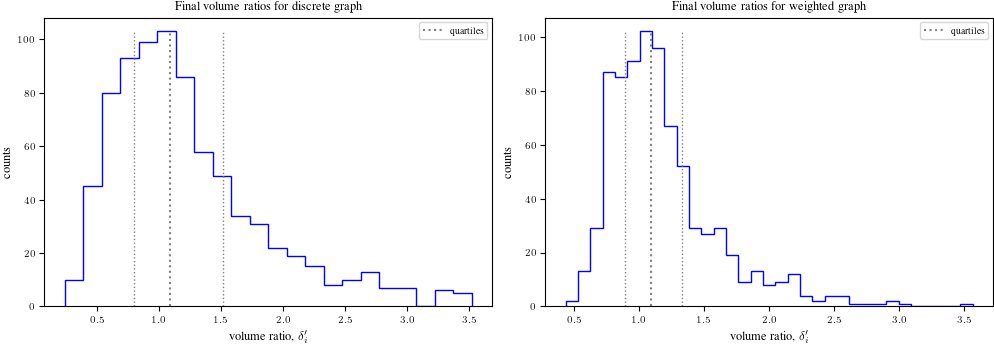

  building baseline seed 10...


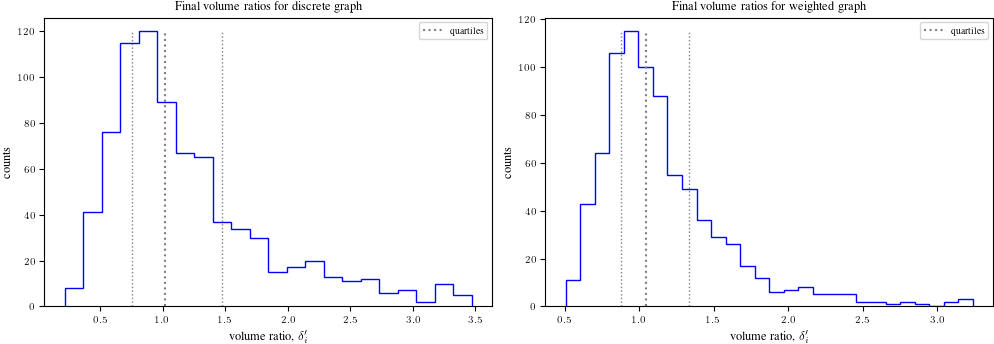

  building baseline seed 11...


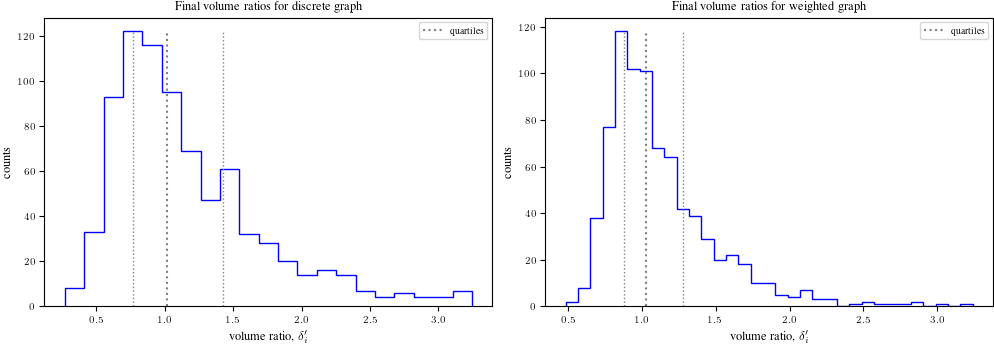

  building baseline seed 12...


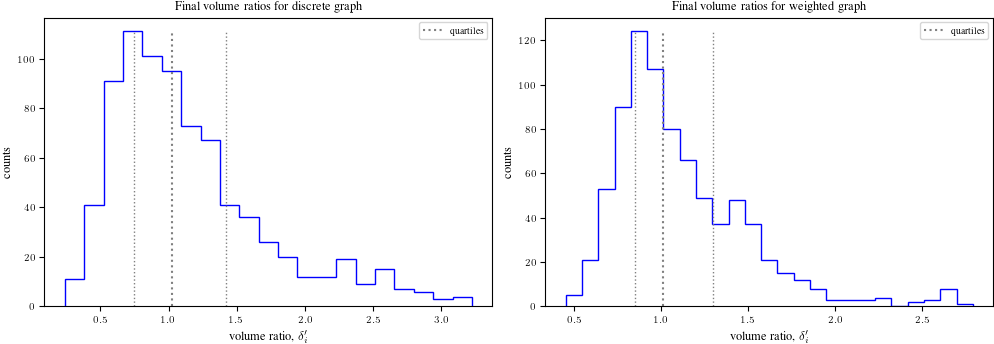

  building baseline seed 13...


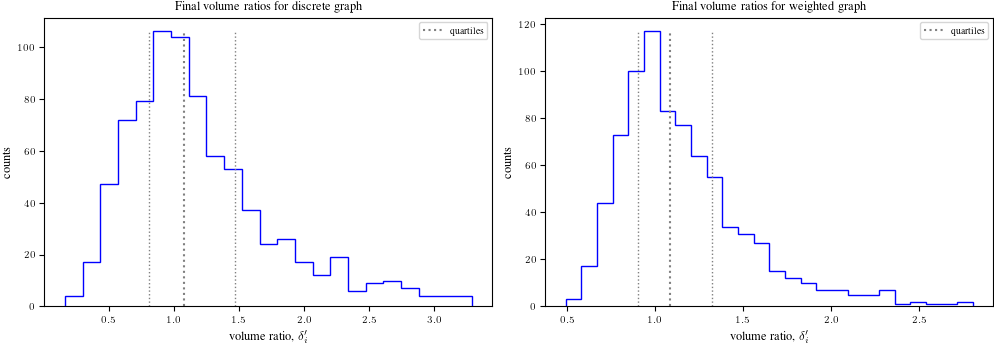

  building baseline seed 14...


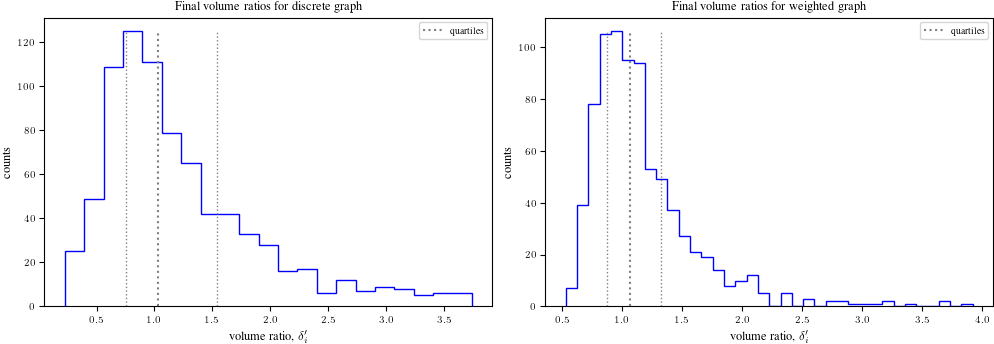

  building baseline seed 15...


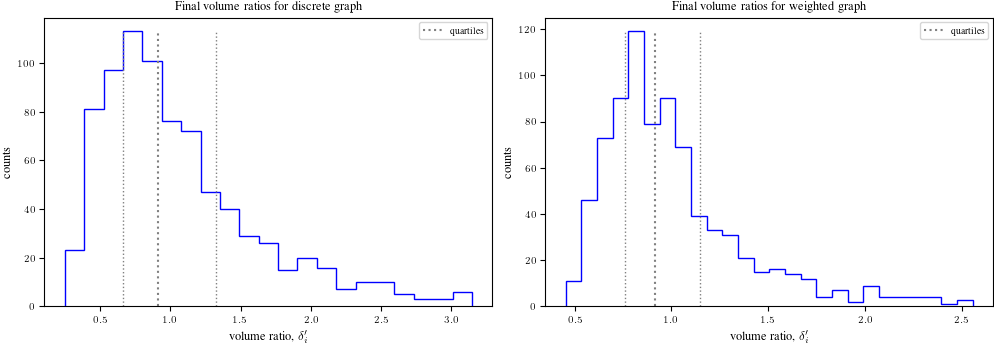

  building baseline seed 16...


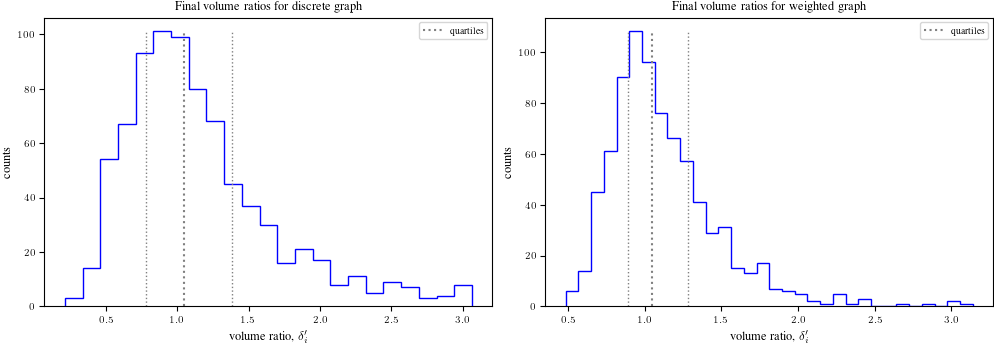

  building baseline seed 17...


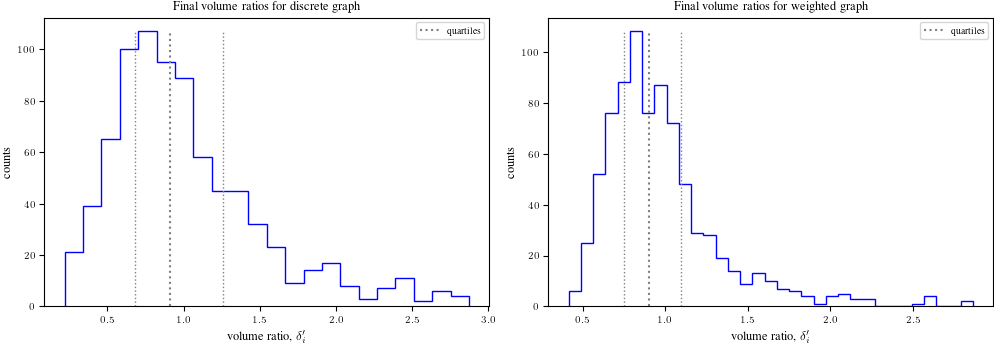

  building baseline seed 18...


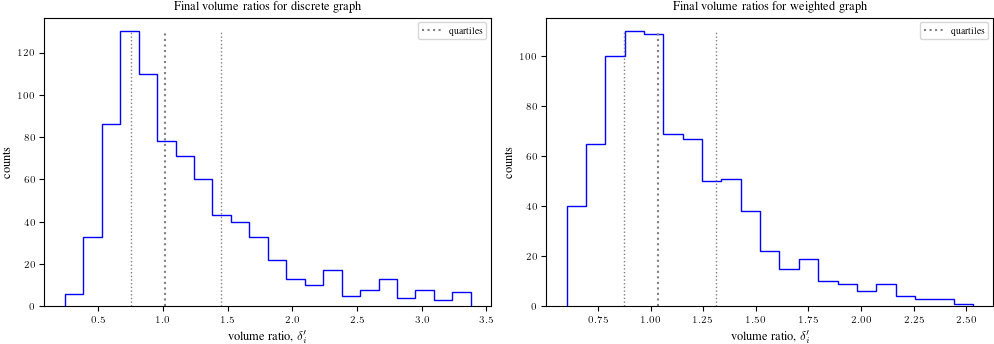

  building baseline seed 19...


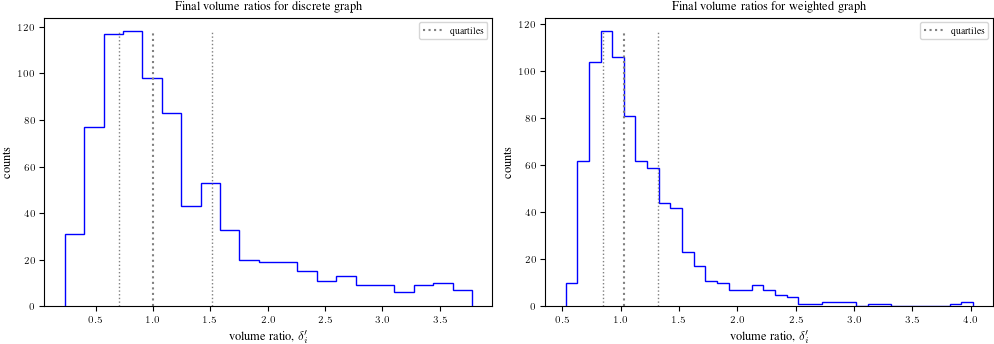

    seeds (0,1): rsa=0.912  cka=0.954  proc=0.827  gw=0.970
    seeds (0,2): rsa=0.931  cka=0.968  proc=0.922  gw=0.948
    seeds (0,3): rsa=0.965  cka=0.981  proc=0.970  gw=0.961
    seeds (0,4): rsa=0.933  cka=0.970  proc=0.952  gw=0.962
    seeds (0,5): rsa=0.958  cka=0.975  proc=0.944  gw=0.970
    seeds (0,6): rsa=0.938  cka=0.964  proc=0.934  gw=0.958
    seeds (0,7): rsa=0.955  cka=0.977  proc=0.975  gw=0.963
    seeds (0,8): rsa=0.911  cka=0.956  proc=0.927  gw=0.963
    seeds (0,9): rsa=0.897  cka=0.952  proc=0.916  gw=0.965
    seeds (0,10): rsa=0.968  cka=0.982  proc=0.971  gw=0.940
    seeds (0,11): rsa=0.912  cka=0.957  proc=0.935  gw=0.968
    seeds (0,12): rsa=0.936  cka=0.970  proc=0.939  gw=0.950
    seeds (0,13): rsa=0.932  cka=0.961  proc=0.930  gw=0.963
    seeds (0,14): rsa=0.928  cka=0.965  proc=0.832  gw=0.944
    seeds (0,15): rsa=0.903  cka=0.950  proc=0.902  gw=0.939
    seeds (0,16): rsa=0.949  cka=0.970  proc=0.949  gw=0.966
    seeds (0,17): rsa=0.946  cka=

In [22]:
import pandas as pd
from scipy.spatial import procrustes as _proc_t1
from scipy.spatial.distance import pdist as _pdist_t1, squareform as _squareform_t1
from scipy.sparse import csr_matrix as _csr_t1
from src.mnist_utils import encoding_gw_distance as _enc_gw
from src.tensor_utils import process_tensor_data as _ptd_t1, getPermutedTensor as _gpt_t1, getNeuralMatrix as _gnm_t1
from src.cp_utils import run_permuted_cp as _rcp_t1
from src.manifold_utils import compute_mds_embedding as _mds_emb_fn
from src.graph_utils import handle_disconnected_points as _hdp_t1
from ian.ian import IAN as _IAN_t1, getSparseMultiScaleK as _gsmk_t1
from ian.embed_utils import diffusionMapSparseK as _dm_t1

_T1_N_PER_CLASS = 50
_BLUR_LEVELS    = [0.0, 2.0, 3.0, 4.0, 5.0, 6.0]
_F_CP_T1        = 10   # CP rank  (matches notebook 21)
_NREPS_T1       = 5    # CP restarts (fast for Table 1)
_N_DIFF_T1      = 20   # diffusion-map components
_N_MDS_T1       = 5    # MDS components

# ── helper: full CP → IAN → diffmap → MDS encoding embedding ────────────────
def _build_ian_mds_t1(model, loader, device, rng_seed):
    """Compute IAN/diffmap/MDS encoding embedding for one model (matches nb21 pipeline)."""
    t4d_tmp, _ = build_tensor4d(model, loader, n_per_class=_T1_N_PER_CLASS, device=device)
    t4d_fmt = t4d_tmp.transpose(0, 1, 3, 2)   # (N, NSTIMS, 1, T) → (N, NSTIMS, T, 1)
    tensorX, _, _ = _ptd_t1(t4d_fmt, optSF=False, smooth_sig=0, method='relNorm')
    tensorX = np.nan_to_num(tensorX, nan=0.0, posinf=0.0, neginf=0.0)

    result = _rcp_t1(tensorX, F=_F_CP_T1, NDIRS=1, nreps=_NREPS_T1, max_iter=200, verbose=False)
    pf, pl = result['all_factors'][0], result['all_lambdas'][0]
    permT, _ = _gpt_t1(pf, pl, tensorX, NDIRS=1)
    scld  = permT / (permT.max() + 1e-12)
    X_cp, _ = _gnm_t1(scld, pf, pl, NDIRS=1, all_zeroed_stims=[], verbose=False)

    # Add small jitter to avoid ties in IAN (same as nb21)
    X_ian = X_cp + np.random.RandomState(rng_seed).normal(scale=1e-4, size=X_cp.shape)
    D2    = _squareform_t1(_pdist_t1(X_ian, 'sqeuclidean'))
    N     = D2.shape[0]

    _, wG, optScales, disc_pts = _IAN_t1('exact-precomputed-sq', D2, solver=None, verbose=0)
    outliers    = np.array([], dtype=int)
    nonoutliers = np.arange(N)
    G_bin = (wG.toarray() > 0).astype(float)
    if len(disc_pts) > 0:
        wG, G_bin, outliers, nonoutliers, _ = _hdp_t1(
            disc_pts, optScales, G_bin, D2, outliers,
            np.column_stack([np.arange(N), np.zeros(N)]),
            X_ian)
    else:
        wG = _gsmk_t1(D2, optScales)

    dm_y, _ = _dm_t1(_csr_t1(wG), _N_DIFF_T1, alpha=1, t=1)
    mds      = _mds_emb_fn(dm_y, _F_CP_T1, n_components=_N_MDS_T1)
    return mds

def _blur_acc_model(model, lv):
    from torchvision.transforms import functional as TF
    correct, total = 0, 0
    for xb, yb in _t1_test_loader:
        if lv > 0:
            ks = max(3, 2 * int(np.ceil(3 * lv)) + 1)
            xb = TF.gaussian_blur(xb, kernel_size=ks, sigma=float(lv))
        with torch.no_grad():
            preds = model(xb.to(_T1_DEVICE)).argmax(1).cpu()
        correct += (preds == yb).sum().item()
        total   += len(yb)
    return correct / total

# ── Load or compute all per-seed results ─────────────────────────────────────
_t1_cache_file = os.path.join(BASEDIR_CACHE, 'table1_mnist_results_v2.pkl')

if os.path.exists(_t1_cache_file):
    print('Loading Table 1 results from cache...')
    with open(_t1_cache_file, 'rb') as _f:
        _t1_results = pickle.load(_f)
    # Backward compat: add gw_ian key if missing (triggers recompute)
    _needs_gw = 'gw_ian' not in _t1_results or len(_t1_results['gw_ian']) < len(_T1_SEEDS)
    if _needs_gw:
        print('Cache missing gw_ian — will recompute GW IAN for all seeds.')
        _t1_results['gw_ian'] = []
    else:
        print('Done (all metrics including GW IAN cached).')
else:
    _t1_results = {lam: {'acc': [], 'knn': [], 'rsa': [], 'cka': [], 'proc_r2': [],
                         'blur': {lv: [] for lv in _BLUR_LEVELS}}
                   for lam in _T1_LAMBDAS}
    _t1_results['gw_ian'] = []   # per-seed GW sim (baseline vs clustered, IAN space)
    _needs_gw = True

# Determine how many seeds still need computing
_seeds_done  = len(_t1_results.get('gw_ian', [])) if not _needs_gw else 0
_full_done   = len(_t1_results.get(_T1_LAMBDAS[0], {}).get('acc', []))
_start_seed_idx = min(_seeds_done, _full_done)

if _start_seed_idx < len(_T1_SEEDS):
    print(f'Computing per-seed metrics starting from seed index {_start_seed_idx}...')
    for _si, seed in enumerate(_T1_SEEDS):
        if _si < _start_seed_idx:
            continue

        t4ds = {}
        for lam in _T1_LAMBDAS:
            m = _T1_MODELS[(lam, seed)]
            t4d, sl = build_tensor4d(m, _t1_test_loader, n_per_class=_T1_N_PER_CLASS, device=_T1_DEVICE)
            t4ds[lam] = (t4d, sl)
            _t1_results[lam]['acc'].append(test_accuracy(m, _t1_test_loader, device=_T1_DEVICE))

        t4d_b, sl_b = t4ds[0.0]
        coords_b, _ = compute_decoding_manifold(t4d_b, n_components=3)
        _t1_results[0.0]['knn'].append(knn_decoding_accuracy(coords_b, sl_b))

        t4d_c, sl_c = t4ds[10]
        coords_c, _ = compute_decoding_manifold(t4d_c, n_components=3)
        _t1_results[10]['knn'].append(knn_decoding_accuracy(coords_c, sl_c))
        _t1_results[10]['rsa'].append(rdm_correlation(t4d_b, t4d_c))
        _t1_results[10]['cka'].append(linear_cka(t4d_b, t4d_c))
        _, _, disp = _proc_t1(coords_b.copy(), coords_c.copy())
        _t1_results[10]['proc_r2'].append(1.0 - disp)

        for lam in _T1_LAMBDAS:
            for lv in _BLUR_LEVELS:
                _t1_results[lam]['blur'][lv].append(_blur_acc_model(_T1_MODELS[(lam, seed)], lv))

        # ── GW similarity (IAN): full CP → IAN → diffmap → MDS → GW (matches nb21) ──
        print(f'  seed {seed}: computing IAN/MDS for baseline and clustered...')
        _mds_bl = _build_ian_mds_t1(_T1_MODELS[(0.0, seed)], _t1_test_loader,
                                     _T1_DEVICE, rng_seed=seed)
        _mds_cl = _build_ian_mds_t1(_T1_MODELS[(10, seed)],  _t1_test_loader,
                                     _T1_DEVICE, rng_seed=seed + 100)
        # GW_max: baseline vs collapsed (all points at centroid) — normalises to [0,1]
        _mds_col = np.full_like(_mds_bl, _mds_bl.mean(0))
        _mds_col += np.random.RandomState(seed + 200).normal(scale=1e-8, size=_mds_col.shape)
        _gw_max  = _enc_gw(_mds_bl, _mds_col, n_subsample=len(_mds_bl), rng_seed=seed)
        _gw_val  = _enc_gw(_mds_bl, _mds_cl,
                           n_subsample=min(len(_mds_bl), len(_mds_cl)),
                           rng_seed=seed)
        _sim_ian = float(np.clip(1.0 - _gw_val / _gw_max, 0.0, 1.0))
        _t1_results['gw_ian'].append(_sim_ian)
        print(f'  seed {seed}: GW IAN sim={_sim_ian:.4f}  (gw={_gw_val:.4f}, gw_max={_gw_max:.4f})')

        # Save after every seed so interruptions don't lose work
        with open(_t1_cache_file, 'wb') as _f:
            pickle.dump(_t1_results, _f)
        print(f'  seed {seed} done — cache updated.')

    print('All seeds done.')
elif _needs_gw:
    # Main metrics cached but gw_ian missing — compute GW only
    print('Computing GW IAN for all seeds (other metrics already cached)...')
    _t1_results['gw_ian'] = []
    for seed in _T1_SEEDS:
        print(f'  seed {seed}: computing IAN/MDS...')
        _mds_bl = _build_ian_mds_t1(_T1_MODELS[(0.0, seed)], _t1_test_loader,
                                     _T1_DEVICE, rng_seed=seed)
        _mds_cl = _build_ian_mds_t1(_T1_MODELS[(10, seed)],  _t1_test_loader,
                                     _T1_DEVICE, rng_seed=seed + 100)
        _mds_col = np.full_like(_mds_bl, _mds_bl.mean(0))
        _mds_col += np.random.RandomState(seed + 200).normal(scale=1e-8, size=_mds_col.shape)
        _gw_max  = _enc_gw(_mds_bl, _mds_col, n_subsample=len(_mds_bl), rng_seed=seed)
        _gw_val  = _enc_gw(_mds_bl, _mds_cl,
                           n_subsample=min(len(_mds_bl), len(_mds_cl)),
                           rng_seed=seed)
        _sim_ian = float(np.clip(1.0 - _gw_val / _gw_max, 0.0, 1.0))
        _t1_results['gw_ian'].append(_sim_ian)
        print(f'  seed {seed}: GW IAN sim={_sim_ian:.4f}')
        with open(_t1_cache_file, 'wb') as _f:
            pickle.dump(_t1_results, _f)
    print('GW IAN done.')

print(f'\nTable 1 results summary:')
print(f'  seeds: {len(_T1_SEEDS)}  |  GW IAN values: {len(_t1_results["gw_ian"])}')
print(f'  GW IAN: mean={np.mean(_t1_results["gw_ian"]):.4f}  '
      f'SEM={np.std(_t1_results["gw_ian"])/np.sqrt(len(_t1_results["gw_ian"])):.4f}')

# ── Within-baseline alignment (all N*(N-1)/2 seed pairs) ─────────────────────
_N_WB_PAIRS = len(_T1_SEEDS) * (len(_T1_SEEDS) - 1) // 2
_WITHIN_BASE_KEYS = ['within_base_rsa', 'within_base_cka', 'within_base_proc_r2', 'within_base_gw_ian']
_needs_within = any(
    k not in _t1_results or len(_t1_results.get(k, [])) < _N_WB_PAIRS
    for k in _WITHIN_BASE_KEYS
)

if _needs_within:
    print(f'Computing within-baseline alignment ({_N_WB_PAIRS} seed pairs)...')
    _wb_t4ds, _wb_coords, _wb_mds, _wb_gw_max = {}, {}, {}, {}
    for seed in _T1_SEEDS:
        print(f'  building baseline seed {seed}...')
        m = _T1_MODELS[(0.0, seed)]
        _t4d_tmp, _ = build_tensor4d(m, _t1_test_loader, n_per_class=_T1_N_PER_CLASS, device=_T1_DEVICE)
        _wb_t4ds[seed]      = _t4d_tmp
        _wb_coords[seed], _ = compute_decoding_manifold(_t4d_tmp, n_components=3)
        _wb_mds[seed]       = _build_ian_mds_t1(m, _t1_test_loader, _T1_DEVICE, rng_seed=seed)
        _mds_col = np.full_like(_wb_mds[seed], _wb_mds[seed].mean(0))
        _mds_col += np.random.RandomState(seed + 300).normal(scale=1e-8, size=_mds_col.shape)
        _wb_gw_max[seed] = _enc_gw(_wb_mds[seed], _mds_col, n_subsample=len(_wb_mds[seed]), rng_seed=seed + 300)

    _wb_rsa, _wb_cka, _wb_proc, _wb_gw = [], [], [], []
    for _wi, _s1 in enumerate(_T1_SEEDS):
        for _s2 in _T1_SEEDS[_wi + 1:]:
            _wb_rsa.append(rdm_correlation(_wb_t4ds[_s1], _wb_t4ds[_s2]))
            _wb_cka.append(linear_cka(_wb_t4ds[_s1], _wb_t4ds[_s2]))
            _, _, _wb_disp = _proc_t1(_wb_coords[_s1].copy(), _wb_coords[_s2].copy())
            _wb_proc.append(1.0 - _wb_disp)
            _gw_val_wb = _enc_gw(_wb_mds[_s1], _wb_mds[_s2],
                                 n_subsample=min(len(_wb_mds[_s1]), len(_wb_mds[_s2])),
                                 rng_seed=_s1 * 100 + _s2)
            _gw_max_avg = (_wb_gw_max[_s1] + _wb_gw_max[_s2]) / 2
            _wb_gw.append(float(np.clip(1.0 - _gw_val_wb / (_gw_max_avg + 1e-12), 0.0, 1.0)))
            print(f'    seeds ({_s1},{_s2}): rsa={_wb_rsa[-1]:.3f}  cka={_wb_cka[-1]:.3f}  '
                  f'proc={_wb_proc[-1]:.3f}  gw={_wb_gw[-1]:.3f}')

    _t1_results['within_base_rsa']     = _wb_rsa
    _t1_results['within_base_cka']     = _wb_cka
    _t1_results['within_base_proc_r2'] = _wb_proc
    _t1_results['within_base_gw_ian']  = _wb_gw
    with open(_t1_cache_file, 'wb') as _f:
        pickle.dump(_t1_results, _f)
    print(f'Within-baseline done: {len(_wb_rsa)} pairs saved to cache.')
else:
    print('Within-baseline alignment already cached.')

print(f'\nWithin-baseline summary:')
for _wb_k, _wb_nm in [('within_base_rsa', 'RSA'), ('within_base_cka', 'CKA'),
                      ('within_base_proc_r2', 'Proc R2'), ('within_base_gw_ian', 'GW IAN')]:
    _wb_v = _t1_results.get(_wb_k, [])
    if _wb_v:
        print(f'  {_wb_nm}: mean={np.mean(_wb_v):.4f}  SEM={np.std(_wb_v)/np.sqrt(len(_wb_v)):.4f}  n={len(_wb_v)}')


In [24]:
# ── Display Table 1 ─────────────────────────────────────────────────────────
import pandas as pd
import IPython.display as _ipd

def _fmt_mean_sem(vals):
    m = np.mean(vals); s = np.std(vals) / np.sqrt(len(vals))
    return f'{m:.3f} +/- {s:.3f}'

def _pval_fmt(p):
    if p < 0.001: return f'{p:.2e} ***'
    if p < 0.01:  return f'{p:.3f} **'
    if p < 0.05:  return f'{p:.3f} *'
    return f'{p:.3f} ns'

rows = []

# Accuracy (per condition)
for _lam in _T1_LAMBDAS:
    _lbl = _T1_LAM_STYLE[_lam]['label']
    rows.append({'Metric': f'Accuracy ({_lbl})', 
                 'Value (mean +/- SEM)': _fmt_mean_sem(_t1_results[_lam]['acc']),
                 'p-value': '-', 'Test': '-'})

# kNN (per condition)
for _lam in _T1_LAMBDAS:
    _lbl = _T1_LAM_STYLE[_lam]['label']
    rows.append({'Metric': f'kNN acc. ({_lbl})',
                 'Value (mean +/- SEM)': _fmt_mean_sem(_t1_results[_lam]['knn']),
                 'p-value': '-', 'Test': '-'})

# Cross-condition metrics (one-sample Wilcoxon: values vs 1.0)
for _metric, _name in [('rsa', 'RSA'), ('cka', 'CKA'), ('proc_r2', 'Procrustes R2')]:
    _vals_c = np.array(_t1_results[10][_metric], dtype=float)
    _, _p = _wc_t1(_vals_c - 1.0)
    rows.append({'Metric': f'{_name} (base vs clustered)',
                 'Value (mean +/- SEM)': _fmt_mean_sem(_vals_c),
                 'p-value': _pval_fmt(_p), 'Test': 'Wilcoxon vs 1.0'})

# GW similarity (IAN) — per-seed, computed in this notebook
_gw_ian_vals = _t1_results['gw_ian']
_, _p_gw_ian = _wc_t1(np.array(_gw_ian_vals, dtype=float) - 1.0)
rows.append({'Metric': 'GW similarity IAN (base vs clustered)',
             'Value (mean +/- SEM)': _fmt_mean_sem(_gw_ian_vals),
             'p-value': _pval_fmt(_p_gw_ian), 'Test': 'Wilcoxon vs 1.0'})

# Within-baseline alignment
rows.append({'Metric': '--- Within-Baseline Alignment (all seed pairs, n=45) ---',
             'Value (mean +/- SEM)': '', 'p-value': '', 'Test': ''})
for _wb_key, _wb_name in [('within_base_rsa', 'RSA'), ('within_base_cka', 'CKA'),
                           ('within_base_proc_r2', 'Procrustes R2')]:
    _wb_vals = _t1_results.get(_wb_key, [])
    if _wb_vals:
        _, _p_wb = _wc_t1(np.array(_wb_vals, dtype=float) - 1.0)
        rows.append({'Metric': f'{_wb_name} (within baseline)',
                     'Value (mean +/- SEM)': _fmt_mean_sem(_wb_vals),
                     'p-value': _pval_fmt(_p_wb), 'Test': f'Wilcoxon vs 1.0  (n={len(_wb_vals)} pairs)'})

_wb_gw_vals = _t1_results.get('within_base_gw_ian', [])
if _wb_gw_vals:
    _, _p_wb_gw = _wc_t1(np.array(_wb_gw_vals, dtype=float) - 1.0)
    rows.append({'Metric': 'GW similarity IAN (within baseline)',
                 'Value (mean +/- SEM)': _fmt_mean_sem(_wb_gw_vals),
                 'p-value': _pval_fmt(_p_wb_gw),
                 'Test': f'Wilcoxon vs 1.0  (n={len(_wb_gw_vals)} pairs)'})

# Gaussian blur
rows.append({'Metric': '--- Gaussian Blur Robustness ---', 'Value (mean +/- SEM)': '', 'p-value': '', 'Test': ''})
for _blur_lv in [0.0, 2.0, 3.0, 4.0, 5.0, 6.0]:
    _base_v = _t1_results[0.0]['blur'][_blur_lv]
    _clust_v = _t1_results[10]['blur'][_blur_lv]
    _, _p = _wc_t1(_base_v, _clust_v)
    rows.append({'Metric': f'  Blur sigma={_blur_lv:.0f} | Baseline vs Clustered',
                 'Value (mean +/- SEM)': f'{_fmt_mean_sem(_base_v)} | {_fmt_mean_sem(_clust_v)}',
                 'p-value': _pval_fmt(_p), 'Test': 'Wilcoxon paired'})

_df_t1 = pd.DataFrame(rows)
display(_df_t1)
print('Table 1 (MNIST decoding + blur) displayed above.')


,Metric,Value (mean +/- SEM),p-value,Test
0,Accuracy (Baseline),0.986 +/- 0.000,-,-
1,Accuracy (Clustered (lam=10)),0.983 +/- 0.000,-,-
2,kNN acc. (Baseline),0.611 +/- 0.004,-,-
3,kNN acc. (Clustered (lam=10)),0.649 +/- 0.005,-,-
4,RSA (base vs clustered),0.961 +/- 0.002,1.72e-06 ***,Wilcoxon vs 1.0
5,CKA (base vs clustered),0.976 +/- 0.001,1.72e-06 ***,Wilcoxon vs 1.0
6,Procrustes R2 (base vs clustered),0.941 +/- 0.008,1.86e-09 ***,Wilcoxon vs 1.0
7,GW similarity IAN (base vs clustered),0.502 +/- 0.022,1.91e-06 ***,Wilcoxon vs 1.0
8,"--- Within-Baseline Alignment (all seed pairs,...",,,
9,RSA (within baseline),0.958 +/- 0.001,6.26e-33 ***,Wilcoxon vs 1.0 (n=190 pairs)


Table 1 (MNIST decoding + blur) displayed above.


### Table 1 (cont.) — Graph Connectivity Metrics (from Notebook 23)

6-panel figure comparing baseline vs constrained (lambda=50) across IAN homophily,
functional connectivity block score, ablation AUC, attribution entropy/overlap, and weight assortativity.

In [25]:
# ── Graph Connectivity Analysis: Attr Entropy, Attr Overlap, Assortativity ───
# Baseline (lam=0.0) and constrained (lam=50.0), 10 seeds each.
# Re-uses _t1_test_loader and _T1_CKPT_DIR from Table 1 setup.
import networkx as nx
from src.mnist_utils import load_cnn_checkpoint, CNN, compute_tuning_vecs
from tqdm import tqdm
from scipy import stats

_N23_SEEDS  = list(range(20))
_N23_EPOCHS = 5
_N23_LAM    = 10
_N23_DEVICE = _T1_DEVICE
_N23_IAN_DIR = os.path.join(BASEDIR, 'data', 'mnist_manifold', 'ian_cache')

def _bar_panel(ax, bvals, cvals, title, p_val, zoom_pad=0.15):
    bclean = [v for v in bvals if not np.isnan(v)]
    cclean = [v for v in cvals if not np.isnan(v)]
    means = [np.mean(bclean), np.mean(cclean)]
    stds  = [np.std(bclean),  np.std(cclean)]
    ax.bar([0, 1], means, color=['#4C72B0', '#DD8452'], alpha=0.75, width=0.5)
    ax.errorbar([0, 1], means, yerr=stds, fmt='none', color='k', capsize=5, lw=1.5)
    for xi, vl in zip([0, 1], [bclean, cclean]):
        ax.scatter([xi] * len(vl), vl, color='k', s=22, zorder=4, alpha=0.65)
    rng = max(bclean + cclean) - min(bclean + cclean) + 1e-8
    lo = min(bclean + cclean) - zoom_pad * rng
    hi = max(bclean + cclean) + zoom_pad * rng
    lo = min(lo, min(means[i] - stds[i] for i in range(2))) - 0.005
    hi = max(hi, max(means[i] + stds[i] for i in range(2))) + 0.005
    ax.set_ylim(lo, hi)
    p_str = f'{p_val:.3f}' if p_val >= 0.001 else f'{p_val:.1e}'
    ax.set_title(f'{title}\np = {p_str}', fontsize=9, pad=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Baseline', 'Constrained'], fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

# ── Load lam=10 models ────────────────────────────────────────────────────────
print('Loading lam=10 constrained models...')
_n23_base_models, _n23_const_models = [], []
for s in _N23_SEEDS:
    _n23_base_models.append(load_cnn_checkpoint(
        os.path.join(_T1_CKPT_DIR, f'cnn_baseline_lam0.0_e{_N23_EPOCHS}_s{s}.pt')))
    _n23_const_models.append(load_cnn_checkpoint(
        os.path.join(_T1_CKPT_DIR, f'cnn_cluster_pref_stim_lam{_N23_LAM}_e{_N23_EPOCHS}_s{s}.pt')))
print(f'Loaded {len(_n23_base_models)} baseline + {len(_n23_const_models)} constrained (lam=50)')

# ── Tuning vecs & channel pref (for assortativity) ───────────────────────────
_tmp_cnn = CNN()
_channel_map = _tmp_cnn.channel_map  # (800,)

def _tv_pref(model):
    tv = compute_tuning_vecs(model, _t1_test_loader, device=_N23_DEVICE)
    return tv.argmax(axis=1)  # (800,)

def _ch_pref(neuron_pref, n_channels=32):
    cp = np.zeros(n_channels, dtype=int)
    for ch in range(n_channels):
        votes = neuron_pref[_channel_map == ch]
        cp[ch] = np.bincount(votes, minlength=10).argmax()
    return cp

_n23_base_pref  = [_tv_pref(m) for m in tqdm(_n23_base_models,  desc='base pref')]
_n23_const_pref = [_tv_pref(m) for m in tqdm(_n23_const_models, desc='const pref')]
_n23_base_ch_pref  = [_ch_pref(p) for p in _n23_base_pref]
_n23_const_ch_pref = [_ch_pref(p) for p in _n23_const_pref]

# ── Hidden layer attribution entropy & overlap (A4) ──────────────────────────
def _h2_attr(model, n_per_class=200):
    model.eval()
    attr_sum, attr_count = np.zeros((10, 800)), np.zeros(10, dtype=int)
    for xb, yb in _t1_test_loader:
        if attr_count.min() >= n_per_class:
            break
        h2   = model._h2(xb)
        h2_d = h2.detach().requires_grad_(True)
        logits = model.fc(h2_d)
        for c in range(10):
            if attr_count[c] >= n_per_class:
                continue
            correct = (yb == c) & (logits.argmax(1).detach() == c)
            if not correct.any():
                continue
            if h2_d.grad is not None:
                h2_d.grad.zero_()
            logits[correct, c].sum().backward(retain_graph=True)
            attr = (h2_d.grad[correct].abs() * h2[correct].detach()).detach().numpy()
            n_add = min(len(attr), n_per_class - attr_count[c])
            attr_sum[c] += attr[:n_add].sum(0)
            attr_count[c] += n_add
    return attr_sum / np.maximum(attr_count[:, None], 1)

def _entropy(am):
    return np.mean([-np.sum((p := np.abs(am[c]) / (np.abs(am[c]).sum() + 1e-8)) * np.log(p + 1e-12))
                    for c in range(10)])

def _overlap(am):
    A = am / (np.linalg.norm(am, axis=1, keepdims=True) + 1e-8)
    return (A @ A.T)[np.triu_indices(10, k=1)].mean()

_n23_base_h_ent, _n23_base_h_over   = [], []
_n23_const_h_ent, _n23_const_h_over = [], []
for m in tqdm(_n23_base_models,  desc='base H2 attr'):
    am = _h2_attr(m); _n23_base_h_ent.append(_entropy(am)); _n23_base_h_over.append(_overlap(am))
for m in tqdm(_n23_const_models, desc='const H2 attr'):
    am = _h2_attr(m); _n23_const_h_ent.append(_entropy(am)); _n23_const_h_over.append(_overlap(am))
_, _p_h_ent  = stats.ranksums(_n23_base_h_ent,  _n23_const_h_ent)
_, _p_h_over = stats.ranksums(_n23_base_h_over, _n23_const_h_over)

# ── FC weight-graph assortativity (A6) ───────────────────────────────────────
def _fc_assort(model, pref, threshold=0.5):
    W = model.fc.weight.detach().numpy()
    Wn = W / (np.linalg.norm(W, axis=0, keepdims=True) + 1e-8)
    cos = Wn.T @ Wn
    G = nx.Graph()
    for i in range(800):
        G.add_node(i, cls=int(pref[i]))
    for u, v in zip(*np.where(np.triu(cos > threshold, k=1))):
        G.add_edge(int(u), int(v))
    return np.nan if G.number_of_edges() == 0 else nx.attribute_assortativity_coefficient(G, 'cls')

_n23_base_fc_assort  = [_fc_assort(m, p) for m, p in zip(_n23_base_models,  _n23_base_pref)]
_n23_const_fc_assort = [_fc_assort(m, p) for m, p in zip(_n23_const_models, _n23_const_pref)]
_, _p_fc_assort = stats.ranksums(_n23_const_fc_assort, _n23_base_fc_assort)

# ── Conv2 channel attribution entropy & overlap (A7) ─────────────────────────
def _conv2_attr(model, n_per_class=300):
    model.eval()
    attr_sum, attr_count = np.zeros((10, 32)), np.zeros(10, dtype=int)
    for xb, yb in _t1_test_loader:
        if attr_count.min() >= n_per_class:
            break
        c1 = model.pool(torch.relu(model.conv1(xb)))
        c2_pre = model.conv2(c1)
        c2_pre_d = c2_pre.detach().requires_grad_(True)
        c2 = model.pool(torch.relu(c2_pre_d))
        logits = model.fc(c2.view(c2.size(0), -1))
        for c in range(10):
            if attr_count[c] >= n_per_class:
                continue
            correct = (yb == c) & (logits.argmax(1).detach() == c)
            if not correct.any():
                continue
            if c2_pre_d.grad is not None:
                c2_pre_d.grad.zero_()
            logits[correct, c].sum().backward(retain_graph=True)
            grad_gap = c2_pre_d.grad[correct].abs().mean(dim=(-2, -1)).detach().numpy()
            act_gap  = torch.relu(c2_pre_d[correct]).mean(dim=(-2, -1)).detach().numpy()
            attr = grad_gap * act_gap
            n_add = min(len(attr), n_per_class - attr_count[c])
            attr_sum[c] += attr[:n_add].sum(0)
            attr_count[c] += n_add
    return attr_sum / np.maximum(attr_count[:, None], 1)

_n23_base_c_ent, _n23_base_c_over   = [], []
_n23_const_c_ent, _n23_const_c_over = [], []
for m in tqdm(_n23_base_models,  desc='base Conv2 attr'):
    am = _conv2_attr(m); _n23_base_c_ent.append(_entropy(am)); _n23_base_c_over.append(_overlap(am))
for m in tqdm(_n23_const_models, desc='const Conv2 attr'):
    am = _conv2_attr(m); _n23_const_c_ent.append(_entropy(am)); _n23_const_c_over.append(_overlap(am))
_, _p_c_ent  = stats.ranksums(_n23_base_c_ent,  _n23_const_c_ent)
_, _p_c_over = stats.ranksums(_n23_base_c_over, _n23_const_c_over)

# ── Conv2 filter assortativity (A8) ──────────────────────────────────────────
def _conv2_assort(model, ch_pref, threshold=0.3):
    W = model.conv2.weight.detach().numpy().reshape(32, -1)
    Wn = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-8)
    cos = Wn @ Wn.T
    G = nx.Graph()
    for i in range(32):
        G.add_node(i, cls=int(ch_pref[i]))
    for u, v in zip(*np.where(np.triu(cos > threshold, k=1))):
        G.add_edge(int(u), int(v))
    return np.nan if G.number_of_edges() == 0 else nx.attribute_assortativity_coefficient(G, 'cls')

_n23_base_c_assort  = [_conv2_assort(m, cp) for m, cp in zip(_n23_base_models,  _n23_base_ch_pref)]
_n23_const_c_assort = [_conv2_assort(m, cp) for m, cp in zip(_n23_const_models, _n23_const_ch_pref)]
_, _p_c_assort = stats.ranksums(_n23_const_c_assort, _n23_base_c_assort)

# ── 6-panel summary figure ────────────────────────────────────────────────────
_n23_specs = [
    ('H2 Attr. Entropy',      _n23_base_h_ent,     _n23_const_h_ent,     _p_h_ent),
    ('H2 Attr. Overlap',      _n23_base_h_over,    _n23_const_h_over,    _p_h_over),
    ('FC Assortativity',      _n23_base_fc_assort, _n23_const_fc_assort, _p_fc_assort),
    ('Conv2 Attr. Entropy',   _n23_base_c_ent,     _n23_const_c_ent,     _p_c_ent),
    ('Conv2 Attr. Overlap',   _n23_base_c_over,    _n23_const_c_over,    _p_c_over),
    ('Conv2 Assortativity',   _n23_base_c_assort,  _n23_const_c_assort,  _p_c_assort),
]

"""_fig_n23, _axes_n23 = plt.subplots(1, 6, figsize=(16, 4))
for _ax, (name, bvals, cvals, p) in zip(_axes_n23, _n23_specs):
    _bar_panel(_ax, bvals, cvals, name, p)
_fig_n23.suptitle(
    'Graph Connectivity: Baseline vs Constrained (λ=50)  |  n=10 seeds  |  Wilcoxon rank-sum',
    fontsize=10, y=1.02
)
_fig_n23.tight_layout()
_fig_n23.savefig(os.path.join(BASEDIR_FIG, 'fig_n23_graph_connectivity.pdf'), bbox_inches='tight')
plt.show()"""

# ── Table extension ───────────────────────────────────────────────────────────
import pandas as pd
_n23_rows = []
for name, bvals, cvals, p in _n23_specs:
    _n23_rows.append({
        'Metric': name,
        'Baseline (mean±SEM)': f'{np.nanmean(bvals):.3f} ± {np.nanstd(bvals)/np.sqrt(len(bvals)):.3f}',
        'Constrained λ=50 (mean±SEM)': f'{np.nanmean(cvals):.3f} ± {np.nanstd(cvals)/np.sqrt(len(cvals)):.3f}',
        'p-value': f'{p:.4f}' if p >= 0.001 else f'{p:.2e}',
        'Sig.': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns',
    })
display(pd.DataFrame(_n23_rows))


Loading lam=10 constrained models...
Loaded 20 baseline + 20 constrained (lam=50)


const Conv2 attr: 100%|██████████| 20/20 [00:07<00:00,  2.79it/s]


,Metric,Baseline (mean±SEM),Constrained λ=50 (mean±SEM),p-value,Sig.
0,H2 Attr. Entropy,5.919 ± 0.008,5.756 ± 0.007,6.30e-08,***
1,H2 Attr. Overlap,0.463 ± 0.002,0.407 ± 0.005,6.30e-08,***
2,FC Assortativity,0.077 ± 0.001,0.086 ± 0.002,0.0029,**
3,Conv2 Attr. Entropy,3.232 ± 0.008,3.097 ± 0.019,8.07e-06,***
4,Conv2 Attr. Overlap,0.902 ± 0.003,0.889 ± 0.006,0.0200,*
5,Conv2 Assortativity,0.277 ± 0.035,0.501 ± 0.030,7.84e-05,***


In [26]:
# ── Table 1 (B-H corrected) ──────────────────────────────────────────────────
# Paired Wilcoxon (accuracy, kNN, blur) and Wilcoxon rank-sum
# (within-baseline vs cross-condition for RSA / CKA / Proc R² / GW Sim).
# Bonferroni-Holm correction applied across all 13 tests jointly.
from scipy.stats import wilcoxon as _wc_bh, ranksums as _rs_bh
import pandas as pd

def _bonferroni_holm(raw_pvals):
    n = len(raw_pvals)
    arr = np.array(raw_pvals, dtype=float)
    order = np.argsort(arr)
    adj = np.zeros(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        corrected = min(1.0, (n - rank) * arr[idx])
        running_max = max(running_max, corrected)
        adj[idx] = running_max
    return adj

def _sig_bh(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _fmts(vals):
    m, s = np.mean(vals), np.std(vals) / np.sqrt(len(vals))
    return f'{m:.3f} ± {s:.3f}'

# ── Top-section metrics ───────────────────────────────────────────────────────
_bh_entries = []  # (label, base_str, clust_str, raw_p)

# Accuracy — paired Wilcoxon (n=10)
_, _p = _wc_bh(_t1_results[0.0]['acc'], _t1_results[10]['acc'])
_bh_entries.append(('Test Accuracy', _fmts(_t1_results[0.0]['acc']), _fmts(_t1_results[10]['acc']), _p))

# kNN — paired Wilcoxon (n=10)
_, _p = _wc_bh(_t1_results[0.0]['knn'], _t1_results[10]['knn'])
_bh_entries.append(('kNN Accuracy', _fmts(_t1_results[0.0]['knn']), _fmts(_t1_results[10]['knn']), _p))

# RSA / CKA / Proc R² — rank-sum: within-baseline (n=45) vs cross-condition (n=10)
for _wb_key, _cc_key, _label in [
    ('within_base_rsa',     'rsa',     'RSA'),
    ('within_base_cka',     'cka',     'CKA'),
    ('within_base_proc_r2', 'proc_r2', 'Proc. R²'),
]:
    _wb_vals = _t1_results.get(_wb_key, [])
    _cc_vals = _t1_results[10][_cc_key]
    _, _p = _rs_bh(_wb_vals, _cc_vals)
    _bh_entries.append((_label, _fmts(_wb_vals), _fmts(_cc_vals), _p))

# GW Sim — rank-sum: within-baseline (n=45) vs cross-condition (n=10)
_wb_gw = _t1_results.get('within_base_gw_ian', [])
_cc_gw = _t1_results['gw_ian']
_, _p = _rs_bh(_wb_gw, _cc_gw)
_bh_entries.append(('GW Sim (ours)', _fmts(_wb_gw), _fmts(_cc_gw), _p))

# ── Bottom-section metrics ────────────────────────────────────────────────────
# Blur robustness σ≥4 — paired Wilcoxon (n=10, lam=10 vs baseline)
_blur_base = [np.mean([_t1_results[0.0]['blur'][lv][s] for lv in [4.0, 5.0, 6.0]])
              for s in range(len(_T1_SEEDS))]
_blur_clust = [np.mean([_t1_results[10]['blur'][lv][s] for lv in [4.0, 5.0, 6.0]])
               for s in range(len(_T1_SEEDS))]
_, _p = _wc_bh(_blur_base, _blur_clust)
_bh_entries.append(('Blur robustness (σ≥4)', _fmts(_blur_base), _fmts(_blur_clust), _p))

# Graph connectivity metrics — rank-sum from _n23_specs (lam=50 vs baseline)
for _nm, _bv, _cv, _p in _n23_specs:
    _bh_entries.append((_nm, _fmts([v for v in _bv if not np.isnan(v)]),
                        _fmts([v for v in _cv if not np.isnan(v)]), _p))

# ── Bonferroni-Holm ───────────────────────────────────────────────────────────
_raw_pvals = [e[3] for e in _bh_entries]
_adj_pvals = _bonferroni_holm(_raw_pvals)

rows_bh = []
for (label, base_s, clust_s, raw_p), adj_p in zip(_bh_entries, _adj_pvals):
    rows_bh.append({
        'Metric':           label,
        'Baseline':         base_s,
        'Clustered':        clust_s,
        'raw p':            f'{raw_p:.2e}' if raw_p < 0.001 else f'{raw_p:.3f}',
        'adj. p (B-H)':     f'{adj_p:.2e}' if adj_p < 0.001 else f'{adj_p:.3f}',
        'Sig. (adj.)':      _sig_bh(adj_p),
    })

_df_bh = pd.DataFrame(rows_bh)
display(_df_bh)
print(f'\n{len(_raw_pvals)} tests; B-H threshold sequence α/(m+1-i) with α=0.05')


,Metric,Baseline,Clustered,raw p,adj. p (B-H),Sig. (adj.)
0,Test Accuracy,0.986 ± 0.000,0.983 ± 0.000,3.48e-06,3.48e-05,***
1,kNN Accuracy,0.611 ± 0.004,0.649 ± 0.005,7.14e-05,5.71e-04,***
2,RSA,0.958 ± 0.001,0.961 ± 0.002,0.293,0.878,ns
3,CKA,0.976 ± 0.001,0.976 ± 0.001,0.882,1.000,ns
4,Proc. R²,0.950 ± 0.002,0.941 ± 0.008,0.880,1.000,ns
5,GW Sim (ours),0.958 ± 0.001,0.502 ± 0.022,1.98e-13,2.57e-12,***
6,Blur robustness (σ≥4),0.318 ± 0.010,0.282 ± 0.013,0.010,0.050,*
7,H2 Attr. Entropy,5.919 ± 0.008,5.756 ± 0.007,6.30e-08,7.56e-07,***
8,H2 Attr. Overlap,0.463 ± 0.002,0.407 ± 0.005,6.30e-08,7.56e-07,***
9,FC Assortativity,0.077 ± 0.001,0.086 ± 0.002,0.003,0.018,*



13 tests; B-H threshold sequence α/(m+1-i) with α=0.05


### Appendix Fig 5 — kNN and DSA Fraction Sweep

The two metrics omitted from the main Figure 1 sweep (kNN accuracy and DSA).

=== Appendix Figure 5: kNN + DSA sweep ===
Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig_appendix_knn_dsa_sweep.pdf


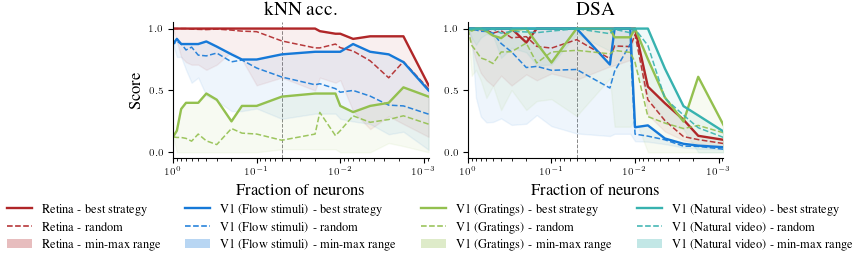

In [ ]:
# ── Appendix Fig 5: kNN + DSA Fraction Sweep (2 panels, side by side) ───────
print('=== Appendix Figure 5: kNN + DSA sweep ===')
fig_app5 = make_sweep_figure(
    {
        'Retina':                                results_Retina,
        'V1':                                    results_V1,
        'allen_VISp':                            results_aVISp,
        'VISp_natural_movie_one_scenes_all156':  results_VISp,
    },
    fracs_Retina,
    include_traj=COMPUTE_TRAJ_IN_SWEEP,
    keys_to_show=APP_SWEEP_KEYS,
    force_single_row=True,
    exclude_for_key={'acc': ['VISp_natural_movie_one_scenes_all156']},
    savepath=os.path.join(BASEDIR_FIG, 'fig_appendix_knn_dsa_sweep.pdf'),
)
plt.show()


### Appendix Figs 6–7 — Encoding Manifold Regions (1% and 10%)

The 1% and 10% versions of the main Figure 2 (5% regions).

=== Appendix Figure 6: 1% regions ===
  Computing DSA ref z for Retina...
  DSA ref z: 18.455603964421258
  Retina A: pc_contrib hi 1% -> n=11
  Retina B: pc_contrib lo 1% -> n=11
  Computing DSA ref z for V1...
  DSA ref z: 44.026677955317815
  V1 C: pc_contrib hi 1% -> n=6
  V1 D: pc_contrib lo 1% -> n=6
  Computing DSA ref z for allen_VISp...
  DSA ref z: 6.263503065690791
  allen_VISp E: pc_contrib hi 1% -> n=20
  allen_VISp F: pc_contrib lo 1% -> n=20
  Computing DSA ref z for VISp_natural_movie_one_scenes_all156...
  DSA ref z: 10.74072336277295
  VISp_natural_movie_one_scenes_all156 G: pc_contrib hi 1% -> n=20
  VISp_natural_movie_one_scenes_all156 H: pc_contrib lo 1% -> n=20
Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig_appendix_regions_01pct.pdf


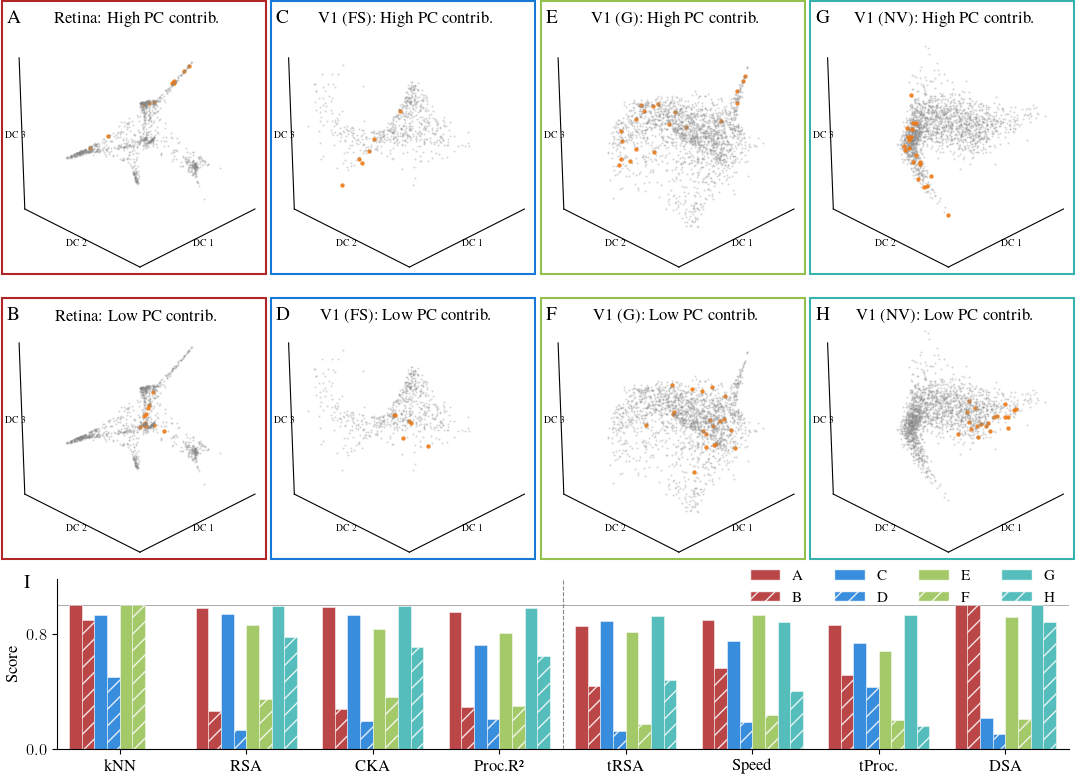

In [ ]:
# ── Appendix Fig 6: 1% Encoding Manifold Regions ────────────────────────────
print('=== Appendix Figure 6: 1% regions ===')
fig_app6 = make_combined_figure(
    datasets=_make_datasets_fig(0.01),
    gw_hl_data=None,
    savepath=os.path.join(BASEDIR_FIG, 'fig_appendix_regions_01pct.pdf'),
)
plt.show()

=== Appendix Figure 7: 10% regions ===
  Computing DSA ref z for Retina...
  DSA ref z: 18.455603964421258
  Retina A: pc_contrib hi 10% -> n=114
  Retina B: pc_contrib lo 10% -> n=114
  Computing DSA ref z for V1...
  DSA ref z: 44.026677955317815
  V1 C: pc_contrib hi 10% -> n=63
  V1 D: pc_contrib lo 10% -> n=63
  Computing DSA ref z for allen_VISp...
  DSA ref z: 6.263503065690791
  allen_VISp E: pc_contrib hi 10% -> n=196
  allen_VISp F: pc_contrib lo 10% -> n=196
  Computing DSA ref z for VISp_natural_movie_one_scenes_all156...
  DSA ref z: 10.74072336277295
  VISp_natural_movie_one_scenes_all156 G: pc_contrib hi 10% -> n=201
  VISp_natural_movie_one_scenes_all156 H: pc_contrib lo 10% -> n=201
Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig_appendix_regions_10pct.pdf


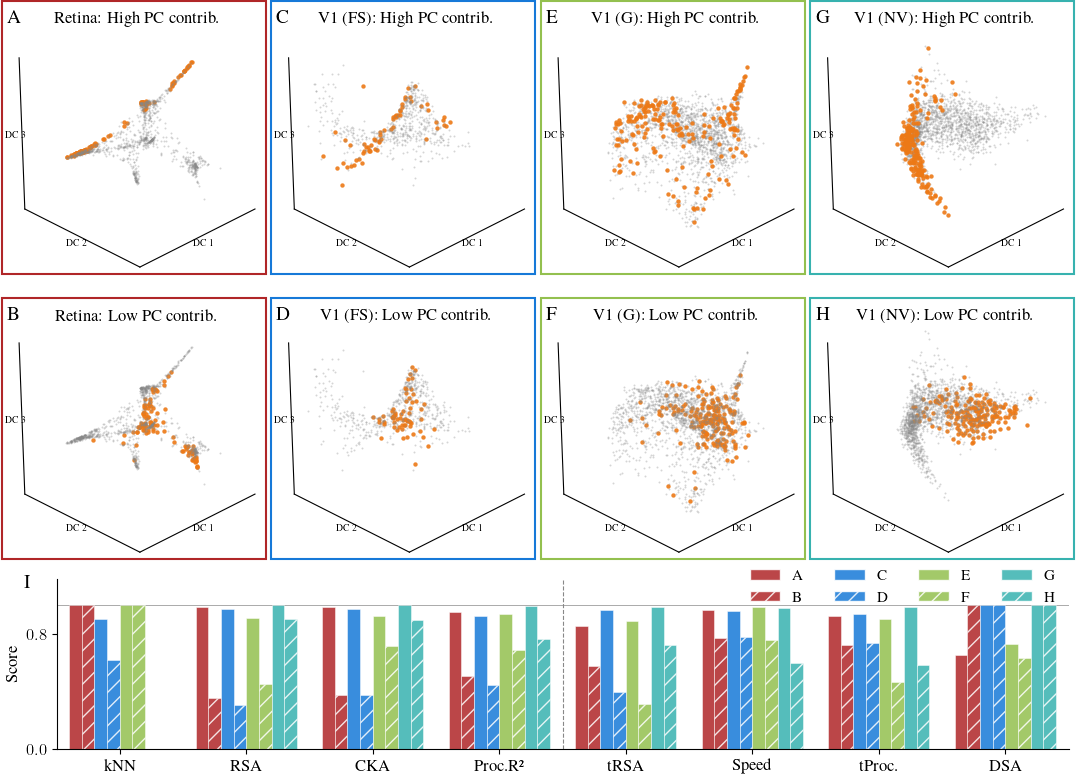

In [ ]:
# ── Appendix Fig 7: 10% Encoding Manifold Regions ───────────────────────────
print('=== Appendix Figure 7: 10% regions ===')
fig_app7 = make_combined_figure(
    datasets=_make_datasets_fig(0.10),
    gw_hl_data=None,
    savepath=os.path.join(BASEDIR_FIG, 'fig_appendix_regions_10pct.pdf'),
)
plt.show()

### Appendix Figs 8-9 - GW Metric Intuition and Encoding Pipeline Robustness

**Fig 8**: GW metric validated on (A) synthetic 3-D point clouds of known geometry (ring, torus, sphere, clustered, uniform ball, line) across 5 random seeds, and (B) cross-dataset pairwise comparisons among the four real datasets.

**Fig 9**: Encoding pipeline robustness. (A) Same encoding manifold run with different CP factor counts F for V1 (F=16,17) and Retina (F=14,15). (B) Same pipeline run on random neuron subsamples (60-100%) for V1 and Retina.

Loaded synthetic GW cache.


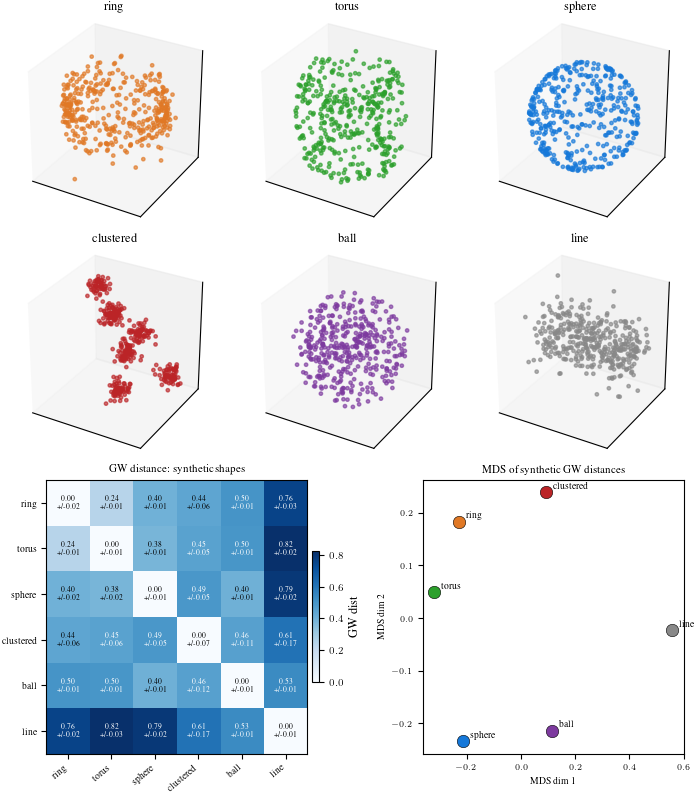

Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig_appendix_gw_validation.pdf


In [ ]:

# -- Appendix Fig 8: GW Metric -- Synthetic Shapes --
# Layout: (A) 2x3 shape scatter plots, (B) 6x6 GW distance heatmap + MDS side by side
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import MDS as _MDS
from tueplots import bundles
plt.rcParams.update(bundles.neurips2024())

from src.metrics import compute_gromov_hausdorff_approx

def _mk_ring(N=200, seed=0):
    rng = np.random.default_rng(seed); t = rng.uniform(0, 2*np.pi, N)
    return np.c_[np.cos(t), np.sin(t), np.zeros(N)] + rng.normal(0, 0.05, (N, 3))

def _mk_torus(N=200, seed=0):
    rng = np.random.default_rng(seed)
    u, v = rng.uniform(0, 2*np.pi, N), rng.uniform(0, 2*np.pi, N)
    x = (1 + 0.3*np.cos(v))*np.cos(u); y = (1 + 0.3*np.cos(v))*np.sin(u); z = 0.3*np.sin(v)
    return np.c_[x, y, z] + rng.normal(0, 0.02, (N, 3))

def _mk_sphere(N=200, seed=0):
    rng = np.random.default_rng(seed); X = rng.normal(0, 1, (N, 3))
    return X / np.linalg.norm(X, axis=1, keepdims=True)

def _mk_clustered(N=200, k=6, seed=0):
    rng = np.random.default_rng(seed)
    c = rng.uniform(-1, 1, (k, 3)); l = rng.integers(0, k, N)
    return c[l] + rng.normal(0, 0.12, (N, 3))

def _mk_ball(N=200, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (N, 3)); r = rng.uniform(0, 1, N)**(1/3)
    return X / np.linalg.norm(X, axis=1, keepdims=True) * r[:, None]

def _mk_line(N=200, seed=0):
    rng = np.random.default_rng(seed); t = rng.uniform(-1, 1, N)
    return np.c_[t, rng.normal(0, 0.02, N), rng.normal(0, 0.02, N)]

_SYNTH = [('ring', _mk_ring), ('torus', _mk_torus), ('sphere', _mk_sphere),
          ('clustered', _mk_clustered), ('ball', _mk_ball), ('line', _mk_line)]
_SYNTH_COLORS = {'ring': '#e07825', 'torus': '#2ca02c', 'sphere': '#1578d9',
                 'clustered': '#bb2427', 'ball': '#7d3a9f', 'line': '#888888'}

def _gw_raw(X, Y, max_pts=200, seed=0):
    rng = np.random.default_rng(seed)
    Xs = X[rng.choice(len(X), min(max_pts, len(X)), replace=False)]
    Ys = Y[rng.choice(len(Y), min(max_pts, len(Y)), replace=False)]
    return float(np.sqrt(abs(compute_gromov_hausdorff_approx(Xs, Ys))))

_CACHE_SYN = os.path.join(BASEDIR_CACHE, 'app_gw_synthetic.pkl')
_N_SEEDS   = 5
_SNAMES    = [s for s, _ in _SYNTH]; _NS = len(_SNAMES)

if os.path.exists(_CACHE_SYN):
    with open(_CACHE_SYN, 'rb') as _f: _syn_data = pickle.load(_f)
    print('Loaded synthetic GW cache.')
else:
    print('Computing synthetic GW matrix...')
    _syn_data = {}
    for _si, (_sn_i, _mk_i) in enumerate(_SYNTH):
        for _sj, (_sn_j, _mk_j) in enumerate(_SYNTH):
            for _s in range(_N_SEEDS):
                Xi = _mk_i(seed=_s); Xj = _mk_j(seed=(_s + 1) % _N_SEEDS)
                _syn_data[(_si, _sj, _s)] = _gw_raw(Xi, Xj)
            print(f'  {_sn_i} x {_sn_j} done')
    with open(_CACHE_SYN, 'wb') as _f: pickle.dump(_syn_data, _f)
    print('Saved.')

_D_mean = np.zeros((_NS, _NS)); _D_std = np.zeros((_NS, _NS))
for _si in range(_NS):
    for _sj in range(_NS):
        _vals = [_syn_data[(_si, _sj, _s)] for _s in range(_N_SEEDS)]
        _D_mean[_si, _sj] = np.mean(_vals); _D_std[_si, _sj] = np.std(_vals)
np.fill_diagonal(_D_mean, 0)
_D_mean = (_D_mean + _D_mean.T) / 2

# MDS embedding of synthetic GW distance matrix
_mds_syn = _MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=8)
_syn_emb = _mds_syn.fit_transform(_D_mean)

# -- Figure --
fig = plt.figure(figsize=(7, 8))
outer = gridspec.GridSpec(2, 1, figure=fig,
                          height_ratios=[2.2, 1.6], hspace=0.4)

# Row 0: 2x3 grid of 3D shape scatter plots
top_gs = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=outer[0],
                                          wspace=0.01, hspace=0.01)
for _si, (_sn, _mk) in enumerate(_SYNTH):
    _r, _c = divmod(_si, 3)
    ax3 = fig.add_subplot(top_gs[_r, _c], projection='3d')
    _pts = _mk(N=400, seed=0)
    ax3.scatter(_pts[:,0], _pts[:,1], _pts[:,2], s=6, alpha=0.65,
                c=_SYNTH_COLORS[_sn], rasterized=True)
    ax3.set_title(_sn, fontsize=9, pad=4)
    ax3.set_xticks([]); ax3.set_yticks([]); ax3.set_zticks([])
    ax3.set_box_aspect([1, 1, 1])

# Row 1: heatmap (left) + MDS (right)
bot_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1],
                                          wspace=0.05)
ax_syn = fig.add_subplot(bot_gs[0])
_vmax = _D_mean.max()
im1 = ax_syn.imshow(_D_mean, cmap='Blues', vmin=0, vmax=_vmax, aspect='auto')
ax_syn.set_xticks(range(_NS)); ax_syn.set_xticklabels(_SNAMES, rotation=40, ha='right', fontsize=7)
ax_syn.set_yticks(range(_NS)); ax_syn.set_yticklabels(_SNAMES, fontsize=7)
for _si in range(_NS):
    for _sj in range(_NS):
        _v = _D_mean[_si, _sj]; _s2 = _D_std[_si, _sj]
        _tc = 'white' if _v > _vmax * 0.55 else 'black'
        ax_syn.text(_sj, _si, f'{_v:.2f}\n+/-{_s2:.2f}', ha='center', va='center',
                    fontsize=5.5, color=_tc)
ax_syn.set_title('GW distance: synthetic shapes', fontsize=8)
plt.colorbar(im1, ax=ax_syn, fraction=0.025, label='GW dist', pad=0.02)

ax_smds = fig.add_subplot(bot_gs[1])
for _si, (_sn, _) in enumerate(_SYNTH):
    ax_smds.scatter(_syn_emb[_si, 0], _syn_emb[_si, 1],
                    s=80, color=_SYNTH_COLORS[_sn], zorder=3, edgecolors='k', lw=0.4)
    ax_smds.annotate(_sn, (_syn_emb[_si, 0], _syn_emb[_si, 1]),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
ax_smds.set_title('MDS of synthetic GW distances', fontsize=8)
ax_smds.set_xlabel('MDS dim 1', fontsize=7); ax_smds.set_ylabel('MDS dim 2', fontsize=7)
ax_smds.tick_params(labelsize=6)

_sp_gw = os.path.join(BASEDIR_FIG, 'fig_appendix_gw_validation.pdf')
fig.savefig(_sp_gw, bbox_inches='tight')
plt.show()
print(f'Saved: {_sp_gw}')


Loaded encoding robustness cache.
V1: N=637, tensorX=(637, 6, 1080)
  V1 100% F=10: cached (embedding reused)
  V1 100% F=15: cached (embedding reused)
  V1 100% F=20: cached (embedding reused)
  V1 75% F=10: cached (embedding reused)
  V1 75% F=15: cached (embedding reused)
  V1 75% F=20: cached (embedding reused)
  V1 50% F=10: cached (embedding reused)
  V1 50% F=15: cached (embedding reused)
  V1 50% F=20: cached (embedding reused)
Retina: N=1146, tensorX=(1146, 6, 1080)
  Retina 100% F=10: cached (embedding reused)
  Retina 100% F=15: cached (embedding reused)
  Retina 100% F=20: cached (embedding reused)
  Retina 75% F=10: cached (embedding reused)
  Retina 75% F=15: cached (embedding reused)
  Retina 75% F=20: cached (embedding reused)
  Retina 50% F=10: cached (embedding reused)
  Retina 50% F=15: cached (embedding reused)
  Retina 50% F=20: cached (embedding reused)

Re-running HDBSCAN (min_cluster_size=25) on all cached conditions...
  ('V1', 1.0, 10): k=3 clusters, noise=54%

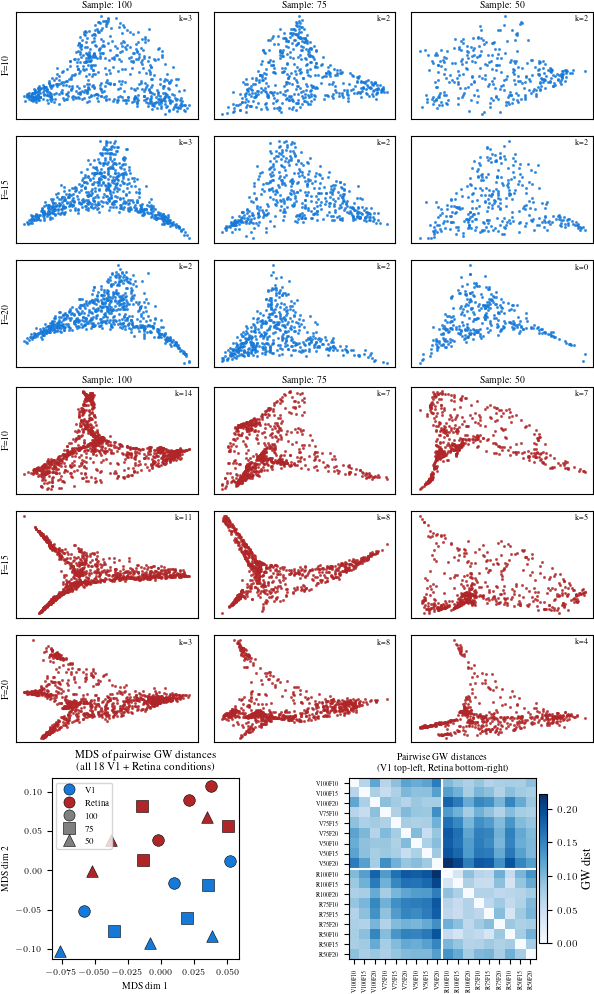

Saved: /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/fig_appendix_encoding_robustness.pdf


In [ ]:

# -- Appendix Fig 9: Encoding Pipeline Robustness -- full pipeline 3x3 grid --
# Rows = F (10, 15, 20), Cols = fraction (100%, 75%, 50%)
# Each cell: tensor4d -> CP (nreps=5) -> IAN -> diffmap -> MDS -> HDBSCAN
# Bottom panel: MDS of all-pairs GW distances showing V1 vs Retina clustering
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import csr_matrix
from sklearn.manifold import MDS as _MDS
from tueplots import bundles
plt.rcParams.update(bundles.neurips2024())

from ian.embed_utils import diffusionMapSparseK
from ian.utils import pwdists
from src.manifold_utils import compute_mds_embedding
from src.tensor_utils import (process_tensor_data, getPermutedTensor, getNeuralMatrix)
from src.cp_utils import run_cp_sweep
from src.metrics import compute_gromov_hausdorff_approx
from sklearn.decomposition import PCA as _PCA9
import hdbscan as _hdbscan

_S9  = os.path.join(BASEDIR, 'data', 'sampled')
_ERC = os.path.join(BASEDIR_CACHE, 'app_enc_rob9.pkl')
_GWC = os.path.join(BASEDIR_CACHE, 'app_enc_rob9_gw.pkl')

_ENC_FRACS = [1.00, 0.75, 0.50]
_ENC_FS    = [10, 15, 20]
_ENC_NREPS = 5
_FRAC_LABELS = {1.0: 'Sample: 100%', 0.75: 'Sample: 75%', 0.5: 'Sample: 50%'}
_FRAC_LABELS_LEGEND = {1.0: '100% of neurons', 0.75: '75% of neurons', 0.5: '50% of neurons'}
_FRAC_MARKERS = {1.0: 'o', 0.75: 's', 0.5: '^'}
_DS_COLORS_9 = {'V1': '#1679d8', 'Retina': '#b02628'}

_HDBSCAN_MIN_CLUSTER_SIZE = 25
_HDBSCAN_MIN_SAMPLES      = 4

def _run_one_condition(tensorX_sub, F, ndirs, wG_cache):
    from ian.ian import IAN as _IAN
    preComp = run_cp_sweep(tensorX_sub, [F], NDIRS=ndirs, nreps=_ENC_NREPS,
                           max_iter=200, n_jobs=1, verbose=False)
    best_rep, _ = min(preComp[F]['all_objs'].items(), key=lambda x: x[1])
    facs = preComp[F]['all_factors'][best_rep]; lams = preComp[F]['all_lambdas'][best_rep]
    pos  = ~np.isclose(lams, 0); lams = lams[pos]
    facs = [f[:, pos] / np.linalg.norm(f[:, pos], axis=0, keepdims=True) for f in facs]
    permT, _ = getPermutedTensor(facs, lams, tensorX_sub, ndirs)
    X, _     = getNeuralMatrix(permT, facs, lams, ndirs, None, order='F', verbose=False)
    pca = _PCA9(min(len(lams), X.shape[0] - 1)); pcaX = pca.fit_transform(X)
    nPCs = max(1, int(np.flatnonzero(np.cumsum(pca.explained_variance_ratio_) > 0.8)[0]) + 1)
    X_pca = pcaX[:, :nPCs]
    D2  = pwdists(X_pca, sqdists=True); D1 = np.sqrt(np.clip(D2, 0, None))
    mn  = np.min(D1 + np.eye(len(D1)) * D1.max(), axis=0)
    bad = np.unique(np.concatenate([np.argsort(mn)[::-1][:2], np.argsort(mn)[:5]]))
    keep = np.array([i for i in range(len(X_pca)) if i not in bad])
    X_k  = X_pca[keep]; D2_k = pwdists(X_k, sqdists=True)
    if wG_cache and os.path.exists(wG_cache):
        d = np.load(wG_cache, allow_pickle=False); wG = csr_matrix(d['wG'])
    else:
        G, wG, optS, disc = _IAN('exact-precomputed-sq', D2_k, solver=None)
        if wG_cache:
            _di = np.array([dp[0] for dp in disc], dtype=np.int64)
            np.savez(wG_cache, wG=wG.toarray(), optScales=optS, disc_pts_indices=_di)
    dm_y, _ = diffusionMapSparseK(wG, 20, alpha=1, t=1)
    emb = compute_mds_embedding(dm_y, 20, n_components=10)
    cl = _hdbscan.HDBSCAN(min_cluster_size=_HDBSCAN_MIN_CLUSTER_SIZE,
                           min_samples=_HDBSCAN_MIN_SAMPLES)
    lbl = cl.fit_predict(emb)
    k = len(set(lbl)) - (1 if -1 in lbl else 0); nf = (lbl == -1).mean()
    return emb, k, nf

# -- Load embedding cache (do NOT delete — recomputing takes very long) --
if os.path.exists(_ERC):
    with open(_ERC, 'rb') as _f: _enc9 = pickle.load(_f)
    print('Loaded encoding robustness cache.')
else:
    _enc9 = {}

# -- Compute any missing conditions (embedding + IAN pipeline) --
for _ds in ['V1', 'Retina']:
    _t4d = np.load(os.path.join(_S9, f'tensor4d_{_ds}.npy'))
    _t4d = np.nan_to_num(_t4d); _t4d -= _t4d.min()
    _nd = _t4d.shape[2]; _N_full = _t4d.shape[0]
    _tX_full, _, _ = process_tensor_data(_t4d, optSF=True, smooth_sig=3, method='relNorm')
    print(f'{_ds}: N={_N_full}, tensorX={_tX_full.shape}')
    for _frac in _ENC_FRACS:
        _N_sub = int(_frac * _N_full)
        _idx   = (np.random.default_rng(42).choice(_N_full, _N_sub, replace=False)
                  if _frac < 1.0 else np.arange(_N_full))
        _tX_sub = _tX_full[_idx]
        for _F in _ENC_FS:
            _key = (_ds, _frac, _F)
            if _key in _enc9:
                print(f'  {_ds} {_frac:.0%} F={_F}: cached (embedding reused)'); continue
            _wGc = os.path.join(BASEDIR_CACHE,
                                f'enc9_wG_{_ds}_f{int(_frac*100)}_F{_F}.npz')
            print(f'  {_ds} {_frac:.0%} F={_F} N={_N_sub}... ', end='', flush=True)
            import time as _t9; _t0 = _t9.time()
            _emb, _k, _nf = _run_one_condition(_tX_sub, _F, _nd, _wGc)
            print(f'{_t9.time()-_t0:.0f}s  k={_k} noise={_nf:.0%}')
            _enc9[_key] = {'emb': _emb, 'k': _k, 'nf': _nf, 'N': _N_sub}
            with open(_ERC, 'wb') as _f: pickle.dump(_enc9, _f)

# -- Re-run HDBSCAN with updated min_cluster_size on cached embeddings (no manifold recomputation) --
print(f'\nRe-running HDBSCAN (min_cluster_size={_HDBSCAN_MIN_CLUSTER_SIZE}) on all cached conditions...')
_hdb_updated = False
for _key, _d in _enc9.items():
    _emb = _d['emb']
    _cl  = _hdbscan.HDBSCAN(min_cluster_size=_HDBSCAN_MIN_CLUSTER_SIZE,
                              min_samples=_HDBSCAN_MIN_SAMPLES)
    _lbl = _cl.fit_predict(_emb)
    _k   = len(set(_lbl)) - (1 if -1 in _lbl else 0)
    _nf  = (_lbl == -1).mean()
    if _d.get('k') != _k or _d.get('nf') != _nf:
        _enc9[_key]['k']  = _k
        _enc9[_key]['nf'] = _nf
        _hdb_updated = True
    print(f'  {_key}: k={_k} clusters, noise={_nf:.0%}')
if _hdb_updated:
    with open(_ERC, 'wb') as _f: pickle.dump(_enc9, _f)
    print('Saved updated HDBSCAN results.')
print('All conditions complete.')

# -- Pairwise GW distances between all 18 embeddings --
_CONDS = [(_ds, _frac, _F)
          for _ds in ['V1', 'Retina']
          for _frac in _ENC_FRACS
          for _F in _ENC_FS]
_NC = len(_CONDS)   # 18

def _gw_between(emb_a, emb_b, max_pts=1200, seed=0):
    rng = np.random.default_rng(seed)
    A = emb_a[:, :3]; B = emb_b[:, :3]
    A = A[rng.choice(len(A), min(max_pts, len(A)), replace=False)]
    B = B[rng.choice(len(B), min(max_pts, len(B)), replace=False)]
    return float(np.sqrt(abs(compute_gromov_hausdorff_approx(A, B))))

if os.path.exists(_GWC):
    with open(_GWC, 'rb') as _f: _gw9 = pickle.load(_f)
    print('Loaded pairwise GW cache.')
else:
    print('Computing pairwise GW between 18 conditions...')
    _gw9 = np.zeros((_NC, _NC))
    for _i in range(_NC):
        for _j in range(_i + 1, _NC):
            _v = _gw_between(_enc9[_CONDS[_i]]['emb'], _enc9[_CONDS[_j]]['emb'])
            _gw9[_i, _j] = _gw9[_j, _i] = _v
            print(f'  {_CONDS[_i]} x {_CONDS[_j]}: {_v:.3f}')
    with open(_GWC, 'wb') as _f: pickle.dump(_gw9, _f)
    print('Saved.')

# MDS of 18x18 GW distance matrix
_gw9_sym = (_gw9 + _gw9.T) / 2; np.fill_diagonal(_gw9_sym, 0)
_mds9 = _MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=10)
_gw9_emb = _mds9.fit_transform(_gw9_sym)

# ── Figure ────────────────────────────────────────────────────────────────────
# Layout: outer[0] = V1 manifold grid, outer[1] = Retina manifold grid,
#         outer[2] = bottom MDS + heatmap
fig = plt.figure(figsize=(6, 10))
outer = gridspec.GridSpec(3, 1, figure=fig,
                          height_ratios=[1.2, 1.2, 0.8],
                          hspace=0.55)

for _di, _ds in enumerate(['V1', 'Retina']):
    # 3x3 grid inside each outer row
    ds_gs = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=outer[_di],
                                             wspace=0.08, hspace=0.05)
    
    for _fi, _F in enumerate(_ENC_FS):
        for _ci, _frac in enumerate(_ENC_FRACS):
            ax = fig.add_subplot(ds_gs[_fi, _ci])
            _d = _enc9.get((_ds, _frac, _F))
            if _d:
                _e = _d['emb']
                enc_c = '#b02628' if _ds == 'Retina' else '#1679d8'
                ax.scatter(_e[:, 0], _e[:, 1], s=1.5, alpha=0.7, c=enc_c)
                # k = number of HDBSCAN clusters, shown in top-right corner
                
                ax.text(0.97, 0.97, f'k={_d["k"]}',
                        ha='right', va='top', transform=ax.transAxes,
                        fontsize=6,
                        bbox=dict(boxstyle='round,pad=0.2', fc='white',
                                  alpha=0.8, lw=0))
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes, fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
            # Column headers show sample size — top row only, placed above subplot
            if _fi == 0:
                ax.set_title(_FRAC_LABELS[_frac], fontsize=7, pad=3)
            # Row labels (CP rank F) — left column only
            if _ci == 0:
                ax.set_ylabel(f'F={_F}', fontsize=7, rotation=90, labelpad=4)


# ── Bottom: MDS of all-pairs GW distances ─────────────────────────────────────
bot_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[2],
                                          wspace=0.35, width_ratios=[1.4, 0.05, 1.4])
ax_mds = fig.add_subplot(bot_gs[0])
for _i, (_ds, _frac, _F) in enumerate(_CONDS):
    _col = _DS_COLORS_9[_ds]; _mk = _FRAC_MARKERS[_frac]
    ax_mds.scatter(_gw9_emb[_i, 0], _gw9_emb[_i, 1],
                   s=70, c=_col, marker=_mk, edgecolors='k', lw=0.4, zorder=3)

# Legend: datasets and fraction = % of neurons sampled
from matplotlib.lines import Line2D
_lg = ([Line2D([0], [0], marker='o', color='w', markerfacecolor=_DS_COLORS_9['V1'],
                markersize=8, label='V1', markeredgecolor='k', markeredgewidth=0.4),
         Line2D([0], [0], marker='o', color='w', markerfacecolor=_DS_COLORS_9['Retina'],
                markersize=8, label='Retina', markeredgecolor='k', markeredgewidth=0.4)]
        + [Line2D([0], [0], marker=_FRAC_MARKERS[_fr], color='w', markerfacecolor='gray',
                   markersize=8, label=_FRAC_LABELS_LEGEND[_fr],
                   markeredgecolor='k', markeredgewidth=0.4)
           for _fr in _ENC_FRACS])
ax_mds.legend(handles=_lg, fontsize=6.5, loc='best', framealpha=0.8)
ax_mds.set_title('MDS of pairwise GW distances\n(all 18 V1 + Retina conditions)',
                 fontsize=8)
ax_mds.set_xlabel('MDS dim 1', fontsize=7); ax_mds.set_ylabel('MDS dim 2', fontsize=7)
ax_mds.tick_params(labelsize=6)

# Heatmap of 18x18 GW distance matrix (V1 top-left block, Retina bottom-right)
ax_hm = fig.add_subplot(bot_gs[2])
im9 = ax_hm.imshow(_gw9_sym, cmap='Blues', aspect='auto')
ax_hm.set_xticks(range(_NC))
ax_hm.set_xticklabels([f'{_ds[0]}{int(_fr*100)}F{_F}'
                        for _ds, _fr, _F in _CONDS], rotation=90, fontsize=4.5)
ax_hm.set_yticks(range(_NC))
ax_hm.set_yticklabels([f'{_ds[0]}{int(_fr*100)}F{_F}'
                        for _ds, _fr, _F in _CONDS], fontsize=4.5)
ax_hm.axhline(8.5, color='white', lw=1.5)
ax_hm.axvline(8.5, color='white', lw=1.5)
ax_hm.set_title('Pairwise GW distances\n(V1 top-left, Retina bottom-right)', fontsize=7)
plt.colorbar(im9, ax=ax_hm, fraction=0.04, label='GW dist', pad=0.02)

_sp_enc = os.path.join(BASEDIR_FIG, 'fig_appendix_encoding_robustness.pdf')
fig.savefig(_sp_enc, bbox_inches='tight')
plt.show()
print(f'Saved: {_sp_enc}')



=== vit_b_16_L11_n2000_frames ===
../data/decompositions/vit_b_16_L11_n2000_frames-relNorm_sig3_n2000_SF-deepnet-shift*_F*.mat
F10: (5)
  vit_b_16_L11_n2000_frames: N_nonout=1992  NSTIMS=6  NDIRS=8  T=37
  N=1992  NSTIMS=6  NDIRS=8  DSA ref z=6.378
  smooth: 100 neurons (5.0%)
  clustered: 100 neurons (5.0%)


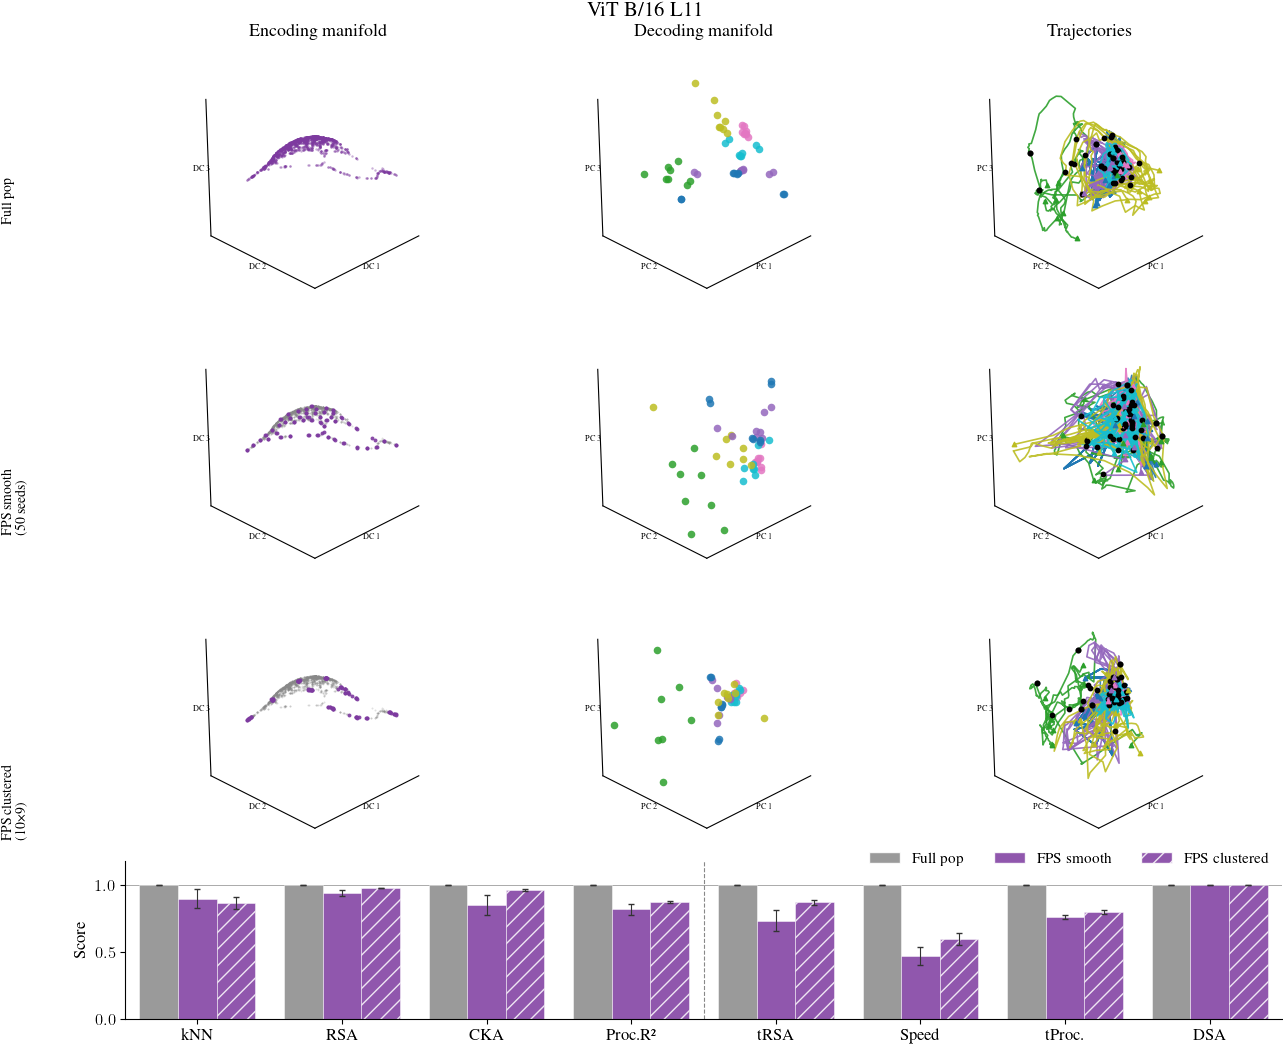

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_vit_b_16_L11_n2000_frames.pdf

=== raptor3_n2000 ===
../data/decompositions/raptor3_n2000-relNorm_sig3_n2000-deepnet-shift*_F*.mat
F25: (10)
  raptor3_n2000: N_nonout=1983  NSTIMS=10  NDIRS=10  T=12
  N=1983  NSTIMS=10  NDIRS=10  DSA ref z=146.396
  smooth: 100 neurons (5.0%)
  clustered: 100 neurons (5.0%)


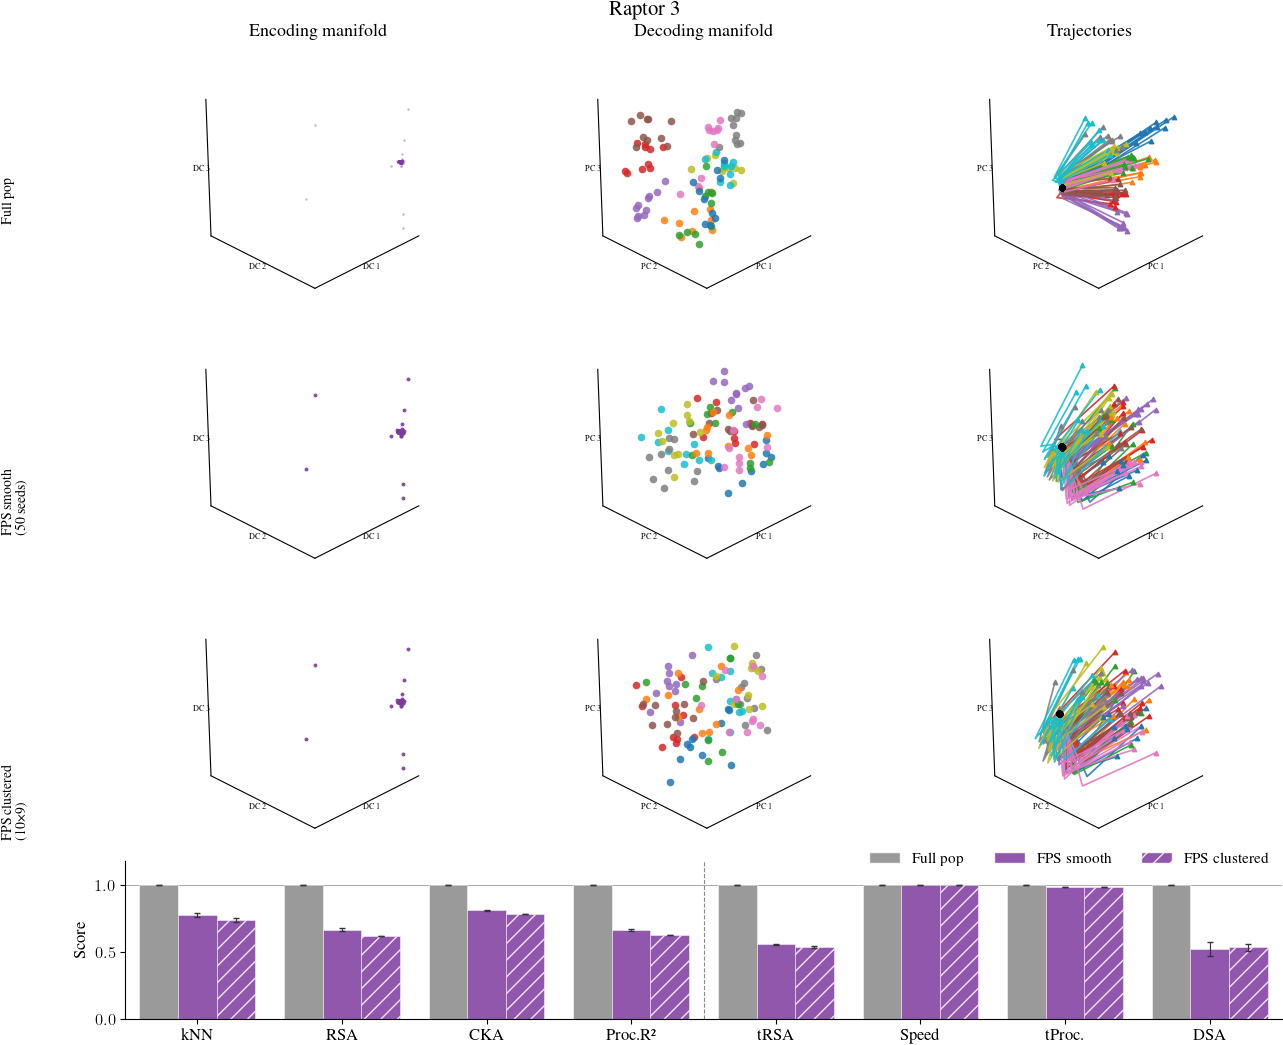

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_raptor3_n2000.pdf

=== allen_VISp ===
  N=1955  NSTIMS=5  NDIRS=8  DSA ref z=6.264
  smooth: 100 neurons (5.1%)
  clustered: 100 neurons (5.1%)


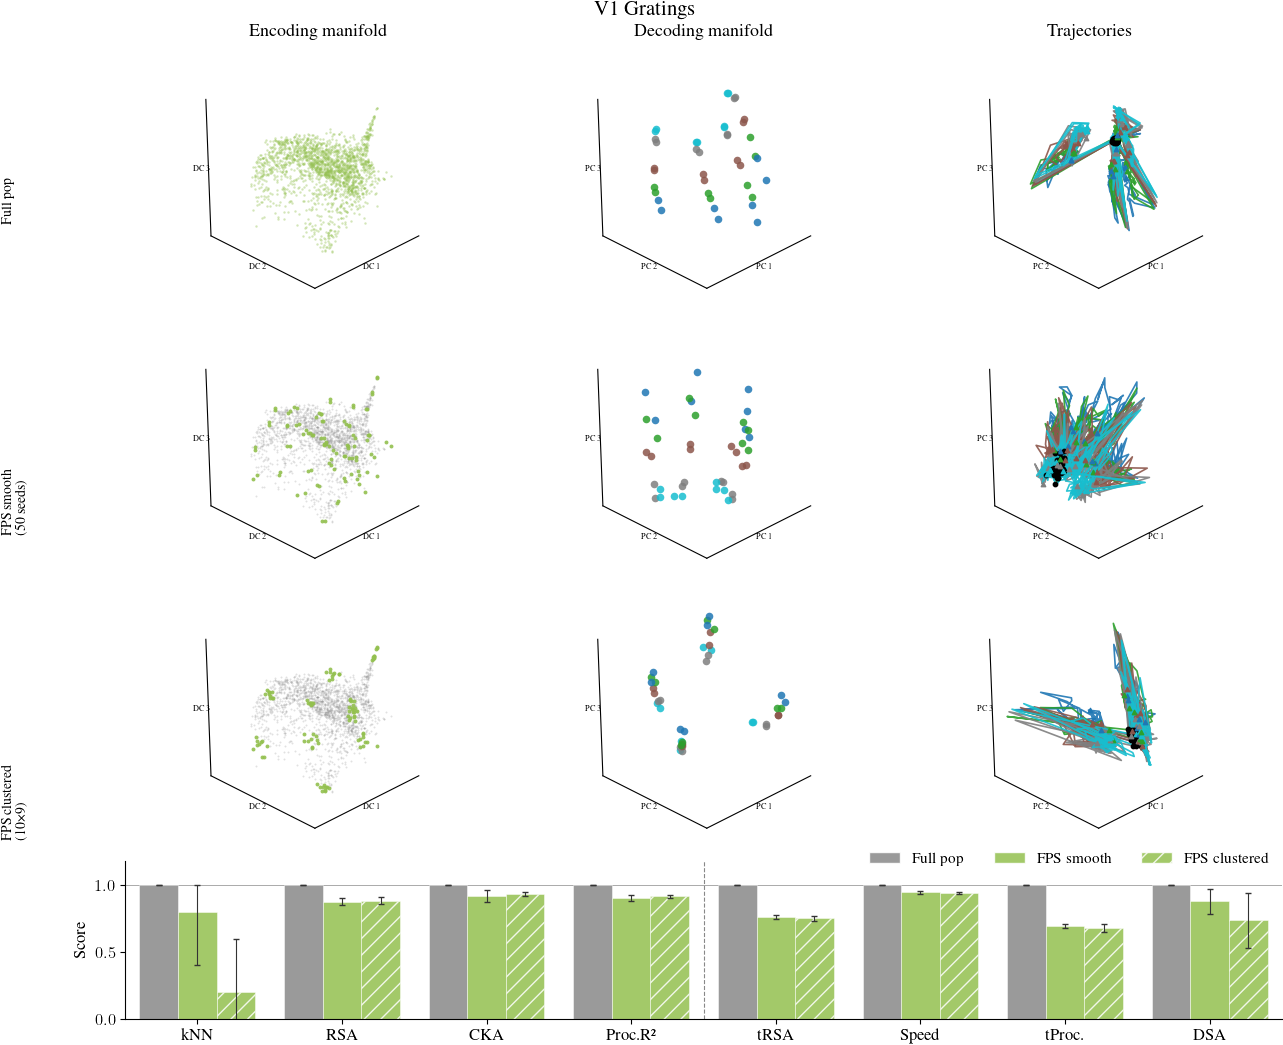

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_allen_VISp.pdf

=== allen_VISrl ===
../data/decompositions/allen_VISrl-relNorm_sig3_n1409-deepnet-shift*_F*.mat
F12: (5)
  allen_VISrl: N_nonout=1402  NSTIMS=5  NDIRS=8  T=40
  N=1402  NSTIMS=5  NDIRS=8  DSA ref z=19.400
  smooth: 100 neurons (7.1%)
  clustered: 100 neurons (7.1%)


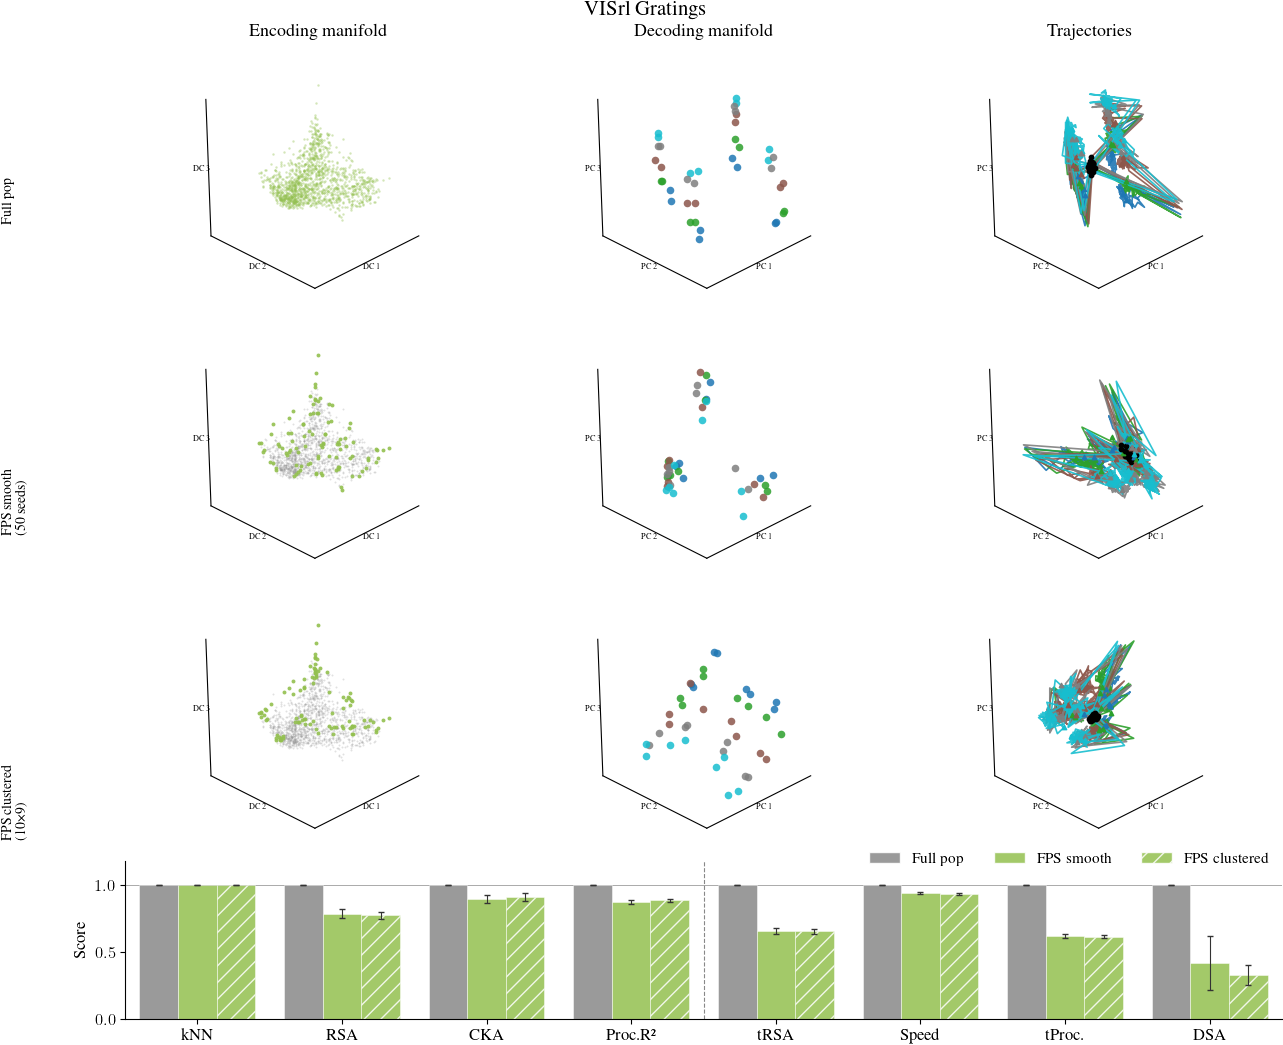

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_allen_VISrl.pdf

=== allen_VISam ===
../data/decompositions/allen_VISam-relNorm_sig3_n1488-deepnet-shift*_F*.mat
F12: (5)
  allen_VISam: N_nonout=1481  NSTIMS=5  NDIRS=8  T=40
  N=1481  NSTIMS=5  NDIRS=8  DSA ref z=9.175
  smooth: 100 neurons (6.8%)
  clustered: 100 neurons (6.8%)


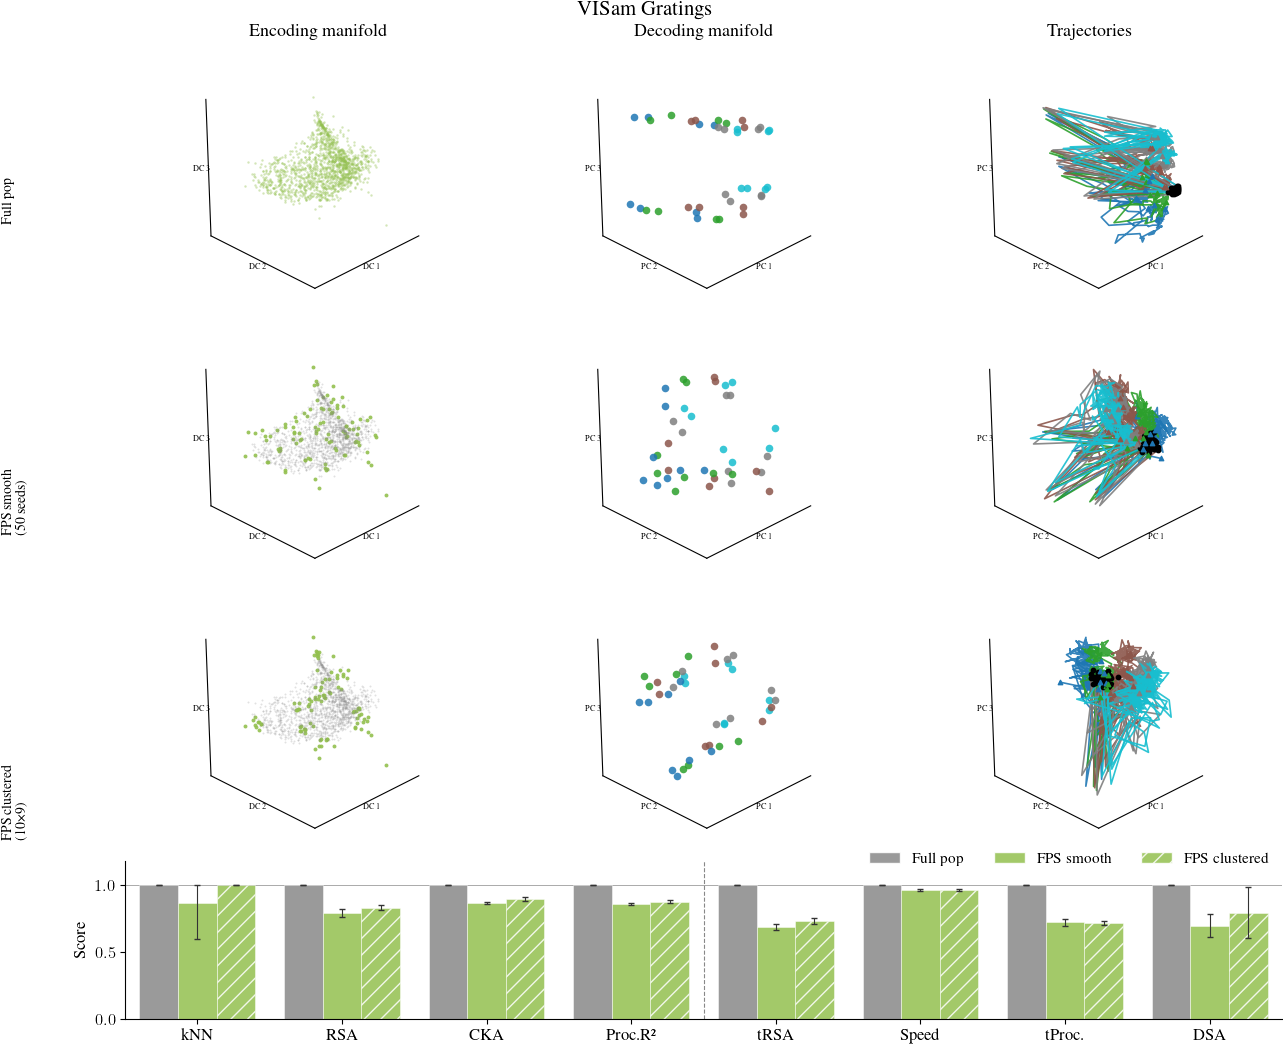

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_allen_VISam.pdf

=== allen_VISpm ===
../data/decompositions/allen_VISpm-relNorm_sig3_n867-deepnet-shift*_F*.mat
F12: (5)
  allen_VISpm: N_nonout=860  NSTIMS=5  NDIRS=8  T=40
  N=860  NSTIMS=5  NDIRS=8  DSA ref z=12.393
  smooth: 100 neurons (11.6%)
  clustered: 100 neurons (11.6%)


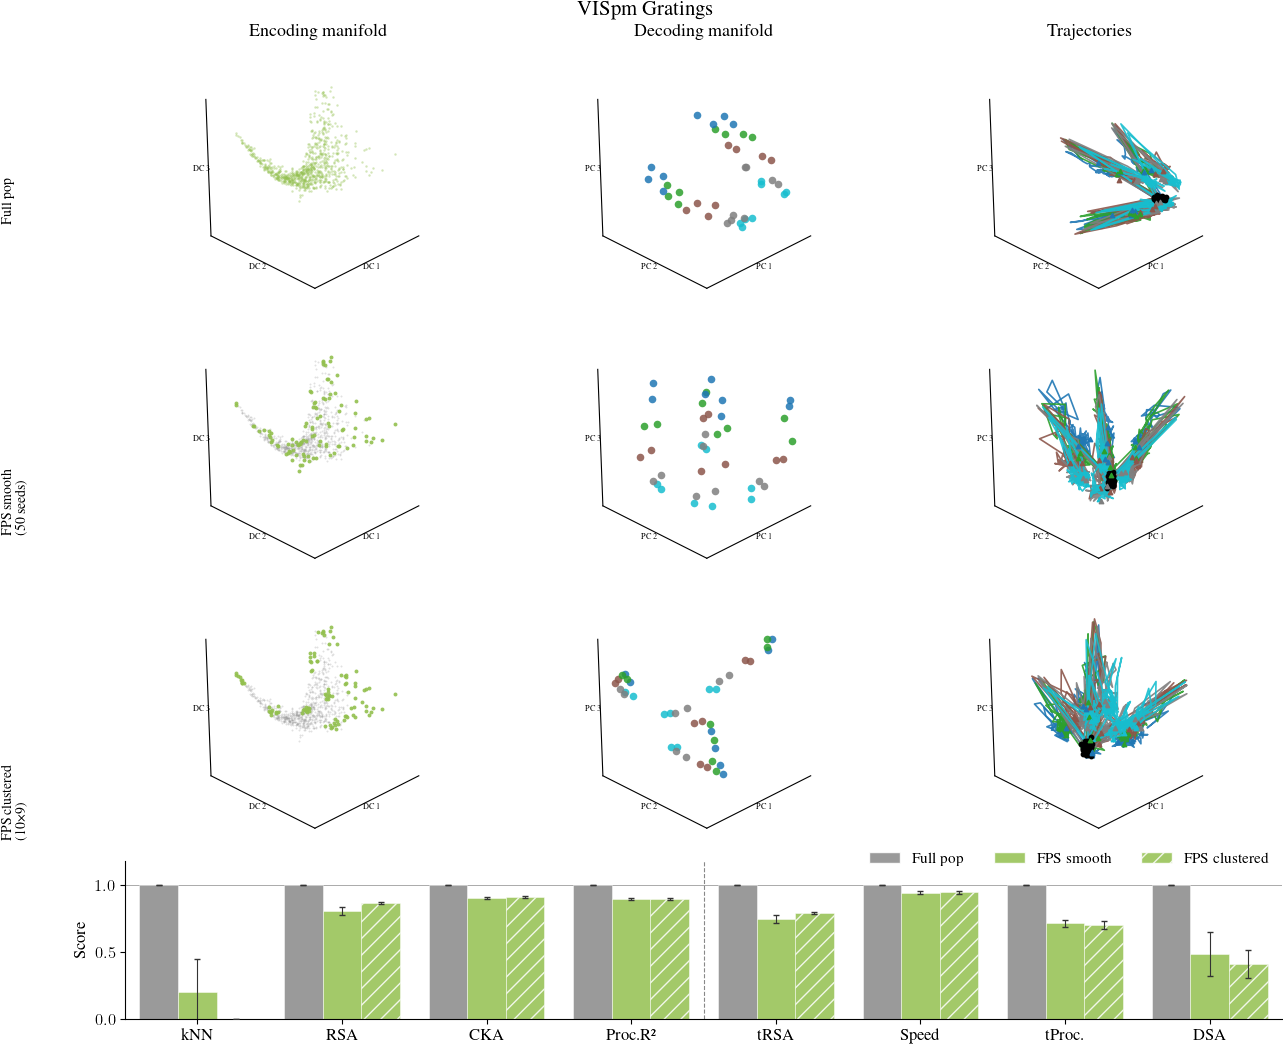

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_allen_VISpm.pdf

=== allen_VISl ===
../data/decompositions/allen_VISl-relNorm_sig3_n922-deepnet-shift*_F*.mat
F12: (5)
  allen_VISl: N_nonout=915  NSTIMS=5  NDIRS=8  T=40
  N=915  NSTIMS=5  NDIRS=8  DSA ref z=4.814
  smooth: 100 neurons (10.9%)
  clustered: 100 neurons (10.9%)


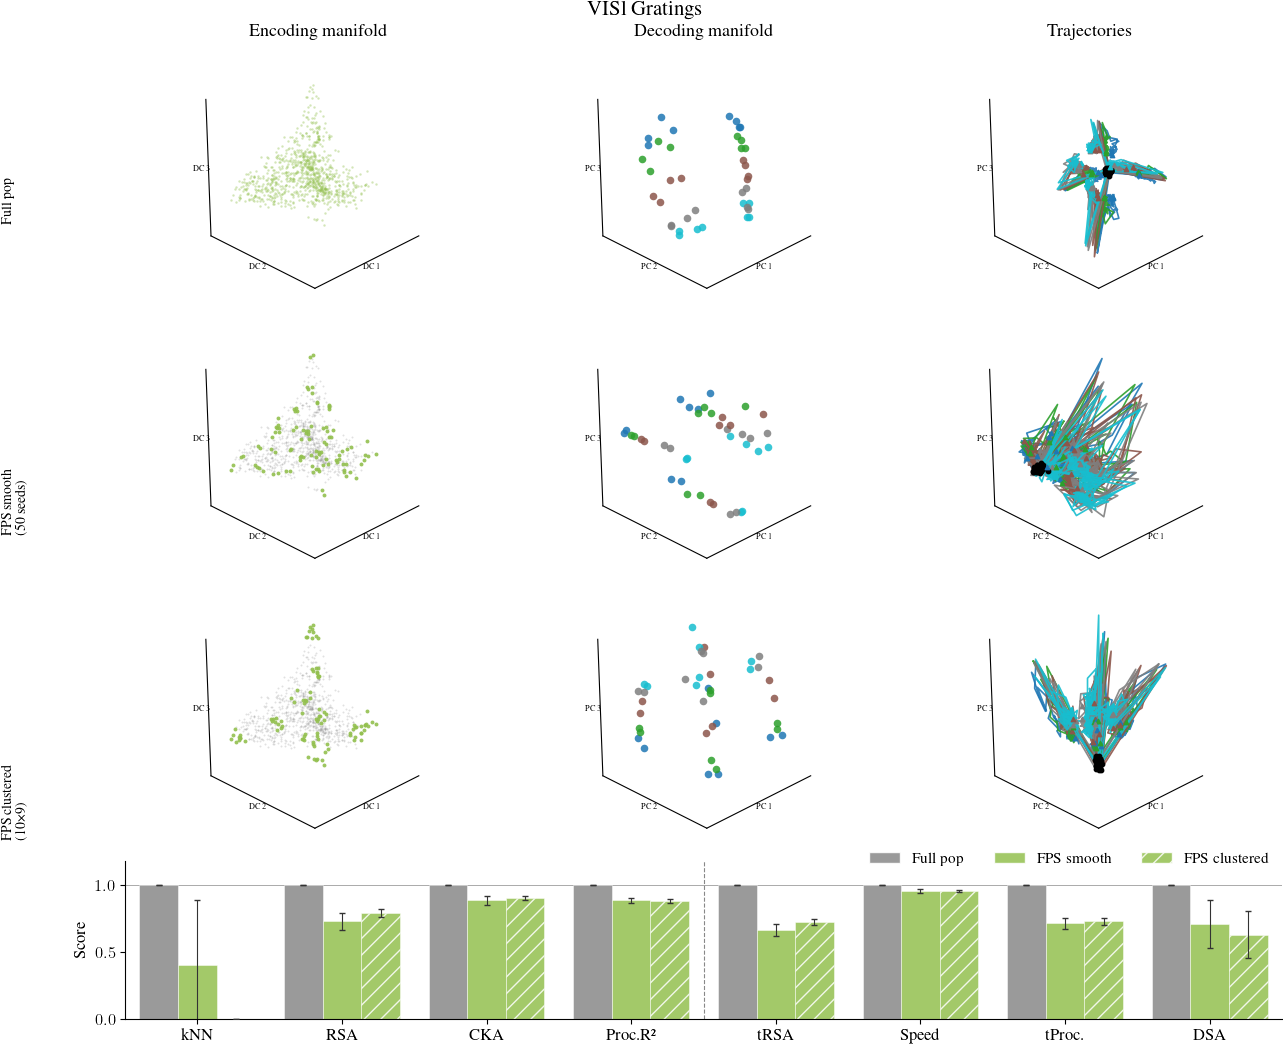

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_allen_VISl.pdf

=== VISp_natural_movie_one_scenes_all156 ===
  N=2008  NSTIMS=14  NDIRS=1  DSA ref z=10.741
  smooth: 100 neurons (5.0%)
  clustered: 100 neurons (5.0%)


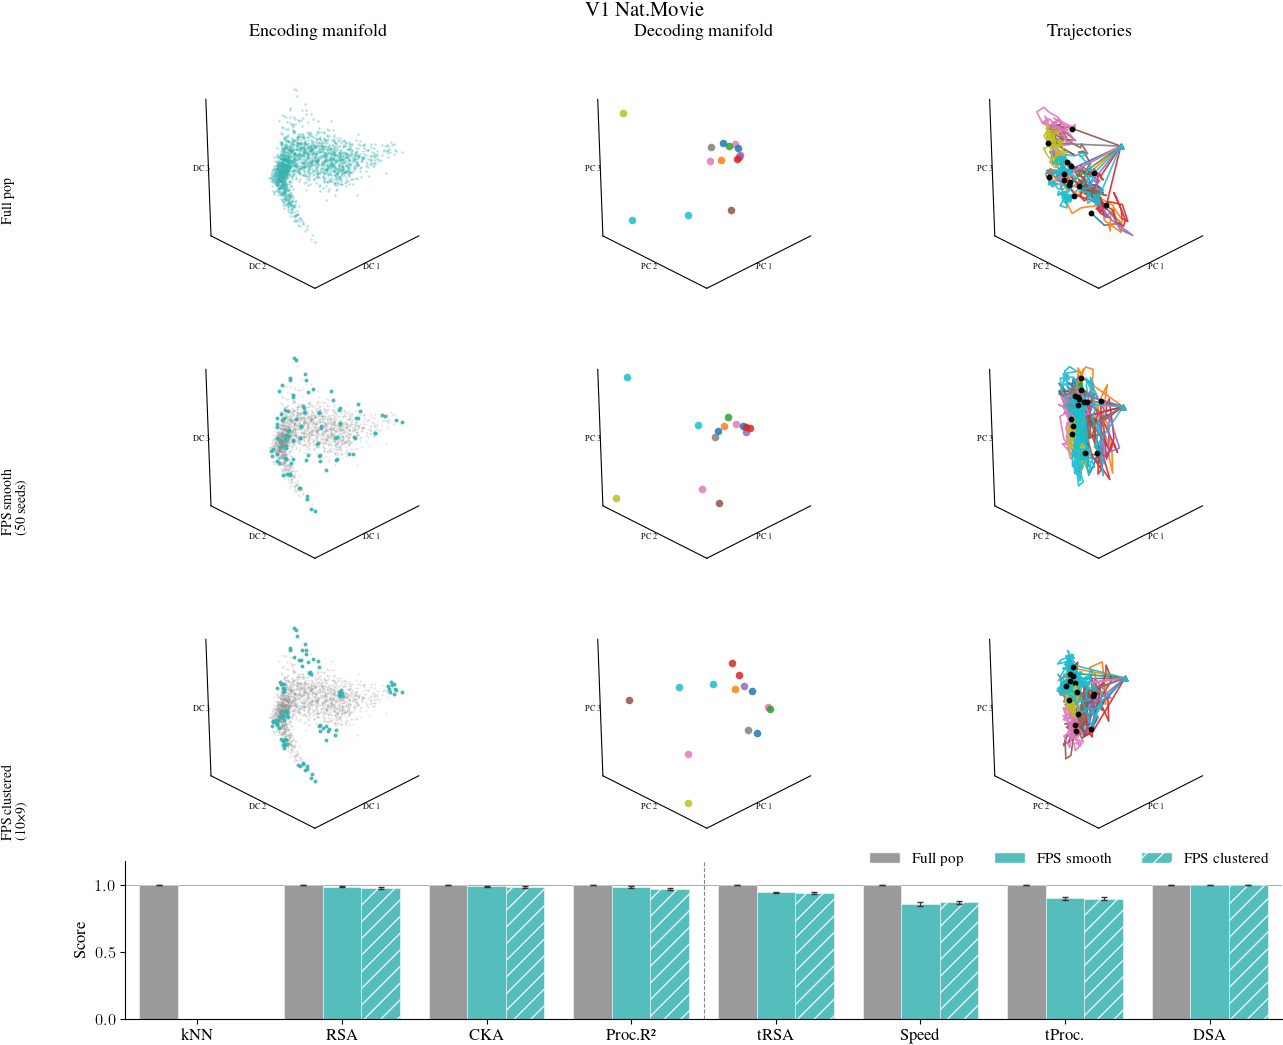

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_VISp_natural_movie_one_scenes_all156.pdf

=== VISam_natural_movie_one_scenes_all156 ===
../data/decompositions/VISam_natural_movie_one_scenes_all156-relNorm_sig3_n1506-deepnet-shift*_F*.mat
F15: (5)
  VISam_natural_movie_one_scenes_all156: N_nonout=1499  NSTIMS=14  NDIRS=1  T=156
  N=1499  NSTIMS=14  NDIRS=1  DSA ref z=10.617
  smooth: 100 neurons (6.7%)
  clustered: 100 neurons (6.7%)


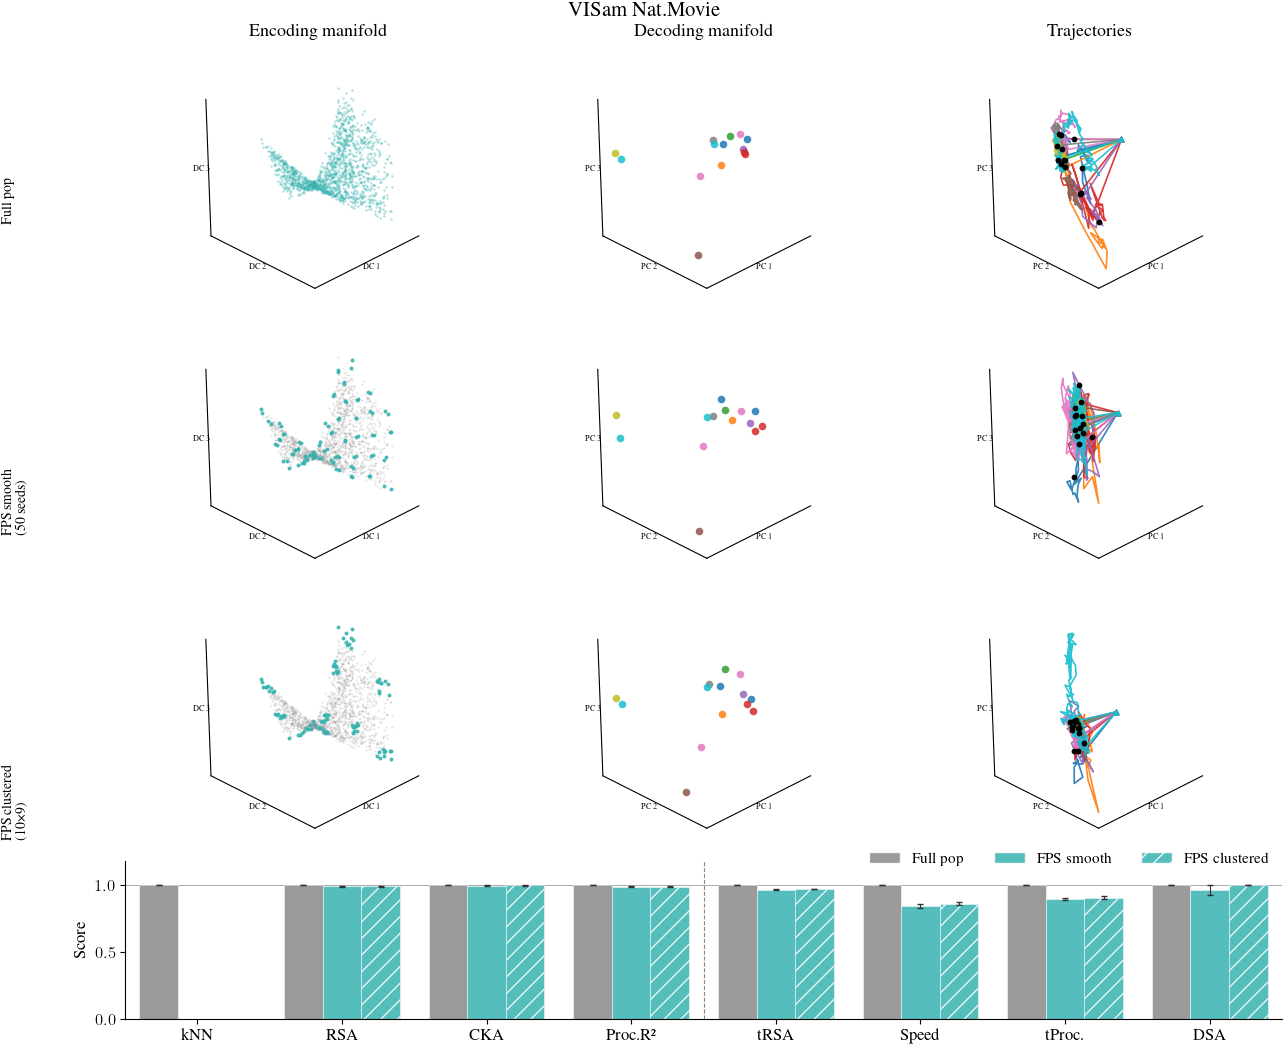

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_VISam_natural_movie_one_scenes_all156.pdf

=== VISrl_natural_movie_one_scenes_all156 ===
../data/decompositions/VISrl_natural_movie_one_scenes_all156-relNorm_sig3_n1415-deepnet-shift*_F*.mat
F15: (5)
  VISrl_natural_movie_one_scenes_all156: N_nonout=1408  NSTIMS=14  NDIRS=1  T=156
  N=1408  NSTIMS=14  NDIRS=1  DSA ref z=9.070
  smooth: 100 neurons (7.1%)
  clustered: 100 neurons (7.1%)


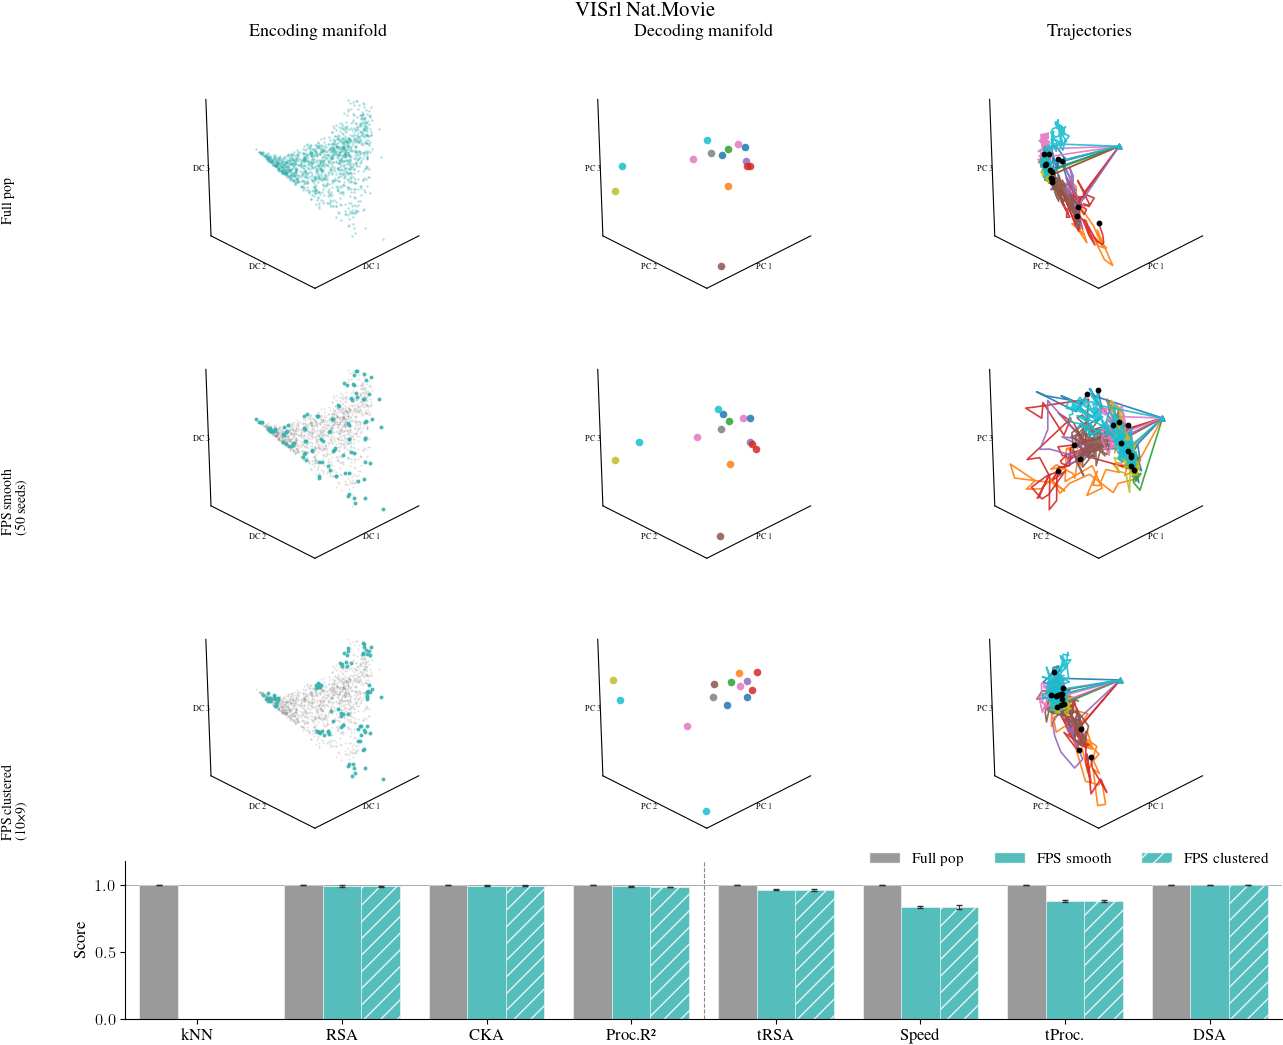

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_VISrl_natural_movie_one_scenes_all156.pdf

=== VISpm_natural_movie_one_scenes_all156 ===
../data/decompositions/VISpm_natural_movie_one_scenes_all156-relNorm_sig3_n879-deepnet-shift*_F*.mat
F15: (5)
  VISpm_natural_movie_one_scenes_all156: N_nonout=872  NSTIMS=14  NDIRS=1  T=156
  N=872  NSTIMS=14  NDIRS=1  DSA ref z=8.871
  smooth: 100 neurons (11.5%)
  clustered: 100 neurons (11.5%)


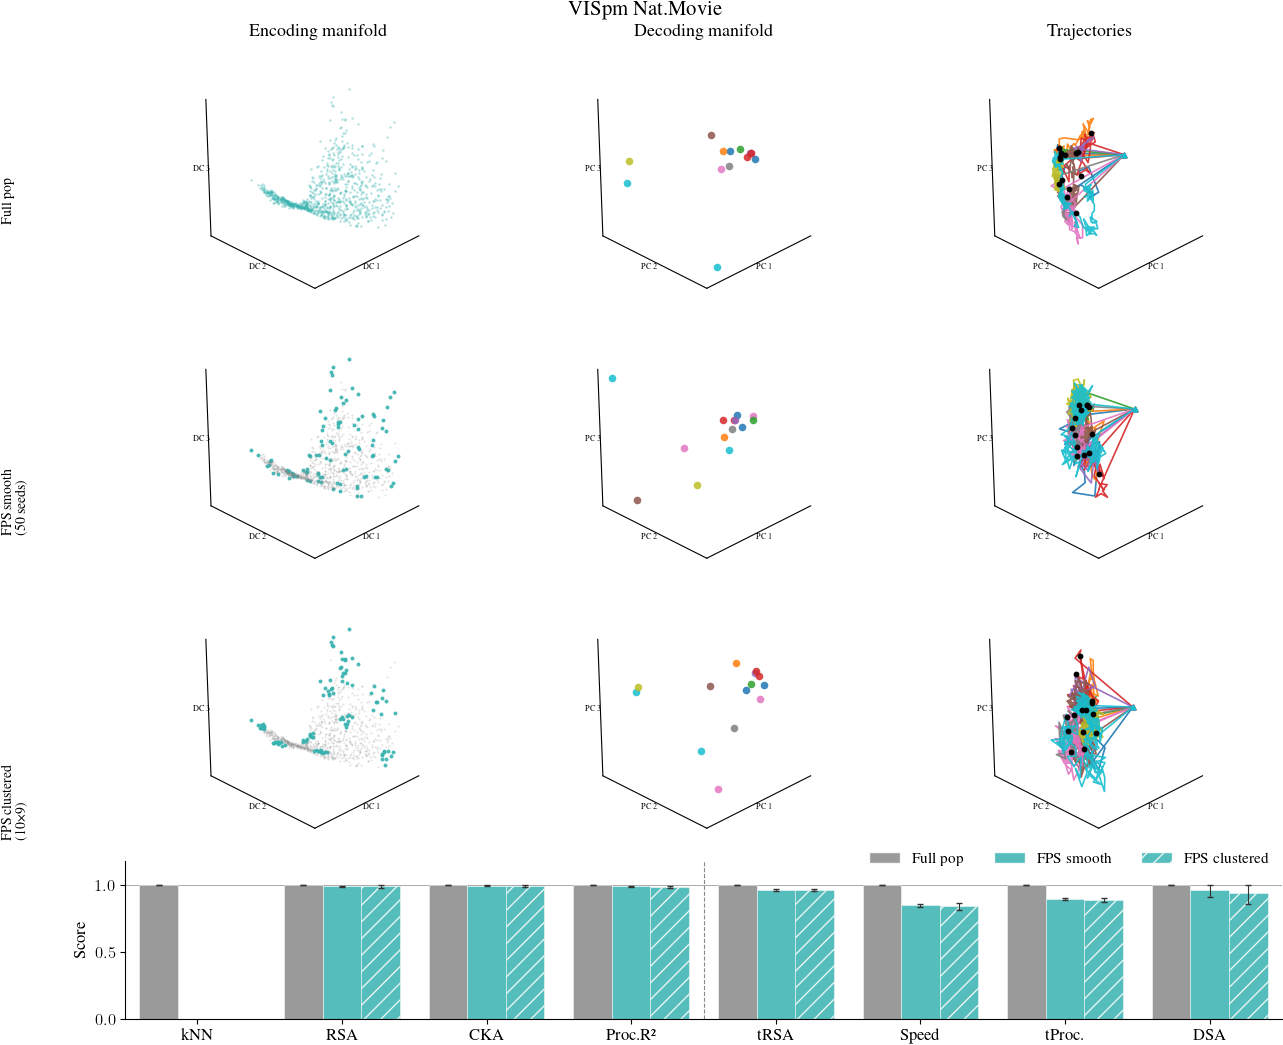

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_VISpm_natural_movie_one_scenes_all156.pdf

=== VISl_natural_movie_one_scenes_all156 ===
../data/decompositions/VISl_natural_movie_one_scenes_all156-relNorm_sig3_n933-deepnet-shift*_F*.mat
F15: (5)
  VISl_natural_movie_one_scenes_all156: N_nonout=926  NSTIMS=14  NDIRS=1  T=156
  N=926  NSTIMS=14  NDIRS=1  DSA ref z=14.189
  smooth: 100 neurons (10.8%)
  clustered: 100 neurons (10.8%)


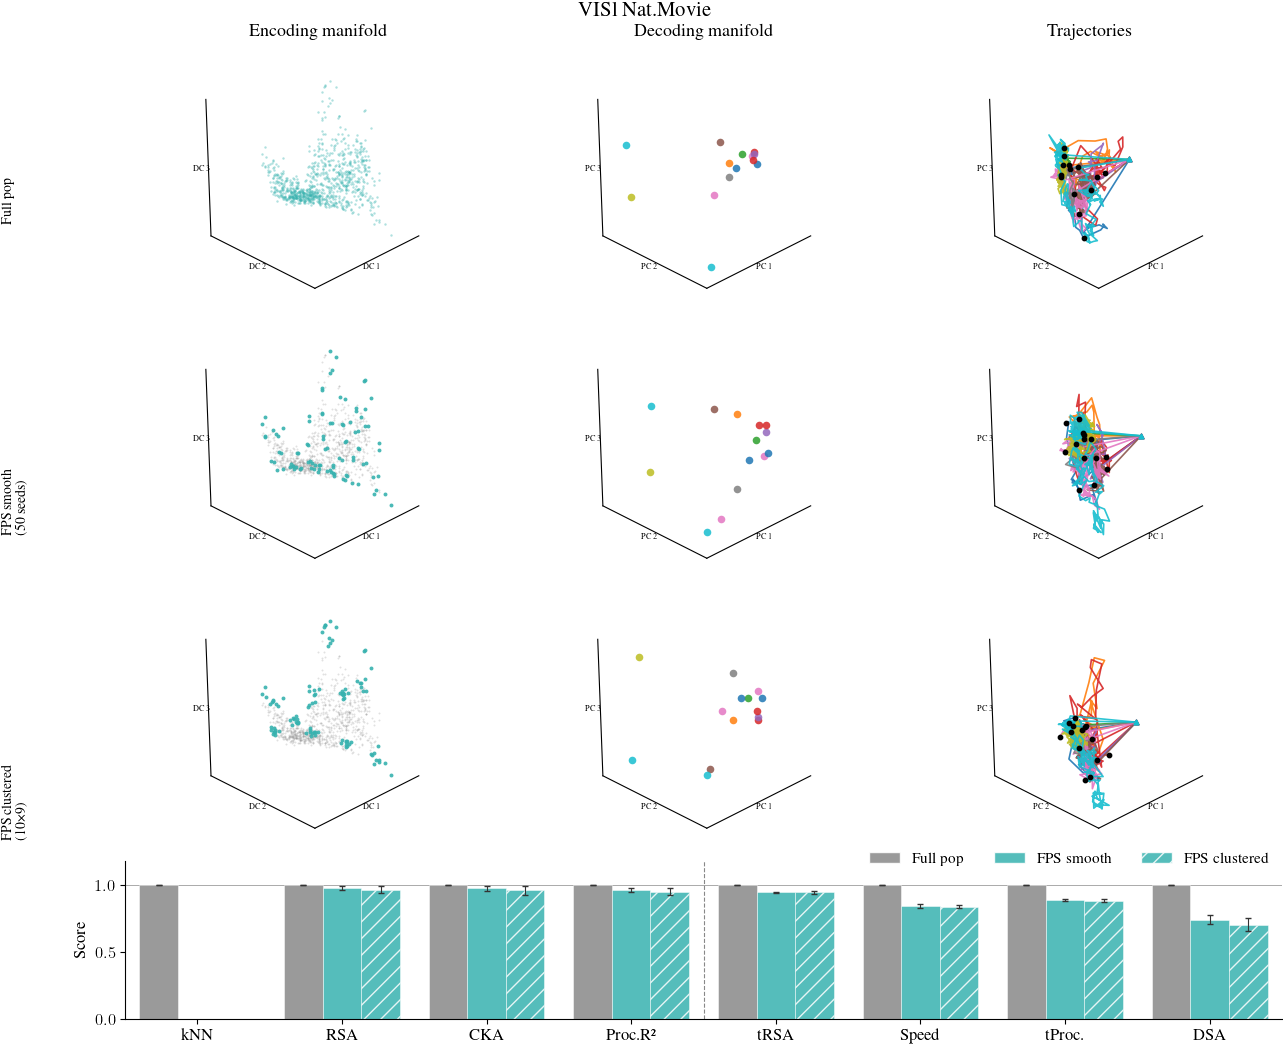

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_VISl_natural_movie_one_scenes_all156.pdf

=== V1 ===
  N=630  NSTIMS=6  NDIRS=8  DSA ref z=44.027
  smooth: 100 neurons (15.9%)
  clustered: 100 neurons (15.9%)


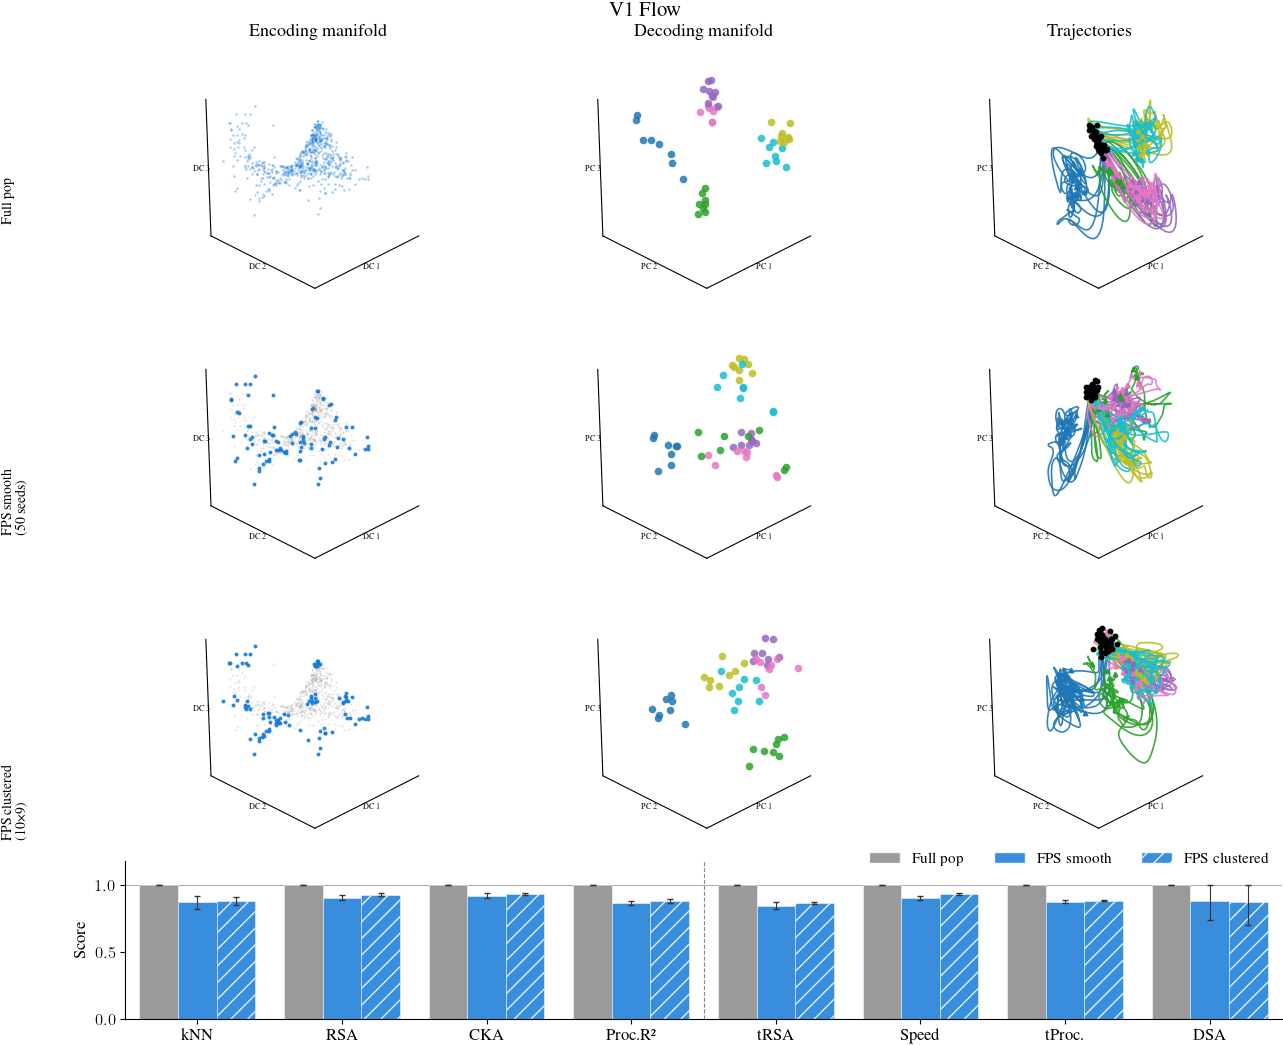

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_V1.pdf

=== Retina ===
  N=1139  NSTIMS=6  NDIRS=8  DSA ref z=18.456
  smooth: 100 neurons (8.8%)
  clustered: 100 neurons (8.8%)


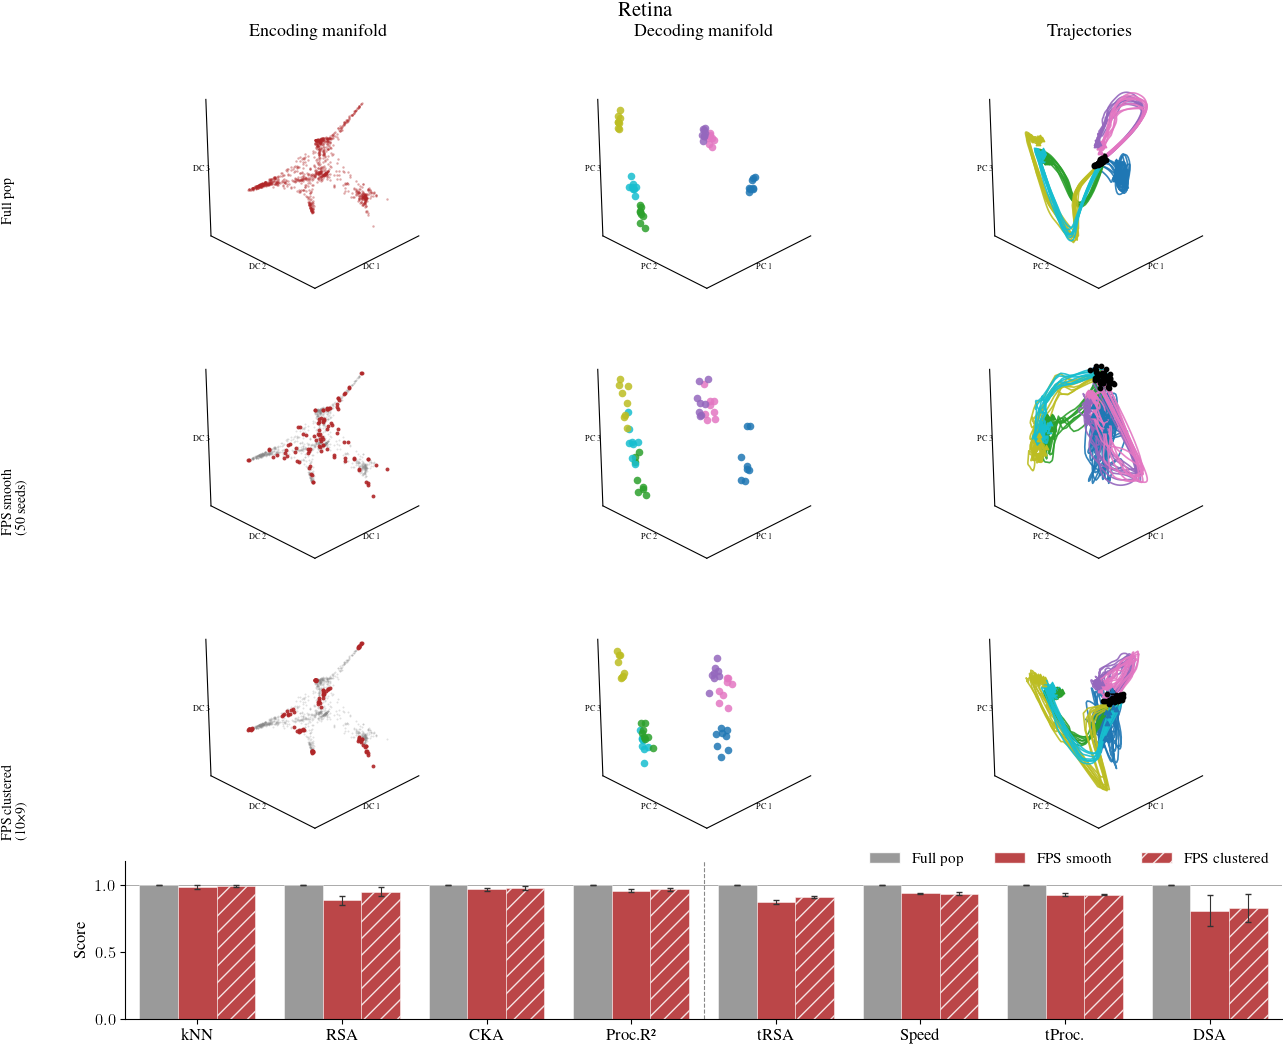

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_Retina.pdf

=== fnn07_seed2 ===
../data/decompositions/fnn07_seed2-relNorm_sig3_n1000_SF-deepnet-shift*_F*.mat
F15: (5)
  fnn07_seed2: N_nonout=993  NSTIMS=6  NDIRS=8  T=37
  N=993  NSTIMS=6  NDIRS=8  DSA ref z=47.807
  smooth: 100 neurons (10.1%)
  clustered: 100 neurons (10.1%)


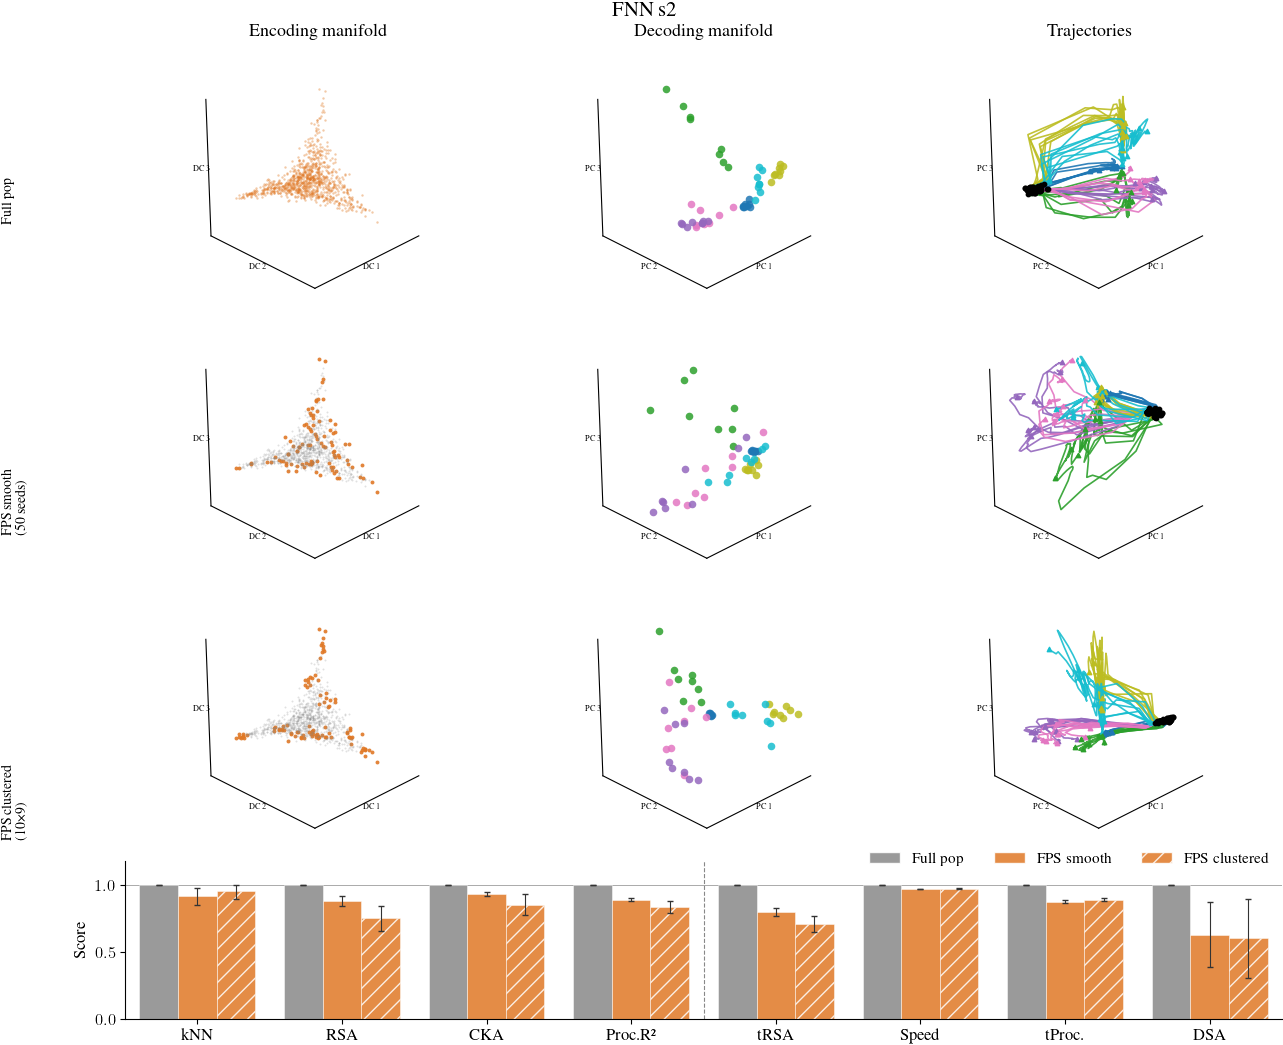

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_fnn07_seed2.pdf

=== fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1 ===
../data/decompositions/fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1-relNorm_sig3_n2000_SF-deepnet-shift*_F*.mat
../data/decompositions/fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1*_F*.mat
F10: (30)
  fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1: N_nonout=1993  NSTIMS=6  NDIRS=8  T=37
  N=1993  NSTIMS=6  NDIRS=8  DSA ref z=25.541
  smooth: 100 neurons (5.0%)
  clustered: 100 neurons (5.0%)


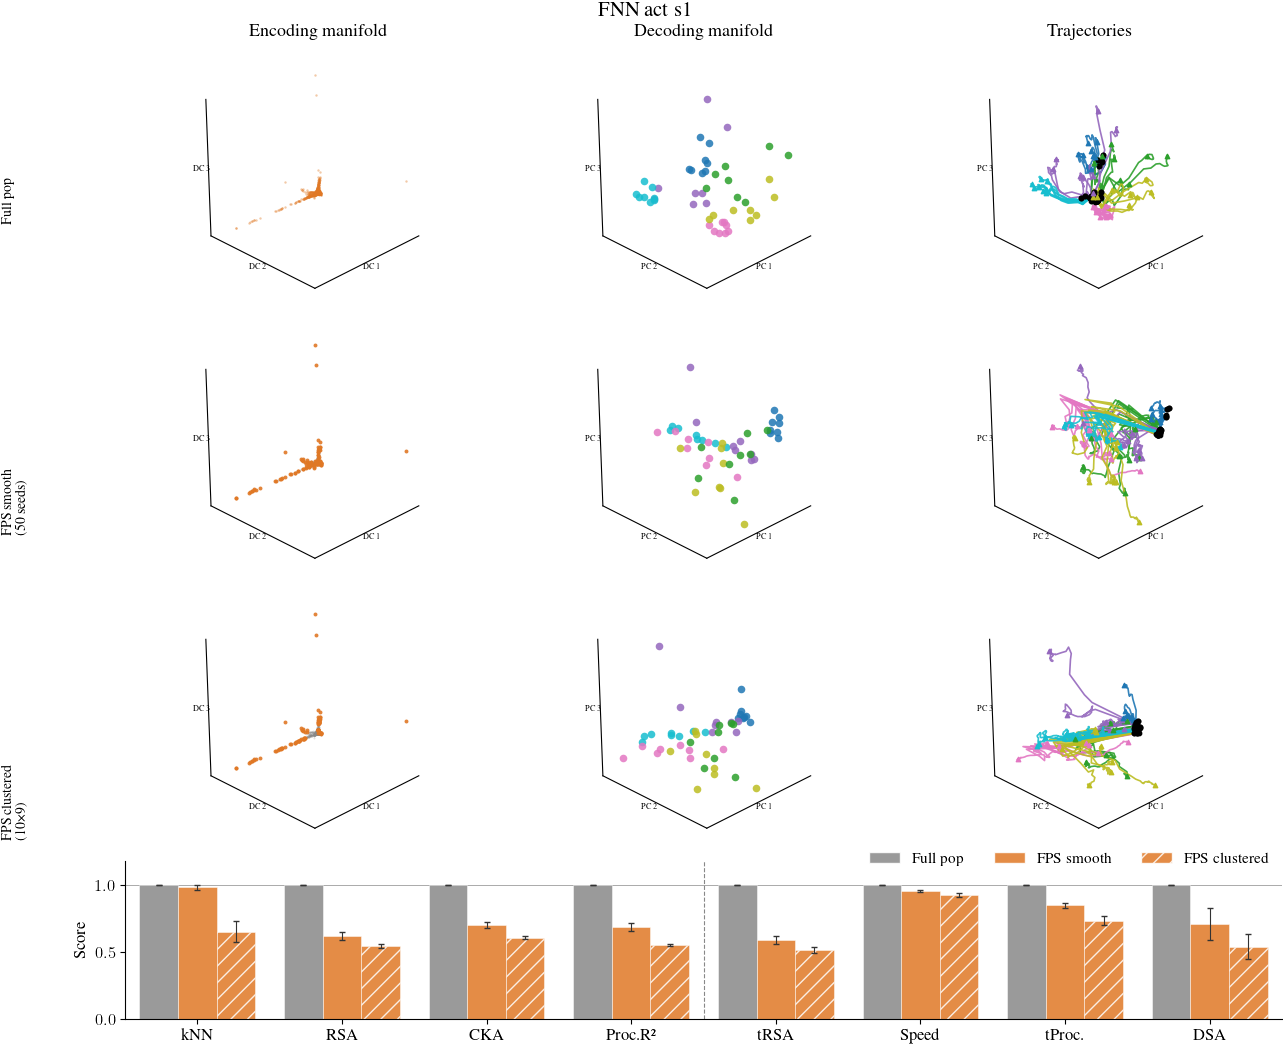

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1.pdf

=== flyvis_T_Tm_i3_n1700_model000 ===
../data/decompositions/flyvis_T_Tm_i3_n1700_model000-relNorm_sig3_n1700_SF-deepnet-shift*_F*.mat
F11: (30)
  flyvis_T_Tm_i3_n1700_model000: N_nonout=1693  NSTIMS=6  NDIRS=8  T=37
  N=1693  NSTIMS=6  NDIRS=8  DSA ref z=8.506
  smooth: 100 neurons (5.9%)
  clustered: 100 neurons (5.9%)


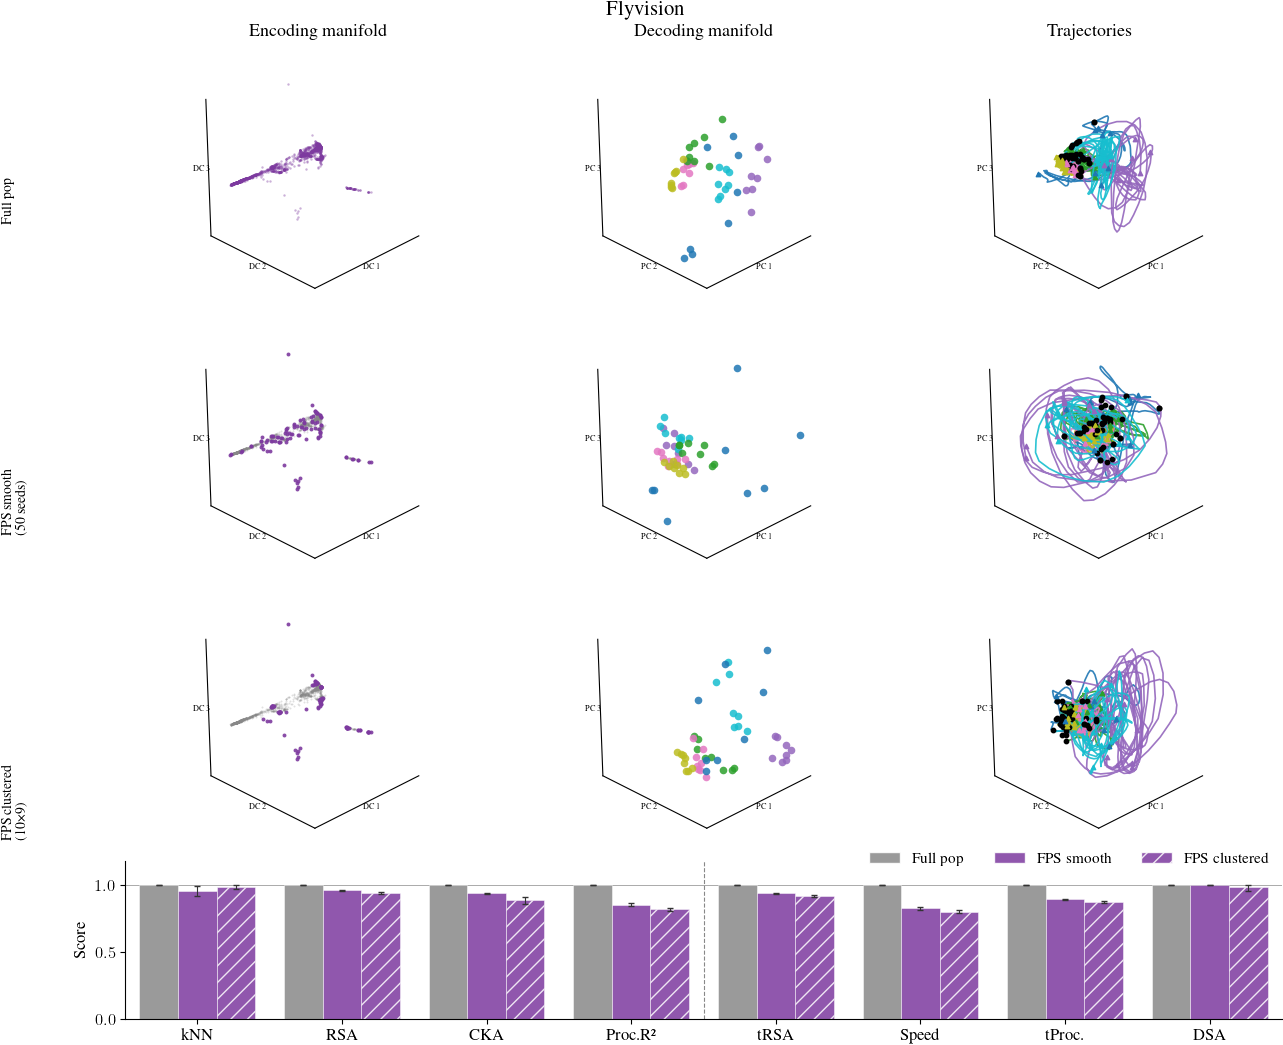

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_flyvis_T_Tm_i3_n1700_model000.pdf

=== r2plus1d_layer4_i3_n1960_seed17 ===
../data/decompositions/r2plus1d_layer4_i3_n1960_seed17-relNorm_sig3_n1960_SF-deepnet-shift*_F*.mat
F15: (5)
  r2plus1d_layer4_i3_n1960_seed17: N_nonout=1953  NSTIMS=6  NDIRS=8  T=5
  N=1953  NSTIMS=6  NDIRS=8  DSA ref z=18.689
  smooth: 100 neurons (5.1%)
  clustered: 100 neurons (5.1%)


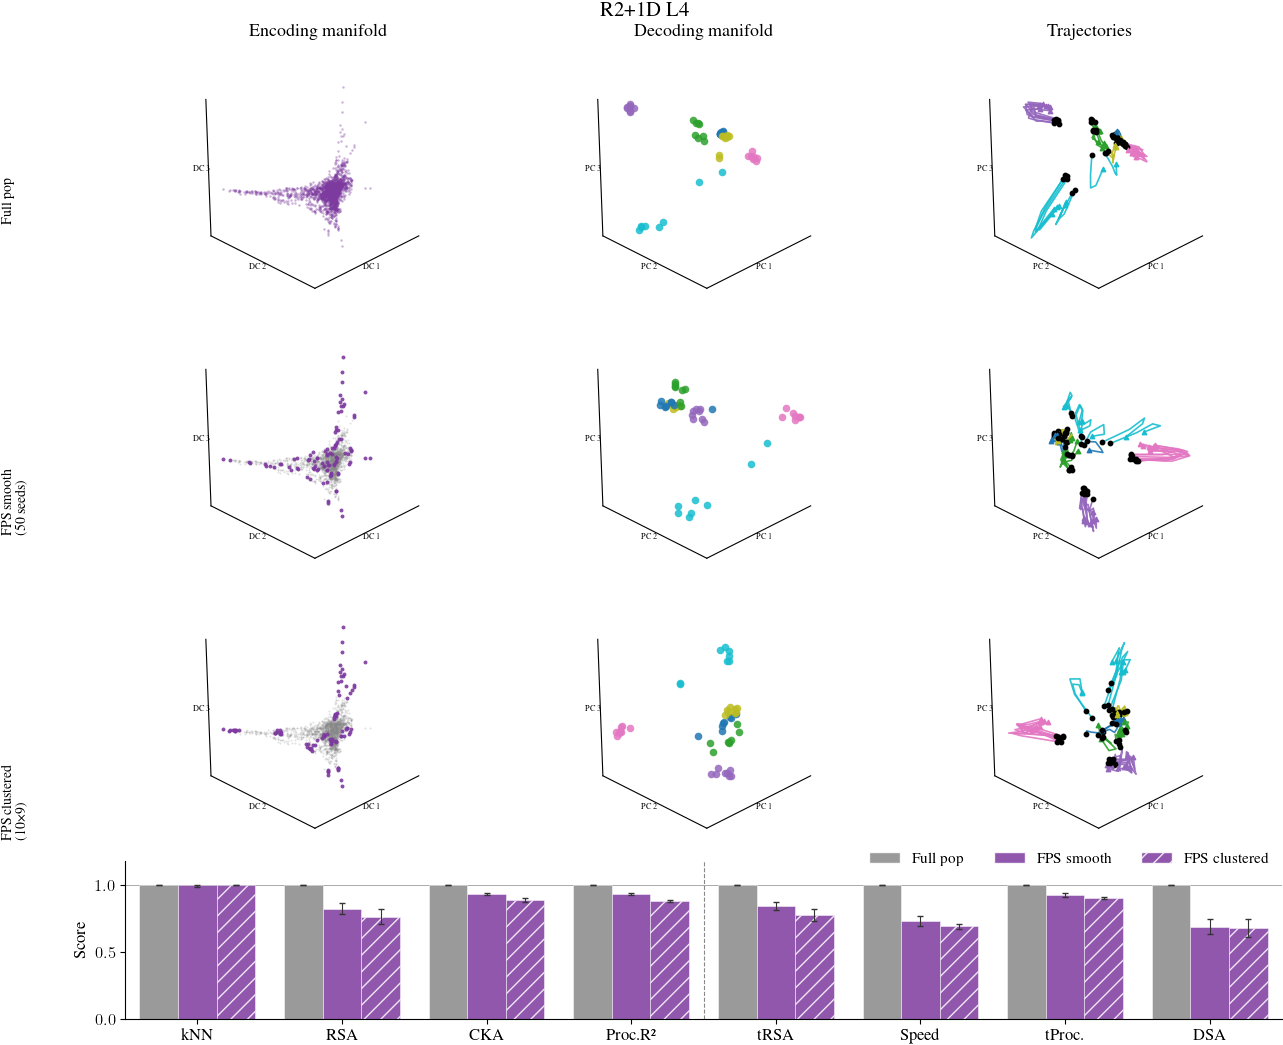

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_r2plus1d_layer4_i3_n1960_seed17.pdf

=== vit_b_16_L11_n2000_frames ===
../data/decompositions/vit_b_16_L11_n2000_frames-relNorm_sig3_n2000_SF-deepnet-shift*_F*.mat
F10: (5)
  vit_b_16_L11_n2000_frames: N_nonout=1992  NSTIMS=6  NDIRS=8  T=37
  N=1992  NSTIMS=6  NDIRS=8  DSA ref z=6.378
  smooth: 100 neurons (5.0%)
  clustered: 100 neurons (5.0%)


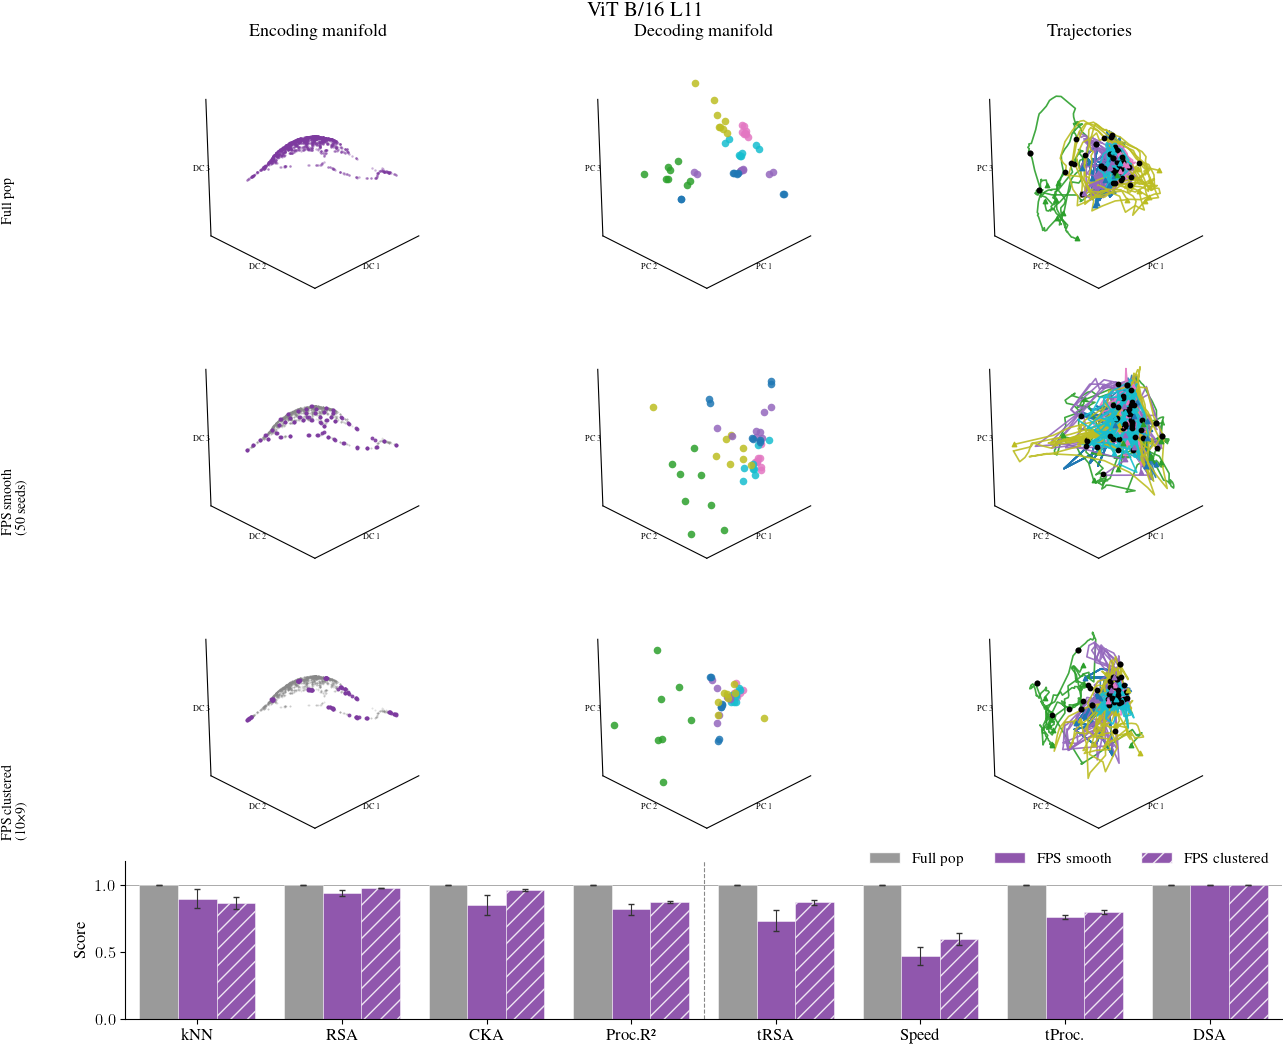

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_vit_b_16_L11_n2000_frames.pdf

=== raptor3_n2000 ===
../data/decompositions/raptor3_n2000-relNorm_sig3_n2000-deepnet-shift*_F*.mat
F25: (10)
  raptor3_n2000: N_nonout=1983  NSTIMS=10  NDIRS=10  T=12
  N=1983  NSTIMS=10  NDIRS=10  DSA ref z=146.396
  smooth: 100 neurons (5.0%)
  clustered: 100 neurons (5.0%)


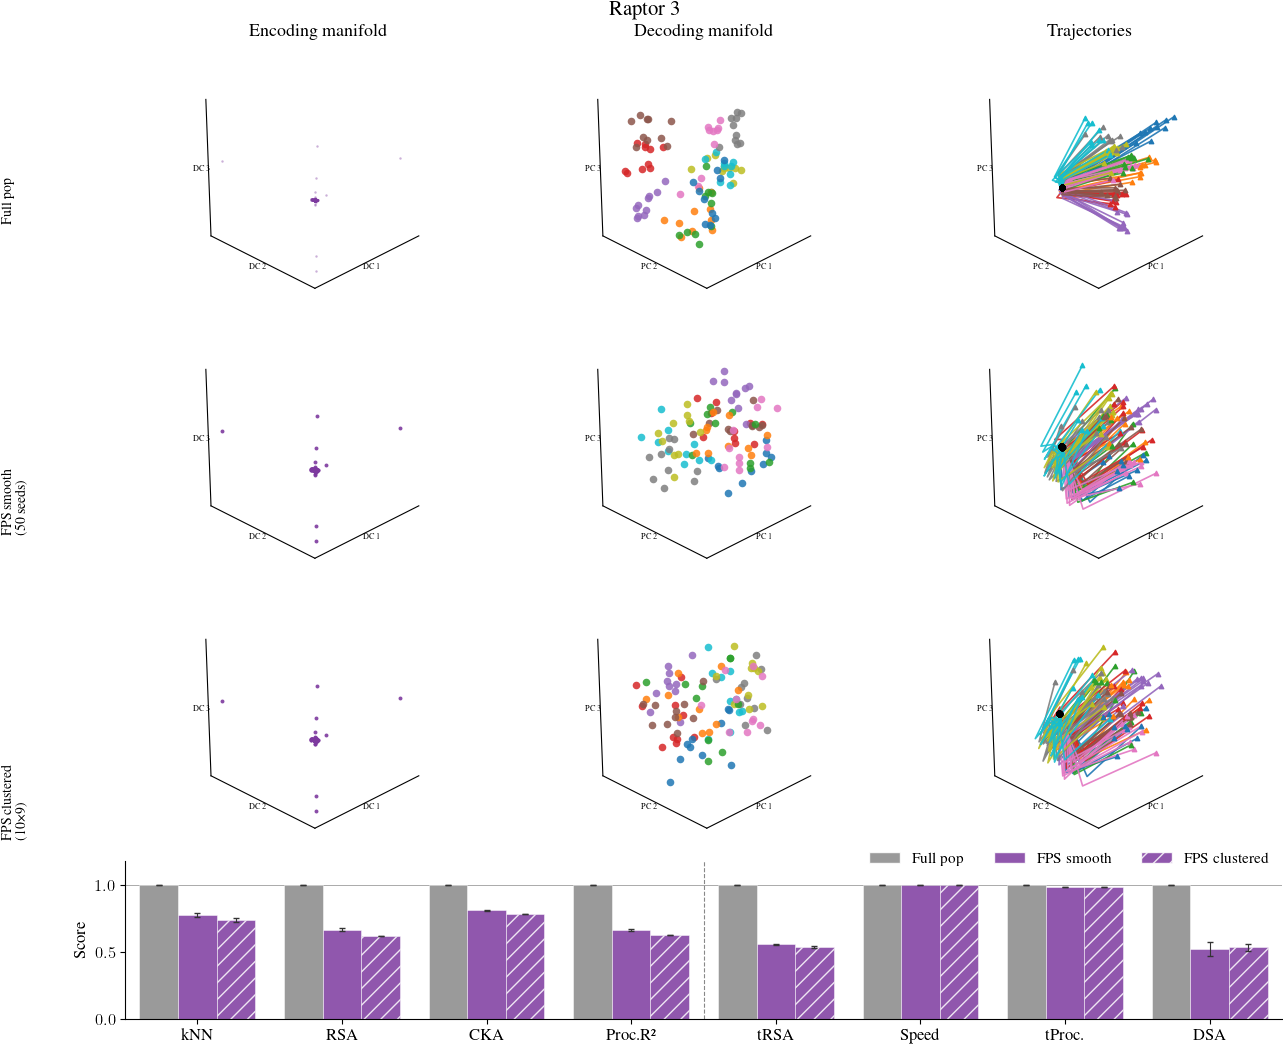

  Saved -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_raptor3_n2000.pdf

=== All showcase figures saved ===
LaTeX table -> /Users/johannesbertram/repos/FNN_Manifolds/fig/paper/showcase_metrics.tex


In [ ]:
# ── Showcase figure: encoding + decoding manifold + trajectories + 8 metrics ──
# One figure per dataset (16 total), FPS smooth vs FPS clustered subpopulations.
# Subpopulation selection: Farthest-Point Sampling (same as Figure 3).
# Layout per dataset: 4 rows × 3 cols (full pop / smooth / clustered / metrics bar).
import matplotlib.gridspec as gridspec

# ── Dataset list (16, matching notebook 20 sweep) ────────────────────────────
_SC_PREFIXES = [
    'vit_b_16_L11_n2000_frames',
    'raptor3_n2000',
    'allen_VISp', 'allen_VISrl', 'allen_VISam', 'allen_VISpm', 'allen_VISl',
    'VISp_natural_movie_one_scenes_all156',
    'VISam_natural_movie_one_scenes_all156',
    'VISrl_natural_movie_one_scenes_all156',
    'VISpm_natural_movie_one_scenes_all156',
    'VISl_natural_movie_one_scenes_all156',
    'V1', 'Retina',
    'fnn07_seed2',
    'fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1',
    'flyvis_T_Tm_i3_n1700_model000',
    'r2plus1d_layer4_i3_n1960_seed17',
    'vit_b_16_L11_n2000_frames',
    'raptor3_n2000'
]

# Reuse already-loaded data for the 4 nb22 datasets; load others on demand.
_SC_PRELOADED = {
    'Retina':     (tensor4d_Retina, data_Retina, NSTIMS_R,   NDIRS_R),
    'V1':         (tensor4d_V1,     data_V1,     NSTIMS_V,   NDIRS_V),
    'allen_VISp': (tensor4d_aVISp,  data_aVISp,  NSTIMS_aVP, NDIRS_aVP),
    'VISp_natural_movie_one_scenes_all156':
                  (tensor4d_VISp,   data_VISp,   NSTIMS_VP,  NDIRS_VP),
}

_SC_DS_LABELS = {
    'allen_VISp':  'V1 Gratings',    'allen_VISrl': 'VISrl Gratings',
    'allen_VISam': 'VISam Gratings', 'allen_VISpm': 'VISpm Gratings',
    'allen_VISl':  'VISl Gratings',
    'VISp_natural_movie_one_scenes_all156':  'V1 Nat.Movie',
    'VISam_natural_movie_one_scenes_all156': 'VISam Nat.Movie',
    'VISrl_natural_movie_one_scenes_all156': 'VISrl Nat.Movie',
    'VISpm_natural_movie_one_scenes_all156': 'VISpm Nat.Movie',
    'VISl_natural_movie_one_scenes_all156':  'VISl Nat.Movie',
    'V1': 'V1 Flow', 'Retina': 'Retina',
    'fnn07_seed2': 'FNN s2',
    'fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1': 'FNN act s1',
    'flyvis_T_Tm_i3_n1700_model000': 'Flyvision',
    'r2plus1d_layer4_i3_n1960_seed17': 'R2+1D L4',
    'vit_b_16_L11_n2000_frames': 'ViT B/16 L11',
    'raptor3_n2000': 'Raptor 3'
}

def _sc_color(pfx):
    if 'Retina' in pfx:         return '#b02628'
    if pfx == 'V1':             return '#1679d8'
    if pfx.startswith('allen'): return '#93c04f'
    if 'natural_movie' in pfx:  return '#37b2af'
    if 'fnn' in pfx:            return '#e07825'
    if 'flyvis' in pfx:         return '#7d3a9f'
    return '#7d3a9f'

_SC_STIM_CMAP = plt.cm.tab10

# ── 3D plot helpers ───────────────────────────────────────────────────────────
def _ax3d_setup(ax3d, xl='DC 1', yl='DC 2', zl='DC 3'):
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    for pane in (ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane):
        pane.fill = False; pane.set_edgecolor('none')
    ax3d.grid(False)
    try:
        ax3d.set_box_aspect([1, 1, 1], zoom=1.04)
    except TypeError:
        ax3d.set_box_aspect([1, 1, 1])
    ax3d.view_init(elev=25, azim=45)
    ax3d.set_xlabel(xl, fontsize=6, labelpad=-18)
    ax3d.set_ylabel(yl, fontsize=6, labelpad=-18)
    ax3d.set_zlabel(zl, fontsize=6, labelpad=-18)

def _sc_enc(ax3d, emb, idx_sub=None, ds_color='#888888'):
    """Plot encoding manifold; highlight subpopulation if idx_sub given."""
    e3 = emb[:, :3]; N = len(e3)
    if idx_sub is None:
        ax3d.scatter(*e3.T, c=ds_color, s=3, alpha=0.4,
                     depthshade=False, linewidths=0, rasterized=True)
    else:
        mask = np.zeros(N, dtype=bool); mask[idx_sub] = True
        ax3d.scatter(*e3[~mask].T, c=C_FULL, s=2, alpha=0.25,
                     depthshade=False, linewidths=0, rasterized=True)
        ax3d.scatter(*e3[mask].T,  c=ds_color, s=8, alpha=0.9,
                     depthshade=False, linewidths=0, rasterized=True, zorder=3)
    _ax3d_setup(ax3d)

def _sc_dec(ax3d, coords, stim_labels, n_show):
    """Plot decoding manifold colored by stimulus."""
    uniq = np.unique(stim_labels)[:n_show]
    for si in uniq:
        c   = _SC_STIM_CMAP(int(si) / max(len(uniq) - 1, 1))
        pts = coords[stim_labels == si]
        if len(pts) == 0: continue
        nc  = pts.shape[1]
        if nc < 3: pts = np.hstack([pts, np.zeros((len(pts), 3 - nc))])
        ax3d.scatter(*pts[:, :3].T, c=[c], s=30, alpha=0.85,
                     depthshade=False, linewidths=0, rasterized=True)
    _ax3d_setup(ax3d, xl='PC 1', yl='PC 2', zl='PC 3')

def _sc_traj(ax3d, trajs, NSTIMS, NDIRS, n_show):
    """Plot decoding trajectories; one line per (stimulus, direction) instance."""
    SD, T, nc = trajs.shape
    t3 = trajs[:, :, :3]
    if nc < 3:
        t3 = np.concatenate([t3, np.zeros((SD, T, 3 - nc))], axis=-1)
    show = min(n_show, NSTIMS)
    for sd_i in range(SD):
        si = sd_i // NDIRS
        if si >= show:
            continue
        c  = _SC_STIM_CMAP(si / max(show - 1, 1))
        tr = t3[sd_i]
        ax3d.plot(*tr.T, color=c, lw=1.2, alpha=0.9)
        ax3d.scatter(*tr[0],  c='black', s=10, zorder=5, depthshade=False)
        ax3d.scatter(*tr[-1], c=[c],     s=10, marker='^', zorder=5, depthshade=False)
    _ax3d_setup(ax3d, xl='PC 1', yl='PC 2', zl='PC 3')

# ── Collect rows for LaTeX table ─────────────────────────────────────────────
_sc_table_rows = []

# ── Raptor hard-coded override: R=25 graph, nonoutliers from file ────────────
_SC_EXPLORER_KWARGS = {
    'raptor3_n2000': {'n_far': 7, 'R_force': 25, 'diffmap_cols': [6, 7, 8]},
}

# ── Main loop ─────────────────────────────────────────────────────────────────
for _pfx in _SC_PREFIXES:
    print(f'\n=== {_pfx} ===')

    if _pfx in _SC_PRELOADED:
        t4d, data, NSTIMS, NDIRS = _SC_PRELOADED[_pfx]
    else:
        t4d, _, NSTIMS, NDIRS, data = load_dataset_for_sweep(_pfx, **_SC_EXPLORER_KWARGS.get(_pfx, {}))

    N           = t4d.shape[0]
    stim_labels = np.repeat(np.arange(NSTIMS), NDIRS)
    emb         = data['embedding_']
    ds_color    = _sc_color(_pfx)
    ds_label    = _SC_DS_LABELS.get(_pfx, _pfx[:20])
    n_show      = min(NSTIMS, 20)

    # ── Full-pop reference ────────────────────────────────────────────────
    coords_ref,     _ = compute_decoding_manifold(t4d, n_components=15)
    coords_ref_knn, _ = compute_decoding_manifold(t4d, n_components=None)
    dsa_z             = compute_dsa(t4d, t4d)
    dsa_ref_z         = dsa_z if (dsa_z and not np.isnan(dsa_z) and dsa_z > 1e-8) else None
    acc_full          = min(1.0, max(knn_decoding_accuracy(coords_ref_knn, stim_labels), 1e-8))
    coords_full,   _  = compute_decoding_manifold(t4d, n_components=None)
    trajs_full,    _  = compute_decoding_trajectories(t4d, n_components=15)
    full_scores       = {k: 1.0 for k in _METRIC_KEYS}
    print(f'  N={N}  NSTIMS={NSTIMS}  NDIRS={NDIRS}  DSA ref z={dsa_z:.3f}')

    # ── FPS subpopulations ────────────────────────────────────────────────
    _modes = [('smooth', FPS_SMOOTH), ('clustered', FPS_CLUSTERED)]
    _mdata = {}

    for mode_name, fp in _modes:
        _seed_scores = []
        for _s in FPS_SEEDS:
            _idx, _ = fps_select(emb, fp['n_seeds'], fp['m_neighbors'], rng_seed=_s)
            _sc     = compute_all_metrics(t4d, t4d[_idx], stim_labels,
                                          coords_ref=coords_ref, dsa_ref_z=dsa_ref_z)
            if not np.isnan(_sc.get('acc', np.nan)):
                _sc['acc'] = min(1.0, _sc['acc'] / acc_full)
            _seed_scores.append((_idx, _sc))

        mean_sc = {k: float(np.nanmean([x[1].get(k, np.nan) for x in _seed_scores]))
                   for k in _METRIC_KEYS}
        std_sc  = {k: float(np.nanstd( [x[1].get(k, np.nan) for x in _seed_scores]))
                   for k in _METRIC_KEYS}
        vis_idx = _seed_scores[0][0]
        _mdata[mode_name] = dict(mean=mean_sc, std=std_sc, idx=vis_idx)
        print(f'  {mode_name}: {len(vis_idx)} neurons ({100*len(vis_idx)/N:.1f}%)')

    # ── Build figure ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 11))
    gs  = gridspec.GridSpec(4, 3,
                            height_ratios=[1, 1, 1, 0.65],
                            hspace=0.12, wspace=0.05,
                            left=0.10, right=0.99, top=0.94, bottom=0.06)

    _COL_TITLES = ['Encoding manifold', 'Decoding manifold', 'Trajectories']
    _ROW_LABELS = ['Full pop', 'FPS smooth\n(50 seeds)', 'FPS clustered\n(10×9)']
    _cw = (gs.right - gs.left) / 3
    _rh = (gs.top - 0.12) / 3

    for ci, ct in enumerate(_COL_TITLES):
        fig.text(gs.left + (ci + 0.5) * _cw, gs.top + 0.01, ct,
                 ha='center', va='bottom', fontsize=FS_TITLE - 1,
                 fontweight='bold', transform=fig.transFigure)

    for ri, rl in enumerate(_ROW_LABELS):
        fig.text(0.005, gs.top - (ri + 0.5) * _rh, rl,
                 ha='left', va='center', fontsize=FS_LABEL - 2,
                 fontweight='bold', rotation=90, transform=fig.transFigure)

    # Row 0: Full population
    _sc_enc(fig.add_subplot(gs[0, 0], projection='3d'), emb, ds_color=ds_color)
    _sc_dec(fig.add_subplot(gs[0, 1], projection='3d'), coords_full, stim_labels, n_show)
    _sc_traj(fig.add_subplot(gs[0, 2], projection='3d'), trajs_full, NSTIMS, NDIRS, n_show)

    # Rows 1 & 2: FPS smooth / clustered
    for ri, mode_name in enumerate(['smooth', 'clustered']):
        vis_idx       = _mdata[mode_name]['idx']
        t_sub         = t4d[vis_idx]
        coords_sub, _ = compute_decoding_manifold(t_sub, n_components=None)
        trajs_sub, _  = compute_decoding_trajectories(t_sub, n_components=15)
        _sc_enc(fig.add_subplot(gs[ri + 1, 0], projection='3d'), emb,
                idx_sub=vis_idx, ds_color=ds_color)
        _sc_dec(fig.add_subplot(gs[ri + 1, 1], projection='3d'), coords_sub,
                stim_labels, n_show)
        _sc_traj(fig.add_subplot(gs[ri + 1, 2], projection='3d'), trajs_sub,
                 NSTIMS, NDIRS, n_show)

    # Row 3: Grouped metric bar
    ax_bar = fig.add_subplot(gs[3, :])
    plot_metric_bars_grouped(
        ax_bar,
        [full_scores, _mdata['smooth']['mean'], _mdata['clustered']['mean']],
        labels=['Full pop', 'FPS smooth', 'FPS clustered'],
        colors=[C_FULL, ds_color, ds_color],
        linestyles=['-', '-', '--'],
        all_errors=[{k: 0.0 for k in _METRIC_KEYS},
                    _mdata['smooth']['std'],
                    _mdata['clustered']['std']],
        yticks=[0, 0.5, 1.0],
    )

    fig.suptitle(ds_label, fontsize=FS_TITLE + 1, fontweight='bold', y=0.985)
    _sp = os.path.join(BASEDIR_FIG, f'showcase_{_pfx}.pdf')
    fig.savefig(_sp, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> {_sp}')

    for _cn, _sc, _er in [
        ('Full pop',      full_scores,              {k: 0.0 for k in _METRIC_KEYS}),
        ('FPS smooth',    _mdata['smooth']['mean'],    _mdata['smooth']['std']),
        ('FPS clustered', _mdata['clustered']['mean'], _mdata['clustered']['std']),
    ]:
        _sc_table_rows.append((ds_label, _cn, _sc, _er))

print('\n=== All showcase figures saved ===')

# ── LaTeX table ───────────────────────────────────────────────────────────────
_CN_SHORT = {'FPS smooth': 'Smooth', 'FPS clustered': 'Clustered'}

def _fmt_cell(v, e):
    if np.isnan(v): return '--'
    if e > 1e-6:    return rf'{v:.2f}{{\scriptsize$\pm${e:.2f}}}'
    return f'{v:.2f}'

_tex_lines = [
    r'\begin{table}[htbp]',
    r'\centering', r'\small',
    r'\caption{Subpopulation metric scores across 16 datasets. '
    r'Smooth: FPS 50 seeds $\times$ 1\,NN; Clustered: 10 seeds $\times$ 9\,NN. '
    r'Values show mean $\pm$ std over 5 seeds.}',
    r'\label{tab:showcase}',
    r'\begin{tabular}{llrrrrrrrr}',
    r'\toprule',
    r'Dataset & Cond. & kNN & RSA & CKA & Proc.$R^2$ & tRSA & Spd. & tProc & DSA \\',
    r'\midrule',
]
_prev_ds = None
for _dsl, _cn, _sc, _er in _sc_table_rows:
    if _cn == 'Full pop':
        continue
    if _prev_ds is not None and _dsl != _prev_ds:
        _tex_lines.append(r'\midrule')
    _ds_col = _dsl if _dsl != _prev_ds else ''
    _prev_ds = _dsl
    _vals = ' & '.join(_fmt_cell(_sc.get(k, float('nan')), _er.get(k, 0.0))
                       for k in _METRIC_KEYS)
    _tex_lines.append(f'{_ds_col} & {_CN_SHORT.get(_cn, _cn)} & {_vals} \\\\')
_tex_lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

_tex_path = os.path.join(BASEDIR_FIG, 'showcase_metrics.tex')
with open(_tex_path, 'w') as _f:
    _f.write('\n'.join(_tex_lines) + '\n')
print(f'LaTeX table -> {_tex_path}')
